# Download and prepare `RH` (2004-2025)

**notebook version**: `4` (29 Jul 2026)


## ℹ️ About this notebook

Downloads screened relative humidity `RH` from the InfluxDB database, merges the data sources into
one continuous series, corrects the August 2012 logger timestamp shift, removes the three damaged
2012 periods, applies the `RH > 100%` offset correction, establishes **which instrument the
exported column is and what the January 2016 probe replacement did to it**, then fills every gap in
two reconstruction passes — first from the co-located NABEL sensor, then from MeteoSwiss Lägern for
the gaps NABEL cannot reach — and stores the result to the external data folder.

This notebook follows notebooks `01` (`SW_IN`), `02` (`TA`) and `03` (`PPFD_IN`) up to and
including the corrections.

::: {.callout-important title="The exported series is not homogeneous across 21 January 2016"}
`RH_T1_47_1` is delivered by **the same probe as `TA_T1_47_1`**, and that probe was replaced on
**21 January 2016** together with the logger that read it: a Rotronic MP101A read as an analog
voltage gave way to a Campbell CS215 read over SDI-12. Notebook `02` established that the change
moved `TA_T1_47_1` by about 1.3 °C. Whether it moved `RH` had never been asked.

It did. The section *Which sensor this is, and what the hardware change did to it* measures a step
of **+2.1 to +3.3 percentage points of RH** against two independent references, rising to
**+3.9 to +4.1** on the half-hours where nothing is near the 100 % ceiling, and attributes it to
the tower probe rather than to either reference.

Two consequences run through the rest of the notebook. The exported frame carries a
**`FLAG_RH_T1_47_1_SOURCE`** column naming the probe generation behind every record, and the
reconstruction offsets are **fitted separately within each era**, so that no gap is filled with a
relationship fitted on the other side of the break.

No `_HOMOGENIZED` column is exported. The step is not one number: it is 3 to 6 percentage points
over the drier half of the range and close to nothing above 95 % RH, where both probes are pinned
against the ceiling, so no constant describes it. The evidence is in the section; the decision is
stated at the end of it.
:::

::: {.callout-important title="What this notebook does and does not do"}
It **reconstructs** missing `RH_T1_47_1`, it does not model it: each gap is filled from another
measurement of the same quantity, offset-corrected month by month within its own sensor era. There
is no XGBoost model, no meteorological drivers, no feature engineering.

Two sources, in order of preference. **NABEL at 49 m** (same tower, 2004-2018) is the closer,
stronger reference and fills first (flag `3`). **MeteoSwiss Lägern at 2.5 km** (2004-2025) fills
the rest — chiefly the post-2018 gaps NABEL cannot reach (flag `4`). Lägern is 2.5 km away and
400 m lower, so a flag `4` value carries larger uncertainty than a flag `3` one: a weaker
reconstruction, still not a measurement.

The exported series is **complete** — every record carries a value.
:::

**Output columns:**

- `RH_T1_47_1` — the corrected, gap-free series (%)
- `FLAG_RH_T1_47_1_MISSING` — where each record comes from; `0` = measured at 47 m, `3` =
  reconstructed from NABEL (49 m), `4` = reconstructed from MeteoSwiss Lägern (2.5 km). Codes `1`
  (never measured) and `2` (removed as faulty) remain in the legend but do not occur
  (see `FLAG_LEGEND` below)
- `FLAG_RH_T1_47_1_SOURCE` — which probe generation stands behind the timestamp; `0` = Campbell
  CS215, `1` = Rotronic MP101A, `2` = the changeover outage, era undetermined, `3` = before the
  tower record begins. **New in this version**

The provenance flag deliberately does **not** reuse the `ISFILLED` vocabulary of `01`-`03`, whose
codes describe *which model* produced a value. Nothing here is modelled. A consumer wanting only
genuine 47 m measurements filters `FLAG_RH_T1_47_1_MISSING == 0`; one wanting every usable value
takes all records; one comparing across 2016 has to read `FLAG_RH_T1_47_1_SOURCE` first.

Downloading uses diive's in-house InfluxDB engine `InfluxIO`. It needs `influxdb-client`, which
a plain `uv sync` installs here via the `diive[db]` extra.


***

## 📇 Data sources

**Series**

- `RH_T1_47_1` — ETH, 47 m. **This is the product series.** mst (2004-2021), diive (2022-2025)
- `RH_NABEL_T1_49_1` — NABEL, 49 m, same tower, 2004-2018. Independent reference for the 2012
  diagnostics and for the sensor-identity section, and the **first** reconstruction source. Not
  exported. It stops being an independent measurement in August 2018, which the sensor-identity
  section derives from the data and acts on.
- `RH_LAE_MS` — MeteoSwiss Lägern, 2.5 km, 845 m, 2004-2025. The **second** reconstruction source,
  for the post-2018 gaps NABEL cannot reach, and the third series of the sensor-identity section.
  Read from the product written by `10_REFERENCE/MeteoSwiss_LAE_2004-2025.ipynb`. Not exported.

NABEL sits on a separate acquisition system, which is what lets it detect a logger fault on the
ETH side. Both references reconstruct `RH_T1_47_1` where that sensor has no value; neither is
itself exported.

**Files beside the workflow folder**

- the GIN fieldbook export — the site's maintenance record, read in the sensor-identity section
- the CR10X (2004-2006) and CR1000 (2016) logger programs — which probe each era was, and how its
  raw signal was converted

**Legend**

- NABEL ... Data from [NABEL](https://www.bafu.admin.ch/bafu/en/home/topics/air/luftbelastung/national-air-pollution-monitoring-network--nabel-.html), meteoscreening with [diive](https://github.com/holukas/diive)
- mst ... Data from ETH, meteoscreening with the now deprecated MeteoscreeningTool
- diive ... Data from ETH, meteoscreening with diive


## ⏱️ Timestamp convention

The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`**. On download, `InfluxIO`
shifts the UTC timestamp by `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the returned data are in **local
time** (UTC + offset) and still `TIMESTAMP_END`. `TimestampSanitizer(output_middle_timestamp=True)`
then converts to `TIMESTAMP_MID`, which is what the rest of this notebook works with.

`START` and `STOP` are interpreted in the same timezone as `TIMEZONE_OFFSET_TO_UTC_HOURS`.

***

## ⚙️ Settings


### Data settings


In [1]:
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'  # Folder with configuration files
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # Timezone, e.g. "1" is translated to timezone "UTC+01:00" (CET, winter time)
REQUIRED_TIME_RESOLUTION = '30min'  # Expected resolution; TimestampSanitizer raises if the data disagree
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

TARGET = 'RH_T1_47_1'           # exported variable
REFERENCE = 'RH_NABEL_T1_49_1'  # independent sensor: 2012 diagnostics + reconstruction source

# Reconstruction of TARGET from REFERENCE. The additive per-month offset between the two sensors
# is fitted on the overlap within +/- OFFSET_WINDOW_YEARS calendar years of the record being
# reconstructed, because that offset drifts substantially over the record (see the
# reconstruction section). A month with fewer than OFFSET_MIN_SAMPLES local samples falls back
# to the offset pooled over the whole overlap.
OFFSET_WINDOW_YEARS = 2
OFFSET_MIN_SAMPLES = 500

# Output: data files live in the external (untracked) data folder, with the same
# numeric prefix as this notebook.
OUTNAME = "04_METEO_RH_CORRECTED_2004-2025"
OUTPATH = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"

# Second reconstruction source: MeteoSwiss Lägern, 2.5 km from the tower, for the post-2018
# gaps the NABEL sensor cannot reach. Produced by 10_REFERENCE/MeteoSwiss_LAE_2004-2025.ipynb
# and addressed by path, so a move breaks this read.
REFPATH = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
           r"\workflow\10_METEO\10_REFERENCE\MeteoSwiss_LAE_30MIN_2004-2025.parquet")
REFCOL = "RH_LAE_MS"

# --- Inputs for the sensor-identity section ----------------------------------------------------
# The site maintenance record, exported from GIN. It lives BESIDE the workflow folder, not inside
# it, because it is an input to many stages rather than the output of one.
FIELDBOOK = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
             r"\fieldbook_gin\CH-LAE-laegeren-export_20260719.csv")

# Every surviving logger program that measures relative humidity at 47 m, read rather than quoted,
# so the sensor identity and the conversion are re-derived on every run. The six CR10X programs
# span 2004-2006 and all carry the Rotronic MP101A; the CR1000 program is the one installed at the
# January 2016 changeover and carries the Campbell CS215. No tower program between May 2006 and
# January 2016 survives on disk, so these establish two endpoints and the data have to cover the
# interval between them.
_CSI = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
        r"\csi_loggerscripts")
PROGRAMS_CR10X = [_CSI + r"\LAEGEREN.20040526.CSI",
                  _CSI + r"\LAEGEREN.20040810.CSI",
                  _CSI + r"\LAEGEREN.20041228.CSI",
                  _CSI + r"\LAEGEREN.20050818.CSI",
                  _CSI + r"\LAEGEREN.20050914.CSI",
                  _CSI + r"\LAEGEREN.20060524.csi"]
PROGRAM_CR1000 = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
                  r"\logger_scripts\ch-lae_idl_t1_47_1-Version_20160118\CH-LAE_iDL_T1_47_1.CR1")


### Imports


In [2]:
from datetime import datetime
from pathlib import Path
import importlib.metadata
import html
import re
import textwrap

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme('notebook')

import diive as dv
from diive.core.io.db.influx import InfluxIO  # diive's in-house InfluxDB engine (via the diive[db] extra)
from diive.core.times.times import TimestampSanitizer

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

# Start time is kept so the last cell can report the total runtime of the notebook.
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")

Last run: 2026-07-29 20:56:44
diive version: v0.91.0


In [3]:
# Provenance flag used in this notebook. This is NOT the ISFILLED flag of notebooks 01-03, whose
# codes name the model that produced a value; nothing here is modelled.
#
# Codes 0, 3 and 4 carry a value, codes 1 and 2 are gaps:
#   filter flag == 0           for genuine 47 m measurements only
#   filter flag in (0, 3, 4)   for every usable value
#
# 1 and 2 stay separated so a downstream fill can tell an instrument that never delivered a value
# from a value this notebook judged faulty and threw away. In this record both references together
# cover every gap, so 1 and 2 no longer occur, but they are kept in the vocabulary.
FLAG_LEGEND = {
    0: '0 = measured at 47 m (corrected)',
    1: '1 = missing, never measured',
    2: '2 = missing, removed here as faulty (2012 damaged periods)',
    3: '3 = reconstructed from NABEL at 49 m',
    4: '4 = reconstructed from MeteoSwiss Lägern at 2.5 km',
}
PRESENT_FLAGS = (0, 3, 4)  # codes that carry a value


### Captions


In [4]:
# Captions. Every table and every figure in this notebook carries one, so that a reader meeting a
# number in the rendered page can tell what it is without reading the code that produced it.
# Defined here, above the first cell that calls either. Copied as-is from notebook 03, whose
# figcap() carries the PlaceHolderLayoutEngine fix.
def tabcap(text, width=100):
    """Print a table caption, above the table it belongs to."""
    print(textwrap.fill(f"Table - {text}", width) + "\n")


def figcap(fig, text, width=125):
    """Place a caption under a figure. Call after the last axes of that figure is drawn."""
    width = min(width, max(40, int(14.5 * fig.get_size_inches()[0])))
    caption = textwrap.fill(f"Figure - {text}", width)
    # An engine that still lays the figure out at draw time can make room for a caption itself.
    # plt.tight_layout() does NOT leave one: it executes once and leaves a PlaceHolderLayoutEngine
    # that never runs again, so a caption handed to supxlabel there lands on top of the tick
    # labels. Those figures take the manual branch below.
    _engine = fig.get_layout_engine()
    if _engine is not None and type(_engine).__name__ != 'PlaceHolderLayoutEngine':
        fig.supxlabel(caption, fontsize=9, ha='left', x=0.005)
        return
    lines = len(caption.splitlines())
    extra = 0.17 * lines + 0.12          # inches; one caption line is about 0.17 in at fontsize 9
    width_in, height_in = fig.get_size_inches()
    fig.set_size_inches(width_in, height_in + extra)
    keep = height_in / (height_in + extra)
    offset = extra / (height_in + extra)
    for ax in fig.axes:
        pos = ax.get_position()
        ax.set_position([pos.x0, offset + pos.y0 * keep, pos.width, pos.height * keep])
    fig.text(0.005, 0.01, caption, fontsize=9, ha='left', va='bottom')


### Helper functions


The helpers below are the ones the whole notebook shares: the `RH > 100%` correction, the
offset transfer both reconstruction passes use, and the two plotting helpers. The plot helpers of
notebooks `01` and `03` split a series by a gap-filling flag; there is no such flag here, so the
equivalents below split by *provenance* instead. Each builds its own caption from the data it was
handed, so a second call site cannot arrive without one.


In [5]:
def remove_rh_offset_by_year(series: pd.Series, showplot: bool = False):
    """Apply diive's `RH > 100%` offset correction within each year that contains a value > 100%.

    `dv.corrections.remove_relativehumidity_offset` derives a daily offset from the records that
    exceed 100%, then **interpolates and ffill/bfills that offset over the whole index**. Called
    once on the full record that also shifts years which never exceed 100%: measured here, a flat
    +0.71 % over 2004-2006 (bfilled from 2007) and a flat +0.133 % over 2016-2025 (ffilled from
    2015), neither of which has any exceedance to justify it.

    Subtracting the offset from records below 100% is the point of the correction — a sensor
    reading 102 when the true value is 100 is biased across its whole range, not only at
    saturation. Extrapolating that bias into a decade with no evidence of drift is not. Running
    the correction per exceedance year keeps the first and drops the second, and leaves every
    other year bit-identical to the input.

    Note the library function renames the series it is given in place, so it gets a copy.

    Returns (corrected series, list of years the correction ran in).
    """
    out = series.copy()
    years = sorted({int(y) for y in series.index.year[series > 100]})
    for year in years:
        locs = series.index.year == year
        out.loc[locs] = dv.corrections.remove_relativehumidity_offset(
            series.loc[locs].copy(), showplot=showplot)
    return out, years


def monthly_offset_table(target: pd.Series, reference: pd.Series, era: pd.Series,
                         window_years: int = None, min_samples: int = None) -> pd.Series:
    """Additive offset `target - reference` per (era, year, month), fitted on a local year window.

    The two sensors do not differ by a constant, and they differ in three ways at once.

    **Seasonally.** The offset is about +3.9 % RH in February against +0.4 % RH in August.

    **Over time.** It drifts across the record (annual mean +0.08 % RH in 2006 against +5.06 % RH
    in 2017), so a single offset pooled over the whole overlap is dominated by the late years and
    is too large for the early ones: it would apply +3.42 % RH to January 2004 where the local
    evidence says +1.35 % RH.

    **And at the sensor change.** The sensor-identity section establishes that `RH_T1_47_1` steps
    by 2 to 4 percentage points at the January 2016 probe replacement. Fitting one offset
    relationship across that break would put the reconstructed records on neither era's level —
    the failure notebook `02` documents for gap-filling models trained across the same date.
    `era` is therefore a per-record label of the sensor generation, and each era is fitted only on
    its own overlap.

    Within an era, each month of each year is fitted on the overlap within +/- `window_years`
    calendar years. A month with fewer than `min_samples` local records falls back to that era's
    pooled monthly offset, and a month absent from that era's overlap entirely to its pooled mean.
    An era with no overlap at all **raises**, rather than handing back a table of NaNs that
    `reconstruct_from_reference` would then fail on somewhere less informative.

    Returns a Series indexed by (era, year, month).
    """
    window_years = OFFSET_WINDOW_YEARS if window_years is None else window_years
    min_samples = OFFSET_MIN_SAMPLES if min_samples is None else min_samples

    years = range(int(target.index.year.min()), int(target.index.year.max()) + 1)
    rows = {}
    for era_code in sorted(pd.unique(era)):
        _in_era = (era == era_code).reindex(target.index).fillna(False)
        overlap = pd.concat([target.where(_in_era).rename('t'), reference.rename('r')],
                            axis=1).dropna()
        if overlap.empty:
            raise ValueError(
                f"sensor era {era_code!r} has no overlap between the two series, so no offset can "
                f"be fitted for it. Reconstructing its records from another era's offset is "
                f"exactly what this split exists to prevent.")
        diff = overlap.t - overlap.r
        pooled_monthly = diff.groupby(diff.index.month).mean()
        pooled_mean = float(diff.mean())
        for year in years:
            near = diff[(diff.index.year >= year - window_years) &
                        (diff.index.year <= year + window_years)]
            grouped = near.groupby(near.index.month)
            local_mean, local_n = grouped.mean(), grouped.size()
            for month in range(1, 13):
                if month in local_mean.index and local_n.get(month, 0) >= min_samples:
                    rows[(era_code, year, month)] = float(local_mean[month])
                elif month in pooled_monthly.index:
                    rows[(era_code, year, month)] = float(pooled_monthly[month])
                else:
                    rows[(era_code, year, month)] = pooled_mean
    return pd.Series(rows).rename('offset')


def reconstruct_from_reference(target: pd.Series, reference: pd.Series, offsets: pd.Series,
                               era: pd.Series):
    """Fill gaps in `target` with offset-corrected `reference` values, clipped to [0, 100].

    Each record takes the offset fitted for **its own** sensor era, so a record on one side of the
    January 2016 probe replacement is never reconstructed with a relationship fitted on the other.

    Only records where `target` is missing AND `reference` has a value are touched; everything
    else comes back untouched. Returns (reconstructed series, boolean mask of what was filled).
    """
    filled = target.isna() & reference.notna()
    keys = pd.MultiIndex.from_arrays([era[filled].values,
                                      target.index[filled].year, target.index[filled].month])
    applied = offsets.reindex(keys).values
    if np.isnan(applied).any():
        raise ValueError("no offset available for some records to reconstruct")

    out = target.copy()
    out.loc[filled] = np.clip(reference.loc[filled].values + applied, 0, 100)
    return out, filled


def plot_presence_panels(series, flag, title, ylabel='RH (%)', figsize=(16, 8)):
    """Four stacked panels: the exported series, then each provenance class on its own.

    The lower panels are the ones to look at. Each class is drawn against a blank background, so
    a block of reconstructed records sitting at the wrong level, or a gap class turning up where
    it should not, is visible instead of hidden under the measured series.

    The caption is built from the data the helper was handed, so a second call site cannot arrive
    without one.
    """
    _plotdf = pd.DataFrame({
        'RH (all values)': series,
        'measured at 47 m': series.where(flag == 0),
        'reconstructed from NABEL (49 m)': series.where(flag == 3),
        'reconstructed from Lägern (2.5 km)': series.where(flag == 4),
        'missing (never measured / removed)': flag.where(flag.isin([1, 2])),
    })
    axs = _plotdf.plot(subplots=True, figsize=figsize, x_compat=True, alpha=.9,
                       title=title, legend=True)
    for ax in axs[:4]:
        ax.set_ylabel(ylabel)
    axs[4].set_ylabel('flag')
    plt.tight_layout()
    figcap(axs[0].get_figure(),
           f"{title}. Top: every exported value. Below it, each provenance class drawn on its own "
           f"against a blank background, which is where a block of reconstructed records sitting "
           f"at the wrong level would be visible and nowhere else: {int((flag == 0).sum()):,} "
           f"measured at 47 m, {int((flag == 3).sum()):,} reconstructed from NABEL at 49 m, "
           f"{int((flag == 4).sum()):,} reconstructed from MeteoSwiss Lägern. The bottom panel is "
           f"empty, which is the statement that no record is left without a value.")
    return axs


def coverage_stats_by_year(series, flag, legend=None):
    """Records per year by provenance class, with a bar chart of the reconstructed ones."""
    legend = legend or FLAG_LEGEND
    tab = (pd.crosstab(flag.index.year, flag)
             .rename(columns=lambda f: legend.get(f, f))
             .rename_axis(index='year', columns=None))
    tab.insert(0, 'records', series.groupby(series.index.year).size())
    nonmeasured = tab.drop(columns=['records'] + [c for c in tab.columns
                                                  if str(c).startswith('0 =')], errors='ignore')
    if not nonmeasured.empty and nonmeasured.to_numpy().sum() > 0:
        ax = nonmeasured.plot(kind='bar', stacked=True, figsize=(14, 4),
                              title='Non-measured records per year, by provenance')
        ax.set_ylabel('records')
        ax.legend(fontsize=8)
        plt.tight_layout()
        _tot = nonmeasured.sum(axis=1)
        figcap(ax.get_figure(),
               f"reconstructed records per year and source, measured records omitted so the "
               f"reconstructions are readable. The most heavily reconstructed year is "
               f"{int(_tot.idxmax())} with {int(_tot.max()):,} records, almost all of it the "
               f"period before the sensor was connected; {int((_tot < 100).sum())} of the "
               f"{len(_tot)} years carry fewer than a hundred reconstructed records each.")
    tabcap("records per year and provenance code. Every record carries a code and a value, so the "
           "rows sum to the number of half-hours in each year")
    return tab


### 🔌 Connect to database


In [6]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

***

## ⬇️ `NABEL` and ETH data from `diive` meteoscreening


### Download


In [7]:
%%time

BUCKET = f'ch-lae_processed'
FIELDS = ['RH_NABEL_T1_49_1', 'RH_T1_47_1']
MEASUREMENTS = ['RH']
START = '2004-01-01 00:00:01'
STOP = '2026-01-01 00:00:01'
DATA_VERSION = 'meteoscreening_diive'

nabel_eth_diive_rh, _, _ = dbc.download(
    bucket=BUCKET,
    measurements=MEASUREMENTS,
    fields=FIELDS,
    start=START,  # Download data starting with this date (the start date itself IS included),
    stop=STOP,  # Download data before this date (the stop date itself IS NOT included),
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION
)

> DOWNLOADING from bucket ch-lae_processed: variables ['RH_NABEL_T1_49_1', 'RH_T1_47_1'] from 
measurements ['RH'], data version ['meteoscreening_diive'], between 2004-01-01 00:00:01 and 
2026-01-01 00:00:01 (timezone offset to UTC 1)

> Downloaded data for 2 variables:

CPU times: total: 3.3 s
Wall time: 5.99 s


In [8]:
nabel_eth_diive_rh

,RH_T1_47_1,RH_NABEL_T1_49_1
TIMESTAMP_END,,
2004-01-01 00:30:00,NaN,96.366667
2004-01-01 01:00:00,NaN,95.566667
2004-01-01 01:30:00,NaN,92.200000
2004-01-01 02:00:00,NaN,91.300000
2004-01-01 02:30:00,NaN,92.633333
...,...,...
2025-12-31 22:00:00,42.332976,NaN
2025-12-31 22:30:00,39.230344,NaN
2025-12-31 23:00:00,55.771803,NaN


### Sanitize timestamp


In [9]:
nabel_eth_diive_rh = TimestampSanitizer(
    data=nabel_eth_diive_rh,
    output_middle_timestamp=True,
    nominal_freq=REQUIRED_TIME_RESOLUTION,  # raises ValueError if the data are not 30MIN
).get()
nabel_eth_diive_rh

,RH_T1_47_1,RH_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,96.366667
2004-01-01 00:45:00,NaN,95.566667
2004-01-01 01:15:00,NaN,92.200000
2004-01-01 01:45:00,NaN,91.300000
2004-01-01 02:15:00,NaN,92.633333
...,...,...
2025-12-31 21:45:00,42.332976,NaN
2025-12-31 22:15:00,39.230344,NaN
2025-12-31 22:45:00,55.771803,NaN


***

## ⬇️ Data from `mst` meteoscreening


### Download


In [10]:
%%time

BUCKET = f'ch-lae_processed'
FIELDS = ['RH_T1_47_1']
MEASUREMENTS = ['RH']
START = '2004-01-01 00:00:01'
STOP = '2022-01-01 00:00:01'
DATA_VERSION = 'meteoscreening_mst'

mst_rh, _, _ = dbc.download(
    bucket=BUCKET,
    measurements=MEASUREMENTS,
    fields=FIELDS,
    start=START,
    stop=STOP,
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION
)

> DOWNLOADING from bucket ch-lae_processed: variables ['RH_T1_47_1'] from measurements ['RH'], 
data version ['meteoscreening_mst'], between 2004-01-01 00:00:01 and 2022-01-01 00:00:01 (timezone 
offset to UTC 1)

> Downloaded data for 1 variables:

CPU times: total: 2.77 s
Wall time: 4.86 s


In [11]:
mst_rh

,RH_T1_47_1
TIMESTAMP_END,
2004-09-20 11:00:00,81.199997
2004-09-20 11:30:00,78.199997
2004-09-20 12:00:00,76.500000
2004-09-20 12:30:00,72.199997
2004-09-20 13:00:00,73.400002
...,...
2021-12-31 22:00:00,94.843261
2021-12-31 22:30:00,93.992424
2021-12-31 23:00:00,95.821067


### Sanitize timestamp


In [12]:
mst_rh = TimestampSanitizer(
    data=mst_rh,
    output_middle_timestamp=True,
    nominal_freq=REQUIRED_TIME_RESOLUTION,
).get()
mst_rh

,RH_T1_47_1
TIMESTAMP_MIDDLE,
2004-09-20 10:45:00,81.199997
2004-09-20 11:15:00,78.199997
2004-09-20 11:45:00,76.500000
2004-09-20 12:15:00,72.199997
2004-09-20 12:45:00,73.400002
...,...
2021-12-31 21:45:00,94.843261
2021-12-31 22:15:00,93.992424
2021-12-31 22:45:00,95.821067


***

## ❇️ Merge data


Data from `diive` meteoscreening are the main data, remaining gaps are filled in from the `mst`
meteoscreening. Note this is a merge of two *screenings of the same measurement*, not a gap-fill:
no value is modelled, every value still comes from the instrument.

In [13]:
rh_2004_2025 = nabel_eth_diive_rh.copy()

for col in [TARGET, REFERENCE]:
    if col in mst_rh.columns:
        before = rh_2004_2025[col].notna().sum()
        rh_2004_2025[col] = rh_2004_2025[col].combine_first(mst_rh[col])
        after = rh_2004_2025[col].notna().sum()
        print(f"{col}: {before:,} -> {after:,} records ({after - before:,} added from mst)")

tabcap("the merged series on one continuous 30MIN index. `mst` covers 2004-2021 and `diive` 2022-2025 and they do not overlap, so combine_first is a join of two screenings of one measurement rather than a gap-fill")
rh_2004_2025

RH_T1_47_1: 70,012 -> 370,294 records (300,282 added from mst)
Table - the merged series on one continuous 30MIN index. `mst` covers 2004-2021 and `diive`
2022-2025 and they do not overlap, so combine_first is a join of two screenings of one measurement
rather than a gap-fill



,RH_T1_47_1,RH_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,96.366667
2004-01-01 00:45:00,NaN,95.566667
2004-01-01 01:15:00,NaN,92.200000
2004-01-01 01:45:00,NaN,91.300000
2004-01-01 02:15:00,NaN,92.633333
...,...,...
2025-12-31 21:45:00,42.332976,NaN
2025-12-31 22:15:00,39.230344,NaN
2025-12-31 22:45:00,55.771803,NaN


### Sanitize timestamp


In [14]:
rh_2004_2025 = TimestampSanitizer(data=rh_2004_2025, output_middle_timestamp=True).get()
rh_2004_2025

,RH_T1_47_1,RH_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,96.366667
2004-01-01 00:45:00,NaN,95.566667
2004-01-01 01:15:00,NaN,92.200000
2004-01-01 01:45:00,NaN,91.300000
2004-01-01 02:15:00,NaN,92.633333
...,...,...
2025-12-31 21:45:00,42.332976,NaN
2025-12-31 22:15:00,39.230344,NaN
2025-12-31 22:45:00,55.771803,NaN


### Record start


`RH_T1_47_1` does not start at the beginning of 2004. The cell below reports the first
measured timestamp of each sensor, so the short first year further down is not mistaken for a
data loss.

In [15]:
for col in [TARGET, REFERENCE]:
    s = rh_2004_2025[col]
    print(f"{col:20s} first {s.first_valid_index()}   last {s.last_valid_index()}   "
          f"measured {s.notna().sum():,}")

RH_T1_47_1           first 2004-09-20 10:45:00   last 2025-12-31 23:45:00   measured 370,294
RH_NABEL_T1_49_1     first 2004-01-01 00:15:00   last 2018-12-31 23:45:00   measured 262,314


### Heatmap


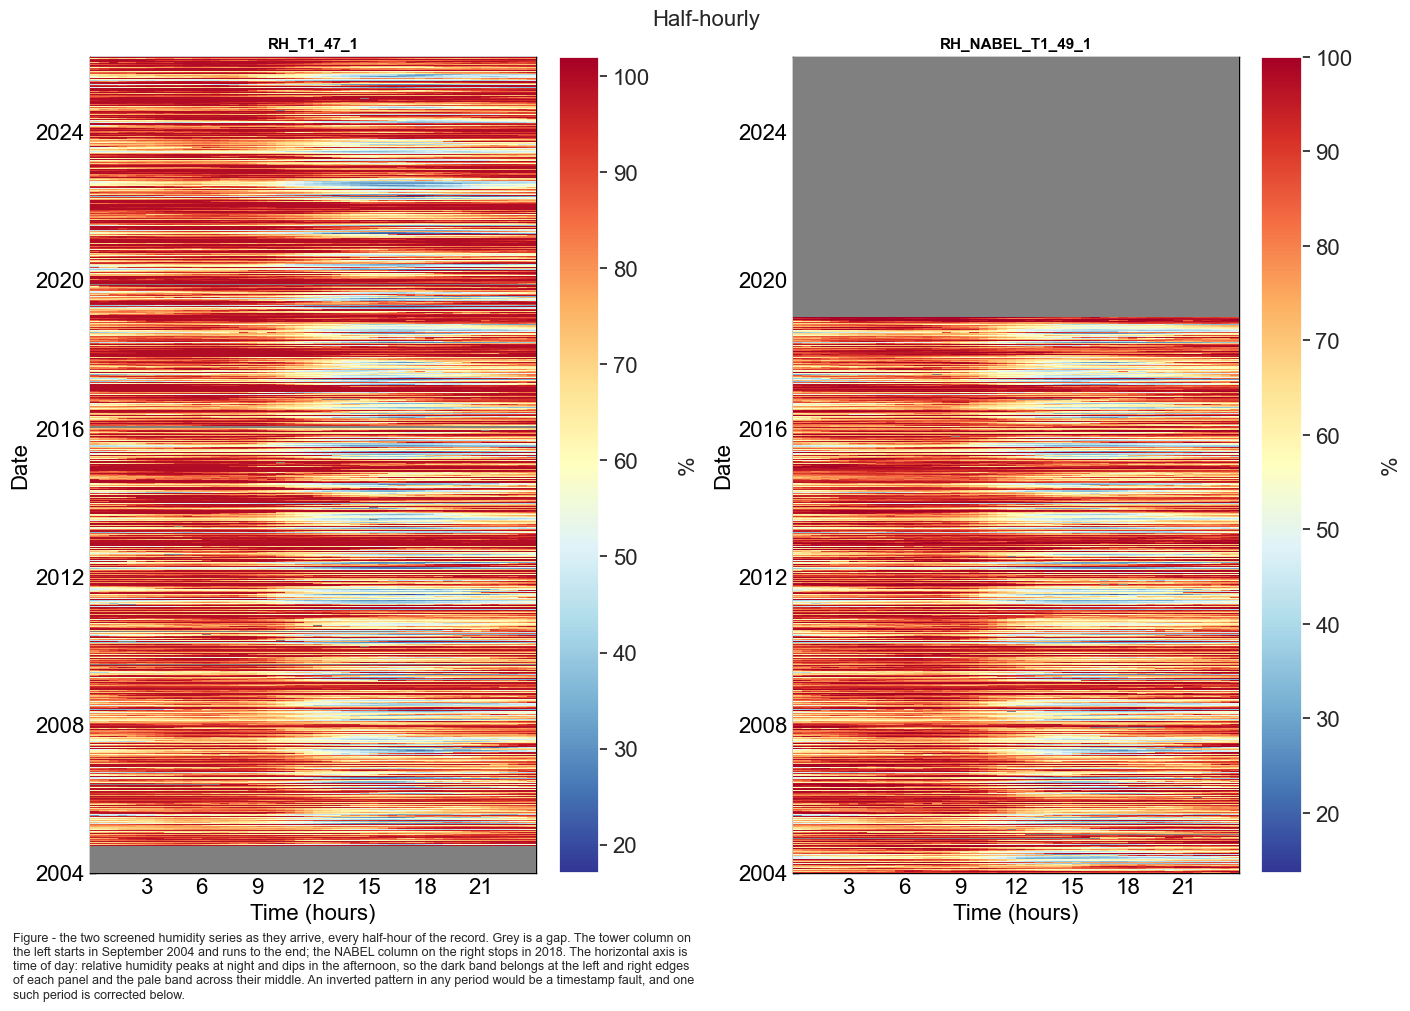

In [16]:
fig, axs = plt.subplots(ncols=2, figsize=(14, 10), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.plotting.HeatmapDateTime(series=rh_2004_2025[TARGET]).plot(
    ax=axs[0], cb_digits_after_comma=0, zlabel='%',
    format_style=dv.plotting.FormatStyle(title=TARGET, title_fontsize=11))
dv.plotting.HeatmapDateTime(series=rh_2004_2025[REFERENCE]).plot(
    ax=axs[1], cb_digits_after_comma=0, zlabel='%',
    format_style=dv.plotting.FormatStyle(title=REFERENCE, title_fontsize=11))
figcap(fig, "the two screened humidity series as they arrive, every half-hour of the record. "
            "Grey is a gap. The tower column on the left starts in September 2004 and runs to "
            "the end; the NABEL column on the right stops in 2018. The horizontal axis is time "
            "of day: relative humidity peaks at night and dips in the afternoon, so the dark "
            "band belongs at the left and right edges of each panel and the pale band across "
            "their middle. An inverted pattern in any period would be a timestamp fault, and "
            "one such period is corrected below.")


***

## ✴️ Corrections


### Order of the correction steps

The three steps below run in a fixed order, and the order matters:

1. **Timestamp shift** (August 2012). It moves records along the time axis, so every window
   defined afterwards refers to the corrected axis.
2. **Removal of the three damaged 2012 periods.** These records are faulty, and some of them
   read above 100%.
3. **`RH > 100%` offset correction.** It derives its offset from the daily mean of the records
   that exceed 100%, so it must not see the faulty ones. Running step 3 before step 2 would let
   damaged records set the offset that is then subtracted from good data on neighbouring days.
   The cell in step 2 reports how many of the removed records exceeded 100%.

Two reconstruction passes — **from NABEL, then from MeteoSwiss Lägern** — run after all three in
their own sections below. They must come last: they fill gaps, so everything that creates or
repairs a gap has to have happened first, and the offsets they fit between the sensors have to be
fitted on *corrected* 47 m data.

Steps 2 and 3 both need care around gaps, for opposite reasons. Step 2 *creates* gaps and their
provenance has to be recorded before step 3 runs. Step 3 is checked below to confirm it does not
*write into* gaps — the correction in notebook `03` does exactly that.

### Timestamp shift in August 2012
**Info from fieldbook entry 17 Aug 2012:**
>   adjusted the logger date and time. On Servertime (Computer System Time) 17.08.2012 12:31.42 the loggertime was 16.08.2012 08:06:00. Synchronized time at 17.08.2012 11:40:00 servertime. The logger data aquisition on the moxa embedded was restarted

This is a clock error of the logger, so it affects every variable that logger recorded. The same
correction as in notebooks `01`-`03` is applied here to `RH_T1_47_1`.

**Verified for `RH` rather than assumed.** Aligning `RH_T1_47_1` against the independent NABEL
sensor day by day and searching for the lag that agrees best (baseline agreement between the two
sensors in August is about 2.0 %, see the monthly table further down):

| date | best lag | RMSE at best lag | RMSE at zero lag |
|---|---|---|---|
| 2012-08-08 | -38.0 h | 16.49 | 21.78 |
| 2012-08-09 | +16.0 h | 5.61 | 13.54 |
| **2012-08-10** | **+15.5 h** | **1.13** | 11.38 |
| **2012-08-11** | **+15.5 h** | **1.56** | 13.88 |
| **2012-08-12** | **+15.5 h** | **2.23** | 26.30 |
| **2012-08-13** | **+15.5 h** | **2.13** | 25.01 |
| **2012-08-14** | **+15.5 h** | **1.20** | 18.57 |
| **2012-08-15** | **+15.5 h** | **3.37** | 37.26 |
| **2012-08-16** | **+15.5 h** | **1.68** | 21.57 |
| 2012-08-17 | 0 | 1.06 | 1.06 |

10 to 16 August lock onto `+15.5 h` and the error collapses from 11-37 % to 1.1-3.4 %, back inside
the normal agreement band. That is the signature of a genuine clock offset, and it is the same
`+15.5 h` found for `SW_IN`, `TA` and `PPFD_IN`. After the shift is applied, the same day-by-day
search over 10-19 August returns a best lag of 0 with RMSE 0.75-3.18, i.e. nothing left to repair.

The heatmaps below show the diurnal pattern before and after. `RH` peaks at night and dips in the
afternoon, so the visual check is the inverse of the temperature one: after the correction the
*moist* band has to sit around the night again.

RH_T1_47_1: 376 records moved +15.5 h, last shifted timestamp 2012-08-17 11:15:00


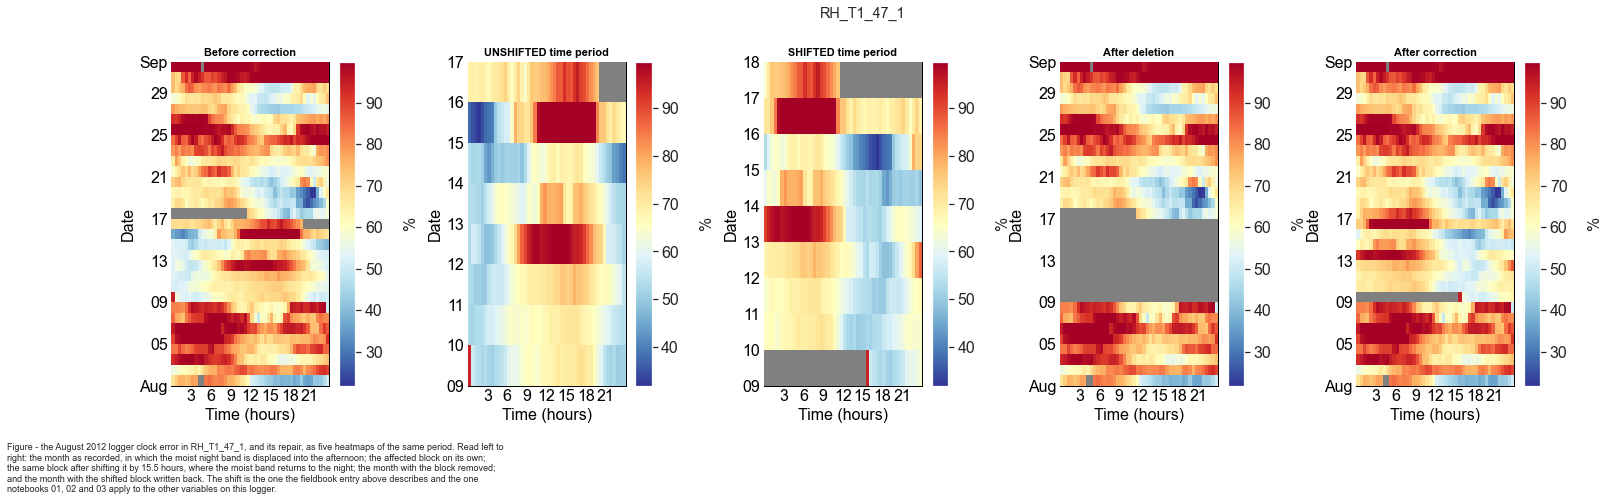

In [17]:
AFFECTED_VARS = [TARGET]
_df = rh_2004_2025.copy()

for av in AFFECTED_VARS:
    fig = plt.figure(figsize=(24, 6), dpi=72)
    fig.suptitle(f"{av}")
    gs = gridspec.GridSpec(1, 5)  # rows, cols
    gs.update(wspace=0.5, hspace=1, left=.1, right=.9, top=.85, bottom=.1)
    ax_before = fig.add_subplot(gs[0, 0])
    ax_unshifted = fig.add_subplot(gs[0, 1])
    ax_shifted = fig.add_subplot(gs[0, 2])
    ax_after = fig.add_subplot(gs[0, 3])
    ax_corrected = fig.add_subplot(gs[0, 4])

    # Show time period around issue, before correction
    _show_locs = (_df.index >= '2012-08-01 00:00') & (_df.index <= '2012-09-01 00:00')
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_before, cb_digits_after_comma=0, zlabel='%',
        format_style=dv.plotting.FormatStyle(title="Before correction", title_fontsize=11))

    # Get shifted time period
    _series_corrected = _df.loc[_show_locs, av].copy()
    # Identify shifted time period
    ISSUE_START = '2012-08-09 00:00'
    ISSUE_END = '2012-08-17 00:00'
    _shifted_locs = (_df.index >= ISSUE_START) & (_df.index <= ISSUE_END)
    _series_shifted = _df.loc[_shifted_locs, av].copy()
    _series_shifted = _series_shifted.dropna()
    dv.plotting.HeatmapDateTime(series=_series_shifted).plot(
        ax=ax_unshifted, cb_digits_after_comma=0, zlabel='%',
        format_style=dv.plotting.FormatStyle(title="UNSHIFTED time period", title_fontsize=11))

    # Shift by 15.5 hours during shifted time period, create corrected time series
    _series_shifted.index = _series_shifted.index + pd.Timedelta(hours=15.5)
    dv.plotting.HeatmapDateTime(series=_series_shifted).plot(
        ax=ax_shifted, cb_digits_after_comma=0, zlabel='%',
        format_style=dv.plotting.FormatStyle(title="SHIFTED time period", title_fontsize=11))

    # Delete data between start of issue and the last timestamp of shifted data
    _overwrite_locs = (_df.index >= ISSUE_START) & (_df.index <= _series_shifted.index[-1])
    _df.loc[_overwrite_locs, av] = np.nan
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_after, cb_digits_after_comma=0, zlabel='%',
        format_style=dv.plotting.FormatStyle(title="After deletion", title_fontsize=11))

    # Fill in corrected values
    _df.loc[_overwrite_locs, av] = _series_shifted
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_corrected, cb_digits_after_comma=0, zlabel='%',
        format_style=dv.plotting.FormatStyle(title="After correction", title_fontsize=11))

    figcap(fig, f"the August 2012 logger clock error in {av}, and its repair, as five "
                f"heatmaps of the same period. Read left to right: the month as recorded, in "
                f"which the moist night band is displaced into the afternoon; the affected block "
                f"on its own; the same block after shifting it by 15.5 hours, where the moist "
                f"band returns to the night; the month with the block removed; and the month "
                f"with the shifted block written back. The shift is the one the fieldbook entry "
                f"above describes and the one notebooks 01, 02 and 03 apply to the other "
                f"variables on this logger.")
    print(f"{av}: {len(_series_shifted)} records moved +15.5 h, "
          f"last shifted timestamp {_series_shifted.index[-1]}")

In [18]:
rh_2004_2025 = _df.copy()
tabcap("the series after the August 2012 clock error has been shifted back onto the correct time axis")
rh_2004_2025

Table - the series after the August 2012 clock error has been shifted back onto the correct time
axis



,RH_T1_47_1,RH_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,96.366667
2004-01-01 00:45:00,NaN,95.566667
2004-01-01 01:15:00,NaN,92.200000
2004-01-01 01:45:00,NaN,91.300000
2004-01-01 02:15:00,NaN,92.633333
...,...,...
2025-12-31 21:45:00,42.332976,NaN
2025-12-31 22:15:00,39.230344,NaN
2025-12-31 22:45:00,55.771803,NaN


### Record the gaps that exist before any further correction

Captured **now**, before the removals and before the `RH > 100%` correction, so that
"never measured" means exactly that.

This ordering is not optional. In notebook `03` the nighttime zero-offset correction writes a
value of `0` into *every* nighttime record including the missing ones, which made 7,543 modelled
values look like measurements when the mask was taken afterwards. The equivalent risk is checked
explicitly for the `RH` correction further down.

In [19]:
never_measured = rh_2004_2025[TARGET].isna()
print(f"Never measured: {int(never_measured.sum()):,} of {len(rh_2004_2025):,} records")

Never measured: 15,434 of 385,728 records


### Power failure, late July to mid August 2012

The clock shift is not the only damage in 2012. The same day-by-day lag search against NABEL, on
the **uncorrected** axis:

| date | best lag | RMSE at best lag | RMSE at zero lag |
|---|---|---|---|
| 2012-07-27 | 0 | 1.86 | 1.86 |
| 2012-07-28 | 0 | 2.63 | 2.63 |
| 2012-07-29 | 0 | 2.31 | 2.31 |
| 2012-07-30 | 0 | 9.15 | 9.15 |
| 2012-07-31 | -25.5 h | 9.03 | 21.88 |
| 2012-08-01 | -1.0 h | 6.80 | 7.47 |
| 2012-08-03 | 0 | 6.45 | 6.45 |
| 2012-08-05 | +0.5 h | 7.86 | 7.98 |
| 2012-08-07 | -48.0 h | 12.61 | 13.82 |
| 2012-08-08 | -38.0 h | 16.49 | 21.78 |

From 30 July to 8 August the agreement sits at 6-16 % whatever lag is applied, against a normal
2.0 %. No shift repairs it, so this is not a clock problem — the apparent best lags near ±24 and
±48 h are aliases, since shifting a daily cycle by about a day roughly realigns it. The fieldbook
gives the cause and dates the repair to the day the degradation ends:

> **09.08.2012** Fixed the power problem on the tower: replaced battery and replaced some fuses
> (there were many falsely placed or broken) and replaced the whole power supply
>
> **10.08.2012** Some problems remain with logger, maybe it's the WLAN (could not log in the last
> two weeks), restared programs

`SW_IN`, `TA` and `PPFD_IN` degrade over the same window on the same acquisition system,
consistent with a supply fault upstream of all of them rather than with four sensors failing at
once.

### Storm damage, late October to early November 2012

A third damaged period, found the same way. In this stable, near-saturated autumn period the lag
search is dominated by daily aliases even on healthy days, so the **zero-lag** column is the one
to read:

| date | best lag | RMSE at best lag | RMSE at zero lag |
|---|---|---|---|
| 2012-10-26 | -34.0 h | 0.88 | 1.21 |
| 2012-10-27 | -27.5 h | 1.01 | 1.68 |
| 2012-10-28 | -48.0 h | 0.92 | 2.52 |
| 2012-10-29 | -47.5 h | 1.23 | 9.80 |
| 2012-10-30 | -48.0 h | 2.44 | 20.24 |
| 2012-11-01 | -48.0 h | 12.26 | 16.51 |
| 2012-11-04 | -22.0 h | 8.64 | 33.45 |
| 2012-11-07 | -34.0 h | 6.57 | 20.37 |
| 2012-11-09 | -43.5 h | 7.48 | 12.51 |
| 2012-11-10 | 0 | 4.11 | 4.11 |
| 2012-11-12 | -3.5 h | 1.38 | 1.40 |

Agreement collapses from 29 October, stays at 12-33 % through 9 November and returns to normal
from 12 November, right after the repair visit. The fieldbook records storm damage and cable work
in exactly this window:

> **01.11.2012** Checked Forestfloor and Hut for broken sensors due to fallen trees and big branches
>
> **06.11.2012** checked all sensor cables. especialy the cables at the forest floor are sometimes
> strongly stressed. tried to unstress the cables

Both entries name the *forest floor* sensors rather than the 47 m instruments, so the link is
circumstantial: what is certain is that a storm hit the site, that cables were found stressed,
and that the recovery follows the repair visit.

### Where `RH` disagrees with the shared windows

The three windows below are the ones removed from `SW_IN`, `TA` and `PPFD_IN`. They are kept
**unchanged** here so that all four meteo products exclude exactly the same periods, which matters
for anything that combines them — notebook `07` pairs this series with `TA` to compute VPD. Two of
them are slightly wider than the `RH` evidence alone would require:

- **Window 1 starts 29 July**, but `RH` is still healthy on that day (2.31 % against a 2.0 %
  baseline) and only degrades from 30 July. Costs one good day of measurement.
- **Window 3 starts 28 October**, but `RH` is still acceptable on that day (2.52 % at zero lag)
  and only degrades from 29 October. Costs one good day of measurement.
- **Window 2** (the transitional tail after the last shifted value) holds 17 `RH` records that
  measure well, at 1.1 %. There is no `RH`-specific reason to drop them.

Notebook `02` made the same one-good-day trade-off for `TA` in October. About 113 records out of
385,728 are affected, and because NABEL covers all three windows they are reconstructed rather
than lost — the cost is that ~113 genuine measurements are replaced by estimates carrying about
3 % uncertainty, not that they disappear. Consistency across the four products is worth that, so
nothing is trimmed. The alternative — an `RH`-specific mask — would let a VPD calculation combine
a removed `TA` period with a kept `RH` period.

Removed 1215 measured records from RH_T1_47_1.
These become gaps here; the reconstruction section below fills them from NABEL.
Of these, 3 read above 100% - they would otherwise have
contributed to the offset of the RH>100% correction, which is why that step runs after this one.


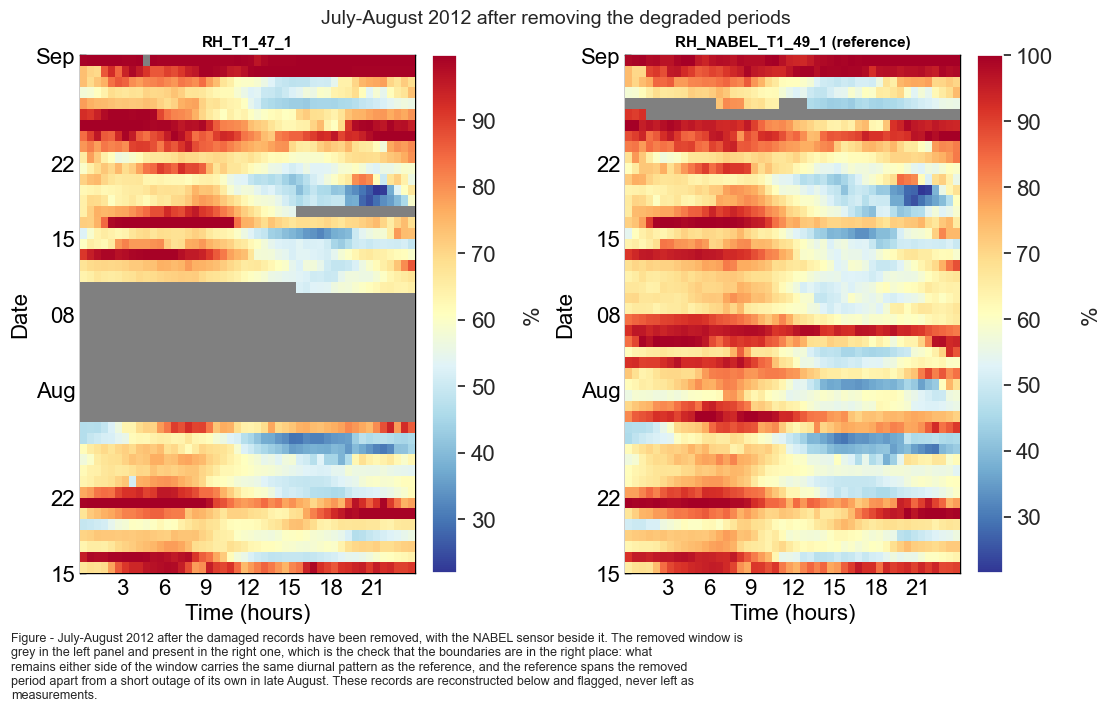

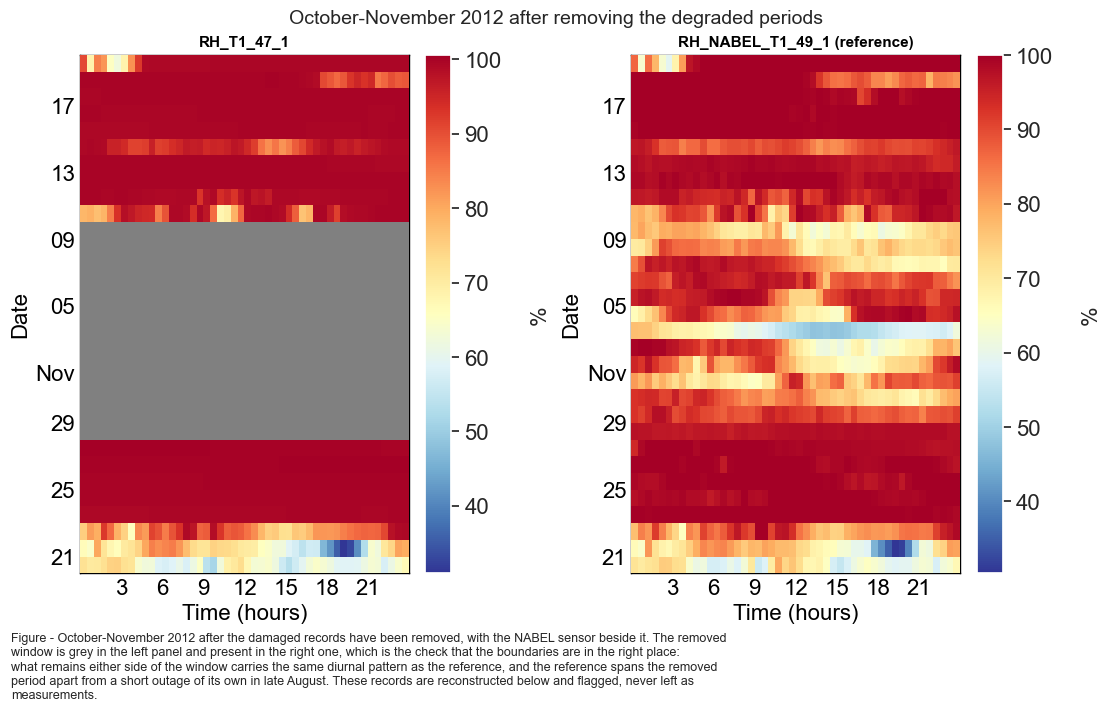

In [20]:
# Three damaged periods in 2012, all documented in the fieldbook and none repairable.
# Windows are on the CORRECTED time axis (i.e. after the +15.5 h shift above) and are identical
# to those removed in notebooks 01, 02 and 03. See the note above on where RH would differ.
BAD_WINDOWS_2012 = [
    ('2012-07-29 00:00', '2012-08-10 15:30'),  # tower power supply failure (fieldbook 09.08.2012)
    ('2012-08-17 15:30', '2012-08-18 00:00'),  # transitional tail after the last shifted value
    ('2012-10-28 00:00', '2012-11-10 00:00'),  # storm damage, stressed cables (fieldbook 01./06.11.2012)
]

# Recorded per record, not just counted: this is what separates flag 2 from flag 1 on export.
removed_here = pd.Series(False, index=rh_2004_2025.index)
_exceeded_and_removed = 0
for _start, _end in BAD_WINDOWS_2012:
    _locs = (rh_2004_2025.index >= _start) & (rh_2004_2025.index <= _end)
    _measured = _locs & rh_2004_2025[TARGET].notna()
    _exceeded_and_removed += int((rh_2004_2025.loc[_measured, TARGET] > 100).sum())
    removed_here |= _measured
    rh_2004_2025.loc[_locs, TARGET] = np.nan

print(f"Removed {int(removed_here.sum())} measured records from {TARGET}.")
print("These become gaps here; the reconstruction section below fills them from NABEL.")
print(f"Of these, {_exceeded_and_removed} read above 100% - they would otherwise have")
print(f"contributed to the offset of the RH>100% correction, which is why that step runs after this one.")

# One heatmap pair per affected period, with the NABEL sensor as the reference.
for _lo, _hi, _label in [('2012-07-15', '2012-09-01', 'July-August'),
                         ('2012-10-20', '2012-11-20', 'October-November')]:
    fig, axs = plt.subplots(ncols=2, figsize=(11, 7), dpi=100, layout="constrained")
    fig.suptitle(f'{_label} 2012 after removing the degraded periods', fontsize=14)
    _show = (rh_2004_2025.index >= _lo) & (rh_2004_2025.index <= _hi)
    dv.plotting.HeatmapDateTime(series=rh_2004_2025.loc[_show, TARGET]).plot(
        ax=axs[0], cb_digits_after_comma=0, zlabel='%',
        format_style=dv.plotting.FormatStyle(title=TARGET, title_fontsize=11))
    dv.plotting.HeatmapDateTime(series=rh_2004_2025.loc[_show, REFERENCE]).plot(
        ax=axs[1], cb_digits_after_comma=0, zlabel='%',
        format_style=dv.plotting.FormatStyle(title=f'{REFERENCE} (reference)', title_fontsize=11))
    figcap(fig, f"{_label} 2012 after the damaged records have been removed, with the "
                f"NABEL sensor beside it. The removed window is grey in the left panel and "
                f"present in the right one, which is the check that the boundaries are in the "
                f"right place: what remains either side of the window carries the same diurnal "
                f"pattern as the reference, and the reference spans the removed period apart "
                f"from a short outage of its own in late August. These records are reconstructed "
                f"below and flagged, never left as measurements.")


### December 2012 ventilation faults: checked, not applicable

The fieldbook records ventilation faults on the `RH`/`TA` units at **9 m and 27 m** in December
2012. The sensor exported here sits at **47 m**, on its own ventilated housing, so it should be
unaffected — but "should be" is not evidence, so the daily agreement with NABEL was compared
against the seasonal norm.

Daily RMSE between `RH_T1_47_1` and NABEL, median over all years 2004-2018, by month:

| month | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| median | 3.42 | 3.83 | 2.94 | 2.13 | 2.18 | 2.06 | 2.03 | 2.01 | 2.05 | 2.53 | 2.92 | 3.13 |

The two sensors agree to about 2 % in summer and drift apart to 3-4 % in winter. That winter
divergence is a known, unresolved property of this 47 m / 49 m pair and is **not** a fault.

December medians per year: 2010 `3.69`, 2011 `3.85`, **2012 `3.90`**, 2013 `3.53`, 2014 `3.99`,
2015 `3.93`, 2016 `7.12`, 2017 `8.72`.

December 2012 is indistinguishable from the Decembers on either side of it, and far better than
2016 and 2017. Five of its 30 days exceed the all-year December 90th percentile, which is what
chance alone produces. **No correction is applied for this**, and the December data are kept.

### `RH > 100%` correction

Relative humidity cannot physically exceed 100%. Values above it indicate sensor drift near
saturation, and `dv.corrections.remove_relativehumidity_offset` removes it: it derives a daily
offset from the records above 100%, subtracts that offset from the series, and clips whatever
still sits above 100%.

**Scope.** The library function interpolates its daily offset and then ffill/bfills it across the
entire index, so a single call on the whole record also shifts years that never exceed 100%. Over
this record that means a flat `+0.71 %` across 2004-2006 and a flat `+0.133 %` across 2016-2025 —
ten years with not one value above 100. Subtracting a measured drift from records below 100% is
the point of the correction; extrapolating it into a decade with no evidence of drift is not. So
`remove_rh_offset_by_year` (defined above) runs the correction **per exceedance year**, and years
without an exceedance come through bit-identical.

**What this correction does and does not guarantee.**

- It **does** guarantee `RH <= 100` in the years it runs in: the final clip is unconditional.
  Years it skips are guaranteed by construction, since having no value above 100 is what makes
  them skipped. The export check below asserts the bound over the whole series regardless.
- It does **not** guarantee `RH >= 0`. The offset is subtracted from every record in the year,
  including dry ones, and nothing clips the lower end. With a large offset and a genuinely dry
  record the result can go negative. It does not happen here — the offsets are at most 2.0 % and
  the driest record is far above that — but the export check asserts the lower bound rather than
  assuming it.
- It does **not** repair a saturated sensor. A drifting sensor loses resolution near 100%, and
  subtracting an offset does not bring that information back. These records are corrected, not
  restored.

**Gap safety.** The correction subtracts an offset that is defined everywhere from a series that
is not, and `NaN - x` is `NaN`, so gaps stay gaps. This was verified on the real series rather
than assumed, and the cell below re-checks it — the analogous correction in notebook `03` writes
into gaps and silently turned 7,543 fills into apparent measurements.

In [21]:
# Kept for the sensor-identity section below, which counts the records that read above
# 100 % before this correction removed them. After this cell the pre-correction series
# is otherwise unrecoverable.
RAW_BEFORE_CORRECTION = rh_2004_2025[TARGET].copy()
_before = RAW_BEFORE_CORRECTION.copy()
rh_2004_2025[TARGET], _exceed_years = remove_rh_offset_by_year(rh_2004_2025[TARGET])
_after = rh_2004_2025[TARGET]

_changed = (_after - _before).abs() > 1e-9
print(f"Correction applied in years: {_exceed_years}")
print(f"Records above 100%:  before {int((_before > 100).sum()):,}   after {int((_after > 100).sum()):,}")
print(f"Records changed:     {int(_changed.sum()):,} of {int(_before.notna().sum()):,} measured")
print(f"Largest change:      {float((_after - _before).abs().max()):.2f} %")
print(f"Untouched years:     {sorted(set(range(_before.index.year.min(), _before.index.year.max() + 1)) - set(_exceed_years))}")

# Gap safety: the correction must not invent a value where there was none.
_written_into_gaps = int((_before.isna() & _after.notna()).sum())
print(f"\nValues written into gaps: {_written_into_gaps}")
assert _written_into_gaps == 0, "correction wrote into gaps - the provenance flag would be wrong"

# Per-year effect, so an unexpectedly shifted year is visible rather than buried in the total.
_eff = pd.DataFrame({
    'exceeded_100_before': (_before > 100).groupby(_before.index.year).sum(),
    'records_changed': _changed.groupby(_changed.index.year).sum(),
    'mean_change': (_before - _after).groupby(_before.index.year).mean().round(3),
    'max_change': (_before - _after).groupby(_before.index.year).max().round(2),
})
tabcap("what the RH > 100 % correction did, year by year. A year with no exceedance is not touched at all, and every year it does run in belongs to the analog probe - which is the independent evidence of drift the sensor-identity section below rests on")
_eff

> running remove_relativehumidity_offset ...

> running remove_relativehumidity_offset ...

> running remove_relativehumidity_offset ...

> running remove_relativehumidity_offset ...

> running remove_relativehumidity_offset ...

> running remove_relativehumidity_offset ...

> running remove_relativehumidity_offset ...

Correction applied in years: [2007, 2010, 2011, 2012, 2013, 2014, 2015]
Records above 100%:  before 1,931   after 0
Records changed:     121,123 of 369,079 measured
Largest change:      2.00 %
Untouched years:     [2004, 2005, 2006, 2008, 2009, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

Values written into gaps: 0
Table - what the RH > 100 % correction did, year by year. A year with no exceedance is not touched
at all, and every year it does run in belongs to the analog probe - which is the independent
evidence of drift the sensor-identity section below rests on



,exceeded_100_before,records_changed,mean_change,max_change
TIMESTAMP_MIDDLE,,,,
2004,0,0,0.000,0.0
2005,0,0,0.000,0.0
2006,0,0,0.000,0.0
2007,53,17507,0.312,1.1
2008,0,0,0.000,0.0
2009,0,0,0.000,0.0
2010,132,17351,0.140,0.3
2011,416,17499,0.454,2.0
2012,131,16308,0.108,0.6


### Dataframe


In [22]:
display(rh_2004_2025)
tabcap("the distribution of the two humidity series after every correction and before any reconstruction")
rh_2004_2025.describe()

,RH_T1_47_1,RH_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,96.366667
2004-01-01 00:45:00,NaN,95.566667
2004-01-01 01:15:00,NaN,92.200000
2004-01-01 01:45:00,NaN,91.300000
2004-01-01 02:15:00,NaN,92.633333
...,...,...
2025-12-31 21:45:00,42.332976,NaN
2025-12-31 22:15:00,39.230344,NaN
2025-12-31 22:45:00,55.771803,NaN


Table - the distribution of the two humidity series after every correction and before any
reconstruction



,RH_T1_47_1,RH_NABEL_T1_49_1
count,369079.000000,262314.000000
mean,79.519055,76.902333
std,18.823475,18.123961
min,16.990002,13.666667
25%,65.756900,63.900000
50%,83.185047,80.100000
75%,98.244663,92.933333
max,100.000000,100.000000


::: {.callout-note title="The NABEL series is not corrected"}
`RH_NABEL_T1_49_1` never exceeds 100% anywhere in this record, so the `RH > 100%` correction would
be a no-op for it and is not applied. It is used below as the source for reconstruction, and is
not itself exported.
:::

***

## 🔎 Which sensor this is, and what the hardware change did to it

`RH_T1_47_1` is measured by **the same instrument as `TA_T1_47_1`**. The CR1000 program declares
one variable pair and fills it with a single sensor call, so the two variables are two numbers
returned by one probe. That probe was replaced on **21 January 2016**, together with the logger
that read it, and notebook `02` established that the change moved `TA_T1_47_1` by about 1.3 °C and
needed a two-term correction and a homogenised column.

Whether the same change moved `RH` had never been asked. This section asks it, and the answer is
yes.

1. **the exported column is two probes, not one** — a Rotronic MP101A read as an analog voltage
   until January 2016, a Campbell CS215 read over SDI-12 afterwards, both named in the logger
   programs of their own era;
2. **the changeover is a 20-day outage in the data**, which dates the boundary without reference
   to any written record;
3. **one of the two references stops being independent in August 2018**, and is cut there;
4. **the series steps upwards at the changeover** by 2.1 to 3.3 percentage points of RH, and the
   pattern of which pairs move names the tower probe rather than either reference;
5. **the 100 % ceiling hides part of it** — away from saturation the step is half again as large,
   and it is strongly dependent on the humidity itself;
6. **it is present at every hour** and is larger at night than by day, which rules out the
   radiation-shield mechanism that explains part of the `TA` step;
7. **the probe that was replaced had drifted**, on evidence that needs no reference at all;
8. **there is no step at the December 2021 screening splice**, although the median of the series
   does rise across those years;
9. **the maintenance record cannot identify either probe**, and confirms rather than establishes
   what the logger programs say.

The consequences for the product are drawn at the end of the section: a `SOURCE` flag, an offset
fit split at the break, and no homogenised column.


### Helpers for this section

The logger programs and the maintenance record are read in the notebook rather than quoted, so
that a re-run re-derives the argument instead of inheriting a stale copy of it. Both are signed by
the people who did the work and this notebook renders to a public page, so every string taken out
of either passes through the same redaction used in notebooks `01`, `02`, `03` and `08`.


In [23]:
# --- Fieldbook and logger-program redaction ----------------------------------------------------
# The GIN export and the logger programs both name people. This notebook renders to a public page,
# so every string taken out of either passes through redact_people() at the single point where it
# is flattened. Same map and same rules as notebooks 01, 02, 03 and 08; the map lives beside the
# export, OUTSIDE this repository, so the repo never carries a real name.
REDACT_MAP = Path(FIELDBOOK).with_name('redact_names.csv')
ALLOW_LIST = Path(FIELDBOOK).with_name('redact_allow.csv')


def unmapped_report_path(label: str) -> Path:
    """Where the unmapped-name candidates of one audit are written.

    Per label, because this notebook audits three sources: a single shared file would let a later
    audit overwrite an earlier one's findings.
    """
    _slug = re.sub(r'[^a-z0-9]+', '_', label.lower()).strip('_')
    return Path(FIELDBOOK).with_name(f'redact_unmapped_{_slug}.txt')


def load_redactions(path=None) -> dict:
    """Load the name -> pseudonym map.

    Raises if the map is missing. That is the point: carrying on with redaction quietly disabled
    prints real names into a published page and looks exactly like success.
    """
    path = REDACT_MAP if path is None else Path(path)
    if not path.is_file():
        raise FileNotFoundError(
            f"the redaction map is missing: {path}. Without it the names these files record would "
            f"print unredacted. Restore the file rather than skipping this.")
    tab = pd.read_csv(path, encoding='utf-8')
    missing = {'name', 'pseudonym'}.difference(tab.columns)
    if missing:
        raise ValueError(f"{path}: missing column(s) {sorted(missing)}.")
    pairs = {str(n).strip(): str(p).strip()
             for n, p in zip(tab['name'], tab['pseudonym']) if str(n).strip()}
    if not pairs:
        raise ValueError(f"{path}: holds no usable name -> pseudonym pairs.")
    return pairs


REDACTIONS = load_redactions()
# Longest surface form first, so a bare surname cannot corrupt a double-barrelled one that starts
# with it. Lookarounds rather than \b, because some forms end in an initial.
_REDACT_RX = re.compile(r'(?<!\w)(' + '|'.join(re.escape(n) for n in
                                               sorted(REDACTIONS, key=len, reverse=True))
                        + r')(?!\w)')


def redact_people(s) -> str:
    """Replace every mapped name with its stable pseudonym."""
    return _REDACT_RX.sub(lambda m: REDACTIONS[m.group(1)], str(s))


def strip_html(text) -> str:
    """Flatten one GIN fieldbook entry to plain text, with the people it names redacted."""
    flat = html.unescape(re.sub(r'<[^>]+>', ' ', str(text)))
    return redact_people(re.sub(r'\s+', ' ', flat).strip())


_NAME_TOKEN = r"[A-ZÄÖÜ][\wÄÖÜäöüß'-]{1,20}"
_NAME_UNIT = _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r'){0,2}'
_NAME_SHAPES = (
    re.compile(r'\((' + _NAME_UNIT + r'(?:\s*[,+&]\s*' + _NAME_UNIT + r')*)\s*'
               r'(?:\d{1,2}\.\d{1,2}\.\d{4})?\)'),
    re.compile(r'(?:with|by|durch|von|gemaess)\s+(' + _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r')?)'),
)


def audit_unmapped_names(texts, label='fieldbook', write_report: bool = True) -> int:
    """Raise if any name-shaped token survived redaction.

    A newer export can name someone the map has never seen. Candidates are never printed - an
    exception message is stored in a notebook like any other output - so they go to a file beside
    the map and only the count is shown.
    """
    allow = set(pd.read_csv(ALLOW_LIST, encoding='utf-8')['term'].astype(str).str.strip())
    found = {}
    for _t in texts:
        for _rx in _NAME_SHAPES:
            for _m in _rx.finditer(str(_t)):
                for _tok in re.findall(_NAME_TOKEN, _m.group(1)):
                    if _tok.isupper() or any(ch.isdigit() for ch in _tok) or _tok in allow:
                        continue
                    found[_tok] = found.get(_tok, 0) + 1
    if found:
        _report = unmapped_report_path(label)
        if write_report:
            _report.write_text(
                '\n'.join(f'{n}\t{t}' for t, n in sorted(found.items(), key=lambda kv: -kv[1])),
                encoding='utf-8')
        raise ValueError(
            f"{label}: {len(found)} name-shaped token(s) survived redaction. They are deliberately "
            f"NOT shown here - see {_report}. Add the people to redact_names.csv and the "
            f"technical terms to redact_allow.csv, then re-run.")
    print(f"  {label}: no unmapped name-shaped tokens ({len(allow)} allowlisted terms)")
    return 0


def program_excerpt(path, pattern: str, before: int = 6, after: int = 4, expect: int = 1) -> str:
    """The lines of a logger program around `pattern`, redacted.

    Only the matched instruction is returned, never the file header: these programs are signed by
    their authors. Raises unless the pattern matches exactly `expect` times. Both directions
    matter: no match reads as 'the program does not measure this', and an over-broad pattern
    quietly prints the wrong instruction next to the argument it is supposed to support.
    """
    lines = Path(path).read_text(encoding='latin-1').splitlines()
    blocks = []
    for i, line in enumerate(lines):
        if re.search(pattern, line):
            lo, hi = max(0, i - before), min(len(lines), i + after + 1)
            blocks.append('\n'.join(lines[lo:hi]))
    if len(blocks) != expect:
        raise ValueError(f"{Path(path).name}: {pattern!r} matched {len(blocks)} time(s), expected "
                         f"{expect}. The program layout has changed, the wrong file is configured, "
                         f"or the pattern is not specific enough.")
    return redact_people('\n\n'.join(blocks))


def calibration_constants(excerpt: str) -> dict:
    """The multiplier and offset of one measurement instruction, parsed from its own text.

    The CR10X lists the two numbers as numbered parameters of a `Volt (SE)` instruction; the
    CR1000 passes them as the last two arguments of a `VoltSe(...)` or `VoltDiff(...)` call. Both
    shapes are matched on their own terms.

    Raises if either number cannot be found. That failure path is not a defect here, it is the
    argument: the CR1000 reads this sensor over **SDI-12**, which returns finished engineering
    units, so its instruction carries no multiplier and no offset at all and this function raises
    on it. A version that returned an empty result instead would let the two eras be compared by
    having nothing to disagree about.
    """
    if 'Mult' in excerpt:                                    # CR10X parameter listing
        _m = re.search(r'^\s*\d+:\s*([\d.]+)\s+Mult', excerpt, re.M)
        _o = re.search(r'^\s*\d+:\s*([\d.]+)\s+Offset', excerpt, re.M)
        tokens = [_m.group(1) if _m else None, _o.group(1) if _o else None]
    else:                                                    # CR1000 VoltSe/VoltDiff call
        _call = re.search(r'Volt(?:Se|Diff)\s*\(([^)]*)\)', excerpt)
        _args = [a.strip() for a in _call.group(1).split(',')] if _call else []
        tokens = _args[-2:] if len(_args) >= 2 else [None, None]
    values = []
    for _tok in tokens:
        if _tok is None:
            raise ValueError("could not parse a multiplier and an offset from the instruction - "
                             "the program language or the layout has changed, or the measurement "
                             "is not an analog voltage at all")
        values.append(float(_tok))
    return {'multiplier': values[0], 'offset': values[1]}


#### Negative controls

Each helper is fed input it must refuse, before any of them is trusted with input that matters.


In [24]:
# The guards guard. A helper that silently returns nothing is worse than no helper, so every
# failure path is exercised before anything is read.
try:
    program_excerpt(PROGRAM_CR1000, r'ThisPatternIsNotInAnyLoggerProgram')
except ValueError as _exc:
    print(f"OK, program_excerpt raised on a pattern that does not occur: {_exc}")
else:
    raise AssertionError("(!) program_excerpt accepted a pattern that does not occur.")

# ... and on one that occurs more than once, which is the direction that would otherwise print
# the wrong instruction beside the argument it is meant to support.
try:
    program_excerpt(PROGRAMS_CR10X[0], r'RelHum')
except ValueError as _exc:
    print(f"OK, program_excerpt raised on an over-broad pattern: {_exc}")
else:
    raise AssertionError("(!) program_excerpt accepted a pattern matching more than once.")

# 'Ada Lovelace' is nobody at this site, so the control can spell her out without disclosing
# anything - and it writes no report, so the real one is not overwritten by a test.
try:
    audit_unmapped_names(['12.05.2019 (Ada Lovelace) replaced the logger battery'],
                         'positive control', write_report=False)
except ValueError:
    print("OK, the unknown-name net fired on a name that is not in the map")
else:
    raise AssertionError("(!) the unknown-name net did not fire on an unmapped name.")

# And the constant parser must refuse an instruction it cannot read. For this variable that path
# is not hypothetical: it is the SDI-12 instruction of the CR1000 program, exercised for real in
# step 1 below.
try:
    calibration_constants('SDI12Recorder(TARH_T1_47_1(),3,"0","M!",1,0)')
except ValueError as _exc:
    print(f"OK, calibration_constants raised on an instruction with no constants: {_exc}")
else:
    raise AssertionError("(!) calibration_constants accepted an instruction carrying no constants.")


OK, program_excerpt raised on a pattern that does not occur: CH-LAE_iDL_T1_47_1.CR1: 'ThisPatternIsNotInAnyLoggerProgram' matched 0 time(s), expected 1. The program layout has changed, the wrong file is configured, or the pattern is not specific enough.
OK, program_excerpt raised on an over-broad pattern: LAEGEREN.20040526.CSI: 'RelHum' matched 4 time(s), expected 1. The program layout has changed, the wrong file is configured, or the pattern is not specific enough.


OK, the unknown-name net fired on a name that is not in the map
OK, calibration_constants raised on an instruction with no constants: could not parse a multiplier and an offset from the instruction - the program language or the layout has changed, or the measurement is not an analog voltage at all


### 1️⃣ Two probes, one column

`RH_T1_47_1` is the name of a variable, not of an instrument. The six surviving CR10X programs of
2004-2006 all measure a **Rotronic MP101A**, named in their own comments, on a single-ended analog
channel at multiplier `0.1` and offset `0` — the sensor delivers 0-1000 mV for 0-100 % RH and the
logger scales it. The CR1000 program installed at the changeover measures a **Campbell CS215**
over SDI-12, and declares `TA_T1_47_1` and `RH_T1_47_1` as the two elements of one variable pair
filled by one sensor call.

::: {.callout-note title="There is no multiplier to compare after 2016"}
SDI-12 returns finished engineering units, so the CR1000 instruction carries no multiplier and no
offset at all: the calibration of the later era lives inside the probe, where no logger program
records it and no re-reading of these files can check it. The two eras therefore **cannot** be
compared by their conversions, which is how notebook `01` settles the same question for `SW_IN`.
The argument here has to rest on the sensor identity and on the data, and the cell below makes
that explicit by showing that the constant parser raises on the SDI-12 instruction.
:::


In [25]:
# Which instrument the exported column is, read out of the logger programs rather than assumed.
# Every surviving CR10X program is parsed, not one of them read: a multiplier that changed inside
# that era would put a step in the record that has nothing to do with 2016.
CR10X_RH, _cr10x_excerpts = {}, []
for _p in PROGRAMS_CR10X:
    _ex = program_excerpt(_p, r'Loc \[ RelHum', before=4, after=3)
    _cr10x_excerpts.append(_ex)
    CR10X_RH[Path(_p).name] = calibration_constants(_ex)

_probe_comment = program_excerpt(PROGRAMS_CR10X[0], r'Rotronic MP101A', before=1, after=1)
print(f"--- {Path(PROGRAMS_CR10X[0]).name}: the probe, named in the program's own comment")
print(_probe_comment)
print(f"\n--- {Path(PROGRAMS_CR10X[0]).name}: how its relative-humidity output is converted")
print(_cr10x_excerpts[0])

# The CR1000 side. Two facts, both read out of the program: the successor is a Campbell CS215,
# and TA and RH arrive from ONE probe in ONE call - which is what ties this variable to the 1.3 degC
# step notebook 02 measures in TA.
_ex_decl = program_excerpt(PROGRAM_CR1000, r'Alias TARH_T1_47_1\(2\)', before=2, after=0)
_ex_sdi = program_excerpt(PROGRAM_CR1000, r'SDI12Recorder\(TARH_T1_47_1', before=1, after=0)
print(f"\n--- {Path(PROGRAM_CR1000).name}: the declaration")
print(_ex_decl)
print(f"\n--- {Path(PROGRAM_CR1000).name}: the measurement")
print(_ex_sdi)

audit_unmapped_names(_cr10x_excerpts + [_probe_comment, _ex_decl, _ex_sdi], 'logger programs')

tabcap("the conversion every surviving CR10X program applies to the relative-humidity channel, "
       "oldest first. All six agree, so nothing inside the analog era can have rescaled this "
       "series; the CR1000 row is empty because SDI-12 has no multiplier to record")
_prog = pd.DataFrame(CR10X_RH).T
_prog.index.name = 'logger program'
_prog['probe'] = 'Rotronic MP101A'
_prog['acquisition'] = 'single-ended analog voltage, channel 3'
_prog.loc[Path(PROGRAM_CR1000).name] = [np.nan, np.nan, 'Campbell CS215', 'SDI-12 address 0, M!']
display(_prog)

# One conversion across every program of the analog era.
_mults = {v['multiplier'] for v in CR10X_RH.values()}
_offsets = {v['offset'] for v in CR10X_RH.values()}
print(f"\ndistinct multipliers over the {len(CR10X_RH)} CR10X programs: {sorted(_mults)}")
print(f"distinct offsets: {sorted(_offsets)}")
assert _mults == {0.1} and _offsets == {0.0}, (
    "the CR10X programs no longer all apply the same conversion to the relative-humidity channel, "
    "so a step inside the analog era is possible and this section must be re-derived")

# And the CR1000 instruction really does carry no constants to compare. This is not a defect of
# the parser, it is the finding: the argument that follows cannot rest on the conversion, because
# after 2016 there is no conversion to read.
try:
    calibration_constants(_ex_sdi)
except ValueError:
    print("\nThe CR1000 instruction carries no multiplier and no offset: SDI-12 returns finished "
          "engineering units, so the sensor's calibration lives inside the probe where no logger "
          "program records it. The two eras therefore cannot be compared by their conversions, "
          "and the rest of this section rests on the sensor identity above and on the data.")
else:
    raise AssertionError("(!) the CR1000 instruction now parses as an analog conversion, so this "
                         "sensor is no longer read over SDI-12 and this step must be re-derived.")


--- LAEGEREN.20040526.CSI: the probe, named in the program's own comment
;--------------------------------------------------------
; Rotronic MP101A temperature and relative humidity probe
;--------------------------------------------------------

--- LAEGEREN.20040526.CSI: how its relative-humidity output is converted
8:  Volt (SE) (P1)
 1: 1        Reps
 2: 35       2500 mV 50 Hz Rejection Range
 3: 3        SE Channel
 4: 19       Loc [ RelHum    ]
 5: 0.1      Mult
 6: 0.0      Offset


--- CH-LAE_iDL_T1_47_1.CR1: the declaration
Public TARH_T1_47_1(2)
Alias TARH_T1_47_1(1)=TA_T1_47_1
Alias TARH_T1_47_1(2)=RH_T1_47_1

--- CH-LAE_iDL_T1_47_1.CR1: the measurement
		'C'CS215 Temperature & Relative Humidity Sensor measurements 'TA_T1_47_1' and 'RH_T1_47_1'
		SDI12Recorder(TARH_T1_47_1(),3,"0","M!",1,0)
  logger programs: no unmapped name-shaped tokens (58 allowlisted terms)
Table - the conversion every surviving CR10X program applies to the relative-humidity channel,
oldest first. All 

,multiplier,offset,probe,acquisition
logger program,,,,
LAEGEREN.20040526.CSI,0.1,0.0,Rotronic MP101A,"single-ended analog voltage, channel 3"
LAEGEREN.20040810.CSI,0.1,0.0,Rotronic MP101A,"single-ended analog voltage, channel 3"
LAEGEREN.20041228.CSI,0.1,0.0,Rotronic MP101A,"single-ended analog voltage, channel 3"
LAEGEREN.20050818.CSI,0.1,0.0,Rotronic MP101A,"single-ended analog voltage, channel 3"
LAEGEREN.20050914.CSI,0.1,0.0,Rotronic MP101A,"single-ended analog voltage, channel 3"
LAEGEREN.20060524.csi,0.1,0.0,Rotronic MP101A,"single-ended analog voltage, channel 3"
CH-LAE_iDL_T1_47_1.CR1,NaN,NaN,Campbell CS215,"SDI-12 address 0, M!"



distinct multipliers over the 6 CR10X programs: [0.1]
distinct offsets: [0.0]

The CR1000 instruction carries no multiplier and no offset: SDI-12 returns finished engineering units, so the sensor's calibration lives inside the probe where no logger program records it. The two eras therefore cannot be compared by their conversions, and the rest of this section rests on the sensor identity above and on the data.


### 2️⃣ The changeover is an outage in the data

The boundary this section uses comes from the series, not from the fieldbook: the tower stopped
recording, the probe and the logger were replaced, and recording resumed. Both dates are read off
the record, so the boundary cannot drift away from the data it describes.


In [26]:
# Where the changeover sits in the data, rather than where the fieldbook says it does. The tower
# stopped recording, the logger and the probe were replaced, and recording resumed; both dates
# come from the series itself, so the boundary this section uses cannot drift away from the data.
_around = rh_2004_2025.loc['2015-11-01':'2016-03-01', TARGET].dropna()
LAST_ANALOG = _around.loc[:'2016-01-15'].index[-1]
BREAK = _around.loc['2016-01-15':].index[0]

print(f"last record of the analog era: {LAST_ANALOG:%d %b %Y %H:%M}")
print(f"first record of the SDI-12 era: {BREAK:%d %b %Y %H:%M}")
print(f"the tower recorded nothing for {(BREAK - LAST_ANALOG).days} days in between")

# The same boundary notebook 02 uses for TA, which is the point: one probe delivers both.
assert BREAK == pd.Timestamp('2016-01-21 14:15'), (
    f"the changeover has moved to {BREAK}, which is no longer the boundary notebook 02 uses for "
    f"TA_T1_47_1 - the two variables come from one probe and must share one boundary")
assert (BREAK - LAST_ANALOG).days > 14, (
    "the outage at the changeover has shrunk, so the two eras may now be separated by less than "
    "the gap this section treats as the sensor swap")


last record of the analog era: 31 Dec 2015 23:45
first record of the SDI-12 era: 21 Jan 2016 14:15
the tower recorded nothing for 20 days in between


### The third series

`RH_LAE_MS` is loaded here rather than in the reconstruction section further down, because the
comparison below needs three series and this is the only one that spans the whole record. It is
also the reference the second reconstruction pass uses, so its timestamp alignment is asserted
once, here, and not again.

The reference is stored on `TIMESTAMP_END` and this notebook works on `TIMESTAMP_MID`, so its
index is shifted back 15 minutes. The guard correlates it against the tower series at offsets
`-1/0/+1` and asserts that offset `0` wins: a mis-shifted reference would fit the wrong daily
cycle with nothing in the output to show it.

Lägern sits at 845 m, the tower sensor at 47 m on a ridge at about 690 m. A humidity offset
between two altitudes is real and seasonal, and it is not an instrument error — it is what the
monthly offsets of the reconstruction absorb, and it is why every comparison in this section is
read as a *change* in a difference rather than as the difference itself.


In [27]:
# The third series, loaded here because the section below needs it and the second reconstruction
# pass needs it later. `RH_LAE_MS` carries TIMESTAMP_END; this notebook works on TIMESTAMP_MID, so
# its index is shifted back 15 minutes (the midpoint of a 30MIN bin).
rh_ref = pd.read_parquet(REFPATH)[[REFCOL]]
rh_ref.index = rh_ref.index - pd.Timedelta(minutes=15)   # TIMESTAMP_END -> TIMESTAMP_MID
rh_ref.index.name = rh_2004_2025.index.name
lae = rh_ref[REFCOL].reindex(rh_2004_2025.index)

# The alignment guard. Nothing has been reconstructed yet, so every non-missing tower record here
# is a measurement and the correlation cannot be inflated by a value derived from this reference.
# RH has a clear diurnal cycle, so no daytime filter is needed; all overlapping records are used.
_scores = {}
for _off in (-1, 0, 1):
    _j = pd.concat([rh_2004_2025[TARGET].rename('t'), lae.shift(_off).rename('r')],
                   axis=1).dropna()
    _scores[_off] = _j['t'].corr(_j['r'])
    print(f"  offset {_off:+d} x 30min: corr {_scores[_off]:.4f}")
assert max(_scores, key=_scores.get) == 0, f"reference is mis-aligned: {_scores}"
print("OK: offset 0 wins, the TIMESTAMP_MID conversion is correct.")
print(f"\n{REFCOL} available for {lae.notna().mean() * 100:.2f} % of all records, "
      f"{lae.first_valid_index()} -> {lae.last_valid_index()}")


  offset -1 x 30min: corr 0.9363
  offset +0 x 30min: corr 0.9421
  offset +1 x 30min: corr 0.9340
OK: offset 0 wins, the TIMESTAMP_MID conversion is correct.

RH_LAE_MS available for 99.53 % of all records, 2004-02-01 00:45:00 -> 2025-12-31 23:45:00


### 3️⃣ One reference stops being a reference in August 2018

Before any comparison is made, the references have to be references. One of them is not, for the
last five months of its record: from August 2018 the NABEL column reproduces the tower column to
better than 0.05 % RH in every half-hour, which two instruments in two housings on two acquisition
systems do not do. The date is derived here rather than written down, and the reference is cut at
it — for the comparisons below **and** for the reconstruction further down, where an offset fitted
on months in which the reference *is* the target would be zero by construction and would silently
turn a reconstruction into a copy.

The same is not true of `TA_NABEL_T1_49_1`, which remains independent throughout, so this is a
property of one ingested column rather than of the NABEL feed.


In [28]:
# The reference has to be independent, and for part of its life this one is not. From August 2018
# the NABEL column stops being a second measurement and becomes a copy of the tower column: the
# two agree to better than 0.05 % RH in every half-hour, which two instruments in two housings on
# two acquisition systems never do. The date is derived here rather than written down, so a
# re-ingestion that moves it cannot leave this section quietly comparing the tower against itself.
_pair = rh_2004_2025[[TARGET, REFERENCE]].dropna()
_identical = ((_pair[TARGET] - _pair[REFERENCE]).abs() < 0.05).resample('MS').mean().dropna()
_dup = _identical[_identical > 0.5]
NABEL_UNTIL = _dup.index[0].normalize() if len(_dup) else None

tabcap("the share of half-hours in which the NABEL column and the tower column are the same "
       "number, month by month over the last two years of the NABEL record. A second instrument "
       "does not reproduce the first to two decimal places; where this share reaches one, the "
       "column has stopped being a reference")
display(_identical.loc['2017-01':].round(3).rename('share identical').to_frame())

print(f"NABEL duplicates the tower from {_dup.index[0]:%b %Y} onwards "
      f"({len(_dup)} months; at most {100 * _identical.loc[:_dup.index[0]].iloc[:-1].max():.1f} % "
      f"of any earlier month)")
print(f"-> every comparison below cuts the NABEL reference at {NABEL_UNTIL:%d %b %Y}")

assert NABEL_UNTIL is not None, (
    "the NABEL column no longer duplicates the tower anywhere, so the cut this section applies is "
    "either unnecessary or the duplication has moved - re-derive it before removing the cut")
assert NABEL_UNTIL > BREAK, (
    "the NABEL reference now stops being independent before the 2016 changeover, which leaves the "
    "later era with no co-located witness and makes the attribution below impossible")

# The reference, cut where it stops being independent. NABEL_REF is what the rest of the notebook
# uses - the comparisons below AND the reconstruction further down, because an offset fitted on
# months where the reference IS the target would be exactly zero and would silently turn a
# reconstruction into a copy.
NABEL_REF = rh_2004_2025[REFERENCE].where(rh_2004_2025.index < NABEL_UNTIL)

# Cutting the reference must not cost a single reconstruction: the months dropped hold no gap in
# the target, so nothing that could have been filled from them is lost.
_cut = ((rh_2004_2025.index >= NABEL_UNTIL) &
        (rh_2004_2025.index <= rh_2004_2025[REFERENCE].last_valid_index()))
_lost = int(rh_2004_2025.loc[_cut, TARGET].isna().sum())
print(f"records the cut removes from the reference: {int(_cut.sum()):,}; "
      f"of those, gaps in {TARGET}: {_lost}")
assert _lost == 0, (
    f"{_lost} records in the duplicated months are gaps in the target, so cutting the reference "
    f"there costs reconstructions - decide explicitly what should fill them instead")

# The three series the rest of this section compares, on one frame. Nothing else is filtered.
TOWER_L, NABEL_L, MS_L = 'tower 47 m', 'NABEL 49 m', 'MeteoSwiss'
rh3 = pd.DataFrame({TOWER_L: rh_2004_2025[TARGET], NABEL_L: NABEL_REF, MS_L: lae})
print(f"\nusable records per series: "
      + ", ".join(f"{_c} {int(rh3[_c].notna().sum()):,}" for _c in rh3.columns))


Table - the share of half-hours in which the NABEL column and the tower column are the same number,
month by month over the last two years of the NABEL record. A second instrument does not reproduce
the first to two decimal places; where this share reaches one, the column has stopped being a
reference



,share identical
TIMESTAMP_MIDDLE,
2017-01-01,0.001
2017-02-01,0.008
2017-03-01,0.005
2017-04-01,0.006
2017-05-01,0.017
2017-06-01,0.003
2017-07-01,0.005
2017-08-01,0.008
2017-09-01,0.015


NABEL duplicates the tower from Aug 2018 onwards (5 months; at most 22.7 % of any earlier month)
-> every comparison below cuts the NABEL reference at 01 Aug 2018
records the cut removes from the reference: 7,344; of those, gaps in RH_T1_47_1: 0

usable records per series: tower 47 m 369,079, NABEL 49 m 254,970, MeteoSwiss 383,932


### 4️⃣ Reading the three series against each other

Three series span the changeover: the tower probe, the NABEL probe at 49 m on the same mast, and
MeteoSwiss Lägern 2.5 km away. Three series give three pairwise comparisons, and a response change
at one of them moves every comparison it appears in and no other — the argument notebook `02`
makes for `TA` and `RADIATION_SENSOR_CONTINUITY.ipynb` makes for four radiation sensors at once.

The two references are not interchangeable, and the distinction carries the result. NABEL runs its
own logger and its own housing on this mast, so a fault confined to the ETH acquisition system
cannot move it; MeteoSwiss cannot be moved by anything at this tower at all. **A comparison says
two sensors separated; it never says which of them left.** What names the sensor is the pattern of
which pairs moved.


In [29]:
# Relative humidity is a bounded quantity and its errors are additive, not multiplicative, so
# every comparison below is a DIFFERENCE and every change is in percentage points of RH. The
# ratio machinery of notebooks 01 and 03 is specific to radiation and does not belong here.
#
# Two controls are built into the helper rather than left to each call site.
#   Season: the difference between two humidity sensors has a strong seasonal cycle - at this site
#     about +3.9 % RH in February against +0.4 % RH in August - so medians are taken per calendar
#     month and then averaged over months. A year short of one month is otherwise compared against
#     one that is not.
#   Sample size: a month with fewer than MIN_RECORDS half-hours is dropped, and a pair with no
#     populated month raises. A difference built from a handful of half-hours reads exactly like
#     one built from a thousand.
MIN_RECORDS = 100
SATURATED = 95.0        # % RH; above this the ceiling starts to clip a step
QUIET_YEARS = (2007, 2015)

PAIRS = [(TOWER_L, NABEL_L), (TOWER_L, MS_L), (NABEL_L, MS_L)]
PAIR_LABELS = [f'{_a} - {_b}' for _a, _b in PAIRS]
TOWER_PAIRS = [_l for _l in PAIR_LABELS if TOWER_L in _l]
REF_PAIR = f'{NABEL_L} - {MS_L}'


def diff_by_year(a: str, b: str, mask: pd.Series = None, min_records: int = MIN_RECORDS
                 ) -> pd.Series:
    """Month-matched yearly mean of `a - b`, in percentage points of RH."""
    _j = rh3[[a, b]].dropna()
    if mask is not None:
        _j = _j[mask.reindex(_j.index).fillna(False)]
    _d = _j[a] - _j[b]
    _m = _d.groupby([_d.index.year, _d.index.month]).median()
    _n = _d.groupby([_d.index.year, _d.index.month]).count()
    _m = _m[_n >= min_records]
    if _m.empty:
        raise ValueError(f"{a} - {b}: no calendar month reaches {min_records} records, so a yearly "
                         f"level cannot be built from this selection")
    return _m.groupby(level=0).mean()


def levels_and_changes(mask=None):
    """Yearly level of every pair, and the change from one year to the next."""
    _lvl = pd.DataFrame({f'{_a} - {_b}': diff_by_year(_a, _b, mask) for _a, _b in PAIRS})
    _lvl.index.name = 'YEAR'
    return _lvl, _lvl.diff()


# Unsaturated selection: every series that has a value in a half-hour must be below the ceiling.
# RH cannot exceed 100 %, so a step is compressed wherever either sensor is already near it, and
# this site sits at a median of 82.9 % RH with a hard pile-up at 100.
UNSATURATED = rh3.max(axis=1) < SATURATED
print(f"median tower RH: {rh3[TOWER_L].median():.1f} %   "
      f"half-hours at or above 99.9 %: {100 * (rh3[TOWER_L] >= 99.9).mean():.1f} %")
print(f"unsaturated half-hours (every available series below {SATURATED:.0f} %): "
      f"{int(UNSATURATED.sum()):,} of {len(rh3):,}")


median tower RH: 83.2 %   half-hours at or above 99.9 %: 11.0 %


unsaturated half-hours (every available series below 95 %): 249,926 of 385,728


In [30]:
# The guards guard, again. diff_by_year would otherwise return a plausible yearly level from a
# selection holding almost nothing.
try:
    diff_by_year(TOWER_L, NABEL_L, min_records=1_000_000)
except ValueError as _exc:
    print(f"OK, diff_by_year raised on a selection no month can fill: {_exc}")
else:
    raise AssertionError("(!) diff_by_year accepted a threshold no calendar month can meet.")

try:
    diff_by_year(TOWER_L, NABEL_L, mask=pd.Series(False, index=rh3.index))
except ValueError as _exc:
    print(f"OK, diff_by_year raised on an empty selection: {_exc}")
else:
    raise AssertionError("(!) diff_by_year accepted a mask that selects nothing.")


OK, diff_by_year raised on a selection no month can fill: tower 47 m - NABEL 49 m: no calendar month reaches 1000000 records, so a yearly level cannot be built from this selection

OK, diff_by_year raised on an empty selection: tower 47 m - NABEL 49 m: no calendar month reaches 100 records, so a yearly level cannot be built from this selection


In [31]:
BREAK_YEAR = BREAK.year

LEVEL, CHANGE = levels_and_changes()
tabcap(f"the difference between each pair of series, year by year, in percentage points of RH, "
       f"and the change from one year to the next. A response change at one sensor moves every "
       f"pair that sensor appears in and no other. Read the shape of the {BREAK_YEAR} row, not "
       f"the size of its largest entry")
display(pd.concat([LEVEL.round(2).add_suffix('   level'),
                   CHANGE.round(2).add_suffix('   change')], axis=1))

# The threshold is taken from what these comparisons do in a year when nothing happened, not
# chosen. A wall set below that would fire on nothing having happened.
QUIET = CHANGE.loc[QUIET_YEARS[0]:QUIET_YEARS[1]].abs().median()
tabcap(f"the one-year change into {BREAK_YEAR} against what the same statistic does in an "
       f"ordinary year. The last column is the ratio of the two, which is the number to read")
_break_table = pd.DataFrame({
    f'change into {BREAK_YEAR} (% RH)': CHANGE.loc[BREAK_YEAR],
    f'median |change|, {QUIET_YEARS[0]}-{QUIET_YEARS[1]} (% RH)': QUIET,
    'largest |change| elsewhere (% RH)':
        CHANGE.drop(index=BREAK_YEAR).abs().max(),
    'times the ordinary year': (CHANGE.loc[BREAK_YEAR].abs() / QUIET),
})
_break_table.index.name = 'pair'
display(_break_table.round(2))

EVENT_FACTOR = 3.0   # a change worth calling an event is several times an ordinary year's
assert EVENT_FACTOR > 1.0, "the event factor no longer distinguishes an event from ordinary scatter"

for _l in TOWER_PAIRS:
    _f = _break_table.loc[_l, 'times the ordinary year']
    _c = _break_table.loc[_l, f'change into {BREAK_YEAR} (% RH)']
    print(f"  {_l}: {_c:+.2f} % RH into {BREAK_YEAR}, "
          f"{_f:.1f} times the {QUIET[_l]:.2f} % RH of an ordinary year")
    assert _c > 0 and _f > EVENT_FACTOR, (
        f"{_l} no longer steps upwards at {BREAK_YEAR} by more than {EVENT_FACTOR} times an "
        f"ordinary year's change - the step this section reports must be re-derived")
    assert abs(_c) > _break_table.loc[_l, 'largest |change| elsewhere (% RH)'], (
        f"{_l}: the change into {BREAK_YEAR} is no longer the largest anywhere in the record, "
        f"which is what makes it identifiable as an event rather than as scatter")

# The pair that decides which sensor moved. Both references are outside this tower's acquisition
# system in the way that matters: NABEL runs its own logger on the same mast, MeteoSwiss is
# another institution 2.5 km away. If the two of them had moved against each other as well, the
# change could have been at either of them; they did not.
_ref_change = CHANGE.loc[BREAK_YEAR, REF_PAIR]
print(f"\n  {REF_PAIR}: {_ref_change:+.2f} % RH into {BREAK_YEAR}, "
      f"{abs(_ref_change) / QUIET[REF_PAIR]:.1f} times an ordinary year")
assert abs(_ref_change) < EVENT_FACTOR * QUIET[REF_PAIR], (
    "the two references now move against each other at the changeover as well, so the step can no "
    "longer be attributed to the tower sensor and this whole section must be re-derived")
print(f"\nBoth pairs containing the tower sensor step upwards at {BREAK_YEAR} by roughly ten "
      f"times an ordinary year's change, and the pair between the two references does not move at "
      f"all. That pattern names the tower sensor. RH_T1_47_1 is NOT homogeneous across "
      f"{BREAK:%d %B %Y}.")


Table - the difference between each pair of series, year by year, in percentage points of RH, and
the change from one year to the next. A response change at one sensor moves every pair that sensor
appears in and no other. Read the shape of the 2016 row, not the size of its largest entry



,tower 47 m - NABEL 49 m level,tower 47 m - MeteoSwiss level,NABEL 49 m - MeteoSwiss level,tower 47 m - NABEL 49 m change,tower 47 m - MeteoSwiss change,NABEL 49 m - MeteoSwiss change
YEAR,,,,,,
2004,1.03,-0.08,-1.88,NaN,NaN,NaN
2005,0.65,-0.48,-1.02,-0.39,-0.39,0.86
2006,-0.03,-0.65,-0.66,-0.68,-0.18,0.36
2007,-0.08,-1.35,-1.26,-0.04,-0.70,-0.61
2008,0.77,-2.08,-2.87,0.84,-0.73,-1.60
2009,0.71,-2.22,-3.17,-0.05,-0.15,-0.30
2010,1.00,-2.15,-3.66,0.29,0.08,-0.49
2011,0.74,-2.15,-3.33,-0.26,-0.00,0.33
2012,1.23,-2.25,-4.07,0.49,-0.09,-0.74


Table - the one-year change into 2016 against what the same statistic does in an ordinary year. The
last column is the ratio of the two, which is the number to read



,change into 2016 (% RH),"median |change|, 2007-2015 (% RH)",largest |change| elsewhere (% RH),times the ordinary year
pair,,,,
tower 47 m - NABEL 49 m,3.32,0.29,1.06,11.43
tower 47 m - MeteoSwiss,2.12,0.22,1.62,9.63
NABEL 49 m - MeteoSwiss,-0.35,0.61,1.60,0.58


  tower 47 m - NABEL 49 m: +3.32 % RH into 2016, 11.4 times the 0.29 % RH of an ordinary year
  tower 47 m - MeteoSwiss: +2.12 % RH into 2016, 9.6 times the 0.22 % RH of an ordinary year

  NABEL 49 m - MeteoSwiss: -0.35 % RH into 2016, 0.6 times an ordinary year

Both pairs containing the tower sensor step upwards at 2016 by roughly ten times an ordinary year's change, and the pair between the two references does not move at all. That pattern names the tower sensor. RH_T1_47_1 is NOT homogeneous across 21 January 2016.


### 5️⃣ The 100 % ceiling hides part of the step

Relative humidity cannot exceed 100 %, and this site sits at a median of 83 % RH with a hard
pile-up at saturation. Wherever a probe is already against that bound a step has nowhere to go, so
a statistic over all records averages the part of the range where the step is visible with the
part where it cannot be. The same comparison on the unsaturated half of the distribution is the
honest size of it.

The step also depends on the humidity itself, and that is the finding that decides what the
product does about it.


In [32]:
# The ceiling. RH cannot exceed 100 %, so wherever a sensor is already near saturation a step has
# nowhere to go, and a statistic over all records averages the part of the range where the step is
# visible with the part where it cannot be. The same table on the unsaturated half of the
# distribution is the honest size of it.
LEVEL_U, CHANGE_U = levels_and_changes(UNSATURATED)
QUIET_U = CHANGE_U.loc[QUIET_YEARS[0]:QUIET_YEARS[1]].abs().median()

tabcap(f"the same one-year change into {BREAK_YEAR}, computed over all records and over the "
       f"half-hours in which every available series is below {SATURATED:.0f} % RH. The step is "
       f"substantially larger where the ceiling is not in the way, which is what a bounded "
       f"variable does to a step near its bound")
_ceiling = pd.DataFrame({
    'all records (% RH)': CHANGE.loc[BREAK_YEAR],
    f'unsaturated (< {SATURATED:.0f} %) (% RH)': CHANGE_U.loc[BREAK_YEAR],
    'ordinary year, all records': QUIET,
    'ordinary year, unsaturated': QUIET_U,
})
_ceiling.index.name = 'pair'
display(_ceiling.round(2))

for _l in TOWER_PAIRS:
    assert CHANGE_U.loc[BREAK_YEAR, _l] > CHANGE.loc[BREAK_YEAR, _l], (
        f"{_l}: the step is no longer larger away from saturation, so the ceiling is no longer "
        f"masking it and the reason this notebook tests the unsaturated half separately is gone")
assert abs(CHANGE_U.loc[BREAK_YEAR, REF_PAIR]) < EVENT_FACTOR * QUIET_U[REF_PAIR], (
    "the two references move against each other on the unsaturated half as well, which would "
    "undo the attribution made above")

# How the step depends on the humidity itself, binned on the reference so the tower's own step
# cannot set the bin. This is the reason no single number describes it and the reason no constant
# correction is exported below.
_bins = [0, 50, 60, 70, 80, 85, 90, 95, 98, 100.01]
_rows = {}
for _ref in (NABEL_L, MS_L):
    _j = rh3[[TOWER_L, _ref]].dropna()
    _j = _j[(_j.index.year >= BREAK_YEAR - 3) & (_j.index.year <= BREAK_YEAR + 2)]
    _era = np.where(_j.index < BREAK, 'MP101A', 'CS215')
    _g = (_j[TOWER_L] - _j[_ref]).groupby([pd.cut(_j[_ref], _bins), _era], observed=True).median()
    _g = _g.unstack()
    _rows[f'vs {_ref}'] = (_g['CS215'] - _g['MP101A']).round(2)
STEP_BY_LEVEL = pd.DataFrame(_rows)
STEP_BY_LEVEL.index.name = 'reference RH (%)'

tabcap(f"the size of the {BREAK_YEAR} step against the humidity at which it is measured, over the "
       f"three years either side of the changeover, binned on the reference so that the tower's "
       f"own step cannot choose the bin. It is several percentage points over the drier half of "
       f"the range and close to nothing above 95 % RH, where both sensors are pinned against the "
       f"ceiling. No single constant describes both ends")
display(STEP_BY_LEVEL)

DRY_BINS = [_i.right <= 85 for _i in STEP_BY_LEVEL.index]
WET_BINS = [_i.left >= 95 for _i in STEP_BY_LEVEL.index]
_mid = float(STEP_BY_LEVEL[DRY_BINS].min().min())
_top = float(STEP_BY_LEVEL[WET_BINS].max().max())
print(f"\nsmallest step below 85 % RH: {_mid:+.2f} % RH    largest step above 95 % RH: "
      f"{_top:+.2f} % RH   ratio {_mid / _top:.1f}")
assert _mid > 3.0 > _top and _mid > 2 * _top, (
    "the step is no longer several percentage points over the drier half of the range and close "
    "to nothing at saturation, so the statement that no single constant describes it - and the "
    "decision not to export a homogenised column - must be re-derived")


Table - the same one-year change into 2016, computed over all records and over the half-hours in
which every available series is below 95 % RH. The step is substantially larger where the ceiling is
not in the way, which is what a bounded variable does to a step near its bound



,all records (% RH),unsaturated (< 95 %) (% RH),"ordinary year, all records","ordinary year, unsaturated"
pair,,,,
tower 47 m - NABEL 49 m,3.32,4.14,0.29,0.19
tower 47 m - MeteoSwiss,2.12,3.85,0.22,0.66
NABEL 49 m - MeteoSwiss,-0.35,-0.24,0.61,0.68


Table - the size of the 2016 step against the humidity at which it is measured, over the three years
either side of the changeover, binned on the reference so that the tower's own step cannot choose
the bin. It is several percentage points over the drier half of the range and close to nothing above
95 % RH, where both sensors are pinned against the ceiling. No single constant describes both ends



,vs NABEL 49 m,vs MeteoSwiss
reference RH (%),,
"(0.0, 50.0]",3.19,3.33
"(50.0, 60.0]",3.85,3.76
"(60.0, 70.0]",4.87,4.89
"(70.0, 80.0]",5.19,5.92
"(80.0, 85.0]",4.21,6.29
"(85.0, 90.0]",1.79,5.68
"(90.0, 95.0]",0.16,5.52
"(95.0, 98.0]",0.52,1.10
"(98.0, 100.01]",0.56,0.50



smallest step below 85 % RH: +3.19 % RH    largest step above 95 % RH: +1.10 % RH   ratio 2.9


### 6️⃣ Night and day

Notebook `02` splits the `TA` residual by night and day and finds two mechanisms: a constant
zero-point error of the analog chain, present at all hours, and a radiation-shield difference
present only in sunlight. The same split here is worth making for two reasons — it is the same
probe and the same shield, and a statistic over all hours averages any two such terms and reports
neither.


In [33]:
# Night and day, the split notebook 02 makes for TA. A statistic over all hours averages the two
# and reports neither, and for this pair it matters: the step is larger at night than in daylight,
# which is the opposite of a radiation-shield effect and is consistent with the analog era having
# read low across its whole range.
_night = dv.variables.DaytimeNighttimeFlag(
    timestamp_index=rh3.index, nighttime_threshold=0.001,
    lat=SITE_LAT, lon=SITE_LON, utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS
).get_nighttime_flag() == 1
NIGHT = pd.Series(_night, index=rh3.index)
DAY = ~NIGHT

tabcap(f"the change in each pair across {BREAK_YEAR}, split by daylight and darkness and by "
       f"saturation. Every selection puts the step on the tower and leaves the two references "
       f"unmoved, so the finding does not depend on which half of the record is looked at")
_rows = []
for _lab, _m in [('all hours', None), ('daytime', DAY), ('nighttime', NIGHT),
                 (f'unsaturated (< {SATURATED:.0f} %)', UNSATURATED),
                 ('unsaturated, daytime', UNSATURATED & DAY),
                 ('unsaturated, nighttime', UNSATURATED & NIGHT)]:
    _c = levels_and_changes(_m)[1].loc[BREAK_YEAR]
    _rows.append({'selection': _lab, **{_k: round(_v, 2) for _k, _v in _c.items()}})
SPLIT_TABLE = pd.DataFrame(_rows).set_index('selection')
display(SPLIT_TABLE)

for _l in TOWER_PAIRS:
    assert (SPLIT_TABLE[_l] > 1.0).all(), (
        f"{_l} no longer steps upwards in every selection, so the step is confined to part of the "
        f"day or part of the range and is not the whole-record change described here")
assert SPLIT_TABLE.loc['nighttime', TOWER_PAIRS].min() > \
       SPLIT_TABLE.loc['daytime', TOWER_PAIRS].max(), (
    "the step is no longer larger at night than by day in both tower pairs, which is the "
    "observation that rules out a radiation-shield difference of the kind notebook 02 finds in TA")
print(f"\nThe step is present at every hour and in every part of the range, and it is larger at "
      f"night than in daylight. A shield difference would do the opposite.")


Table - the change in each pair across 2016, split by daylight and darkness and by saturation. Every
selection puts the step on the tower and leaves the two references unmoved, so the finding does not
depend on which half of the record is looked at



,tower 47 m - NABEL 49 m,tower 47 m - MeteoSwiss,NABEL 49 m - MeteoSwiss
selection,,,
all hours,3.32,2.12,-0.35
daytime,2.19,1.73,-0.21
nighttime,4.33,2.24,-0.47
unsaturated (< 95 %),4.14,3.85,-0.24
"unsaturated, daytime",2.45,2.43,-0.20
"unsaturated, nighttime",5.18,5.05,-0.29



The step is present at every hour and in every part of the range, and it is larger at night than in daylight. A shield difference would do the opposite.


### 7️⃣ The probe that was replaced had drifted

The evidence so far is all relative: it says the two eras disagree and that the disagreement is on
the tower side. This step is the one piece of evidence that needs no reference at all.

A capacitive humidity element that has drifted reads **above 100 %** when the air is saturated,
which is physically impossible. Those records are exactly what the `RH > 100%` correction earlier
in this notebook was removing, and the years they fall in are the ones that matter.


In [34]:
# The second, independent signature, and the one that does not need a reference at all. A
# capacitive humidity element that has drifted reads above 100 % when the air is saturated, which
# is physically impossible and is exactly what the RH > 100 % correction above was removing. Those
# records are counted on the merged series BEFORE that correction ran.
_exceed = pd.DataFrame({
    'above 100 %': (RAW_BEFORE_CORRECTION > 100).groupby(RAW_BEFORE_CORRECTION.index.year).sum(),
    'measured': RAW_BEFORE_CORRECTION.notna().groupby(RAW_BEFORE_CORRECTION.index.year).sum()})
_exceed['share of the year (%)'] = (100 * _exceed['above 100 %'] / _exceed['measured']).round(3)
_exceed.index.name = 'year'

tabcap("half-hours reading above 100 % RH, per year, counted before the RH > 100 % correction "
       "ran. They belong entirely to the analog era and their share grows through it; the "
       "SDI-12 era has none at all")
display(_exceed)

_pre = int(_exceed.loc[:BREAK_YEAR - 1, 'above 100 %'].sum())
_post = int(_exceed.loc[BREAK_YEAR:, 'above 100 %'].sum())
_worst = _exceed.loc[:BREAK_YEAR - 1, 'share of the year (%)'].idxmax()
print(f"analog era ({int(_exceed.index.min())}-{BREAK_YEAR - 1}): {_pre:,} records above 100 %, "
      f"worst year {int(_worst)} at {_exceed.loc[_worst, 'share of the year (%)']:.2f} % of the year")
print(f"SDI-12 era ({BREAK_YEAR}-{int(_exceed.index.max())}): {_post:,}")

assert _post == 0, (
    "the SDI-12 era now reads above 100 % as well, so an exceedance is no longer a signature of "
    "the analog probe and this step must be re-derived")
assert _pre > 0, (
    "the analog era no longer reads above 100 % anywhere, which would remove the independent "
    "evidence that its probe had drifted")
print("\nThe probe that was replaced had drifted, on its own evidence and without reference to "
      "any other instrument. That is a change in the sensor, not in the air.")


Table - half-hours reading above 100 % RH, per year, counted before the RH > 100 % correction ran.
They belong entirely to the analog era and their share grows through it; the SDI-12 era has none at
all



,above 100 %,measured,share of the year (%)
year,,,
2004,0,4922,0.000
2005,0,17486,0.000
2006,0,17493,0.000
2007,53,17507,0.303
2008,0,17548,0.000
2009,0,17034,0.000
2010,132,17351,0.761
2011,416,17499,2.377
2012,131,16308,0.803


analog era (2004-2015): 1,931 records above 100 %, worst year 2015 at 3.64 % of the year
SDI-12 era (2016-2025): 0

The probe that was replaced had drifted, on its own evidence and without reference to any other instrument. That is a change in the sensor, not in the air.


### 8️⃣ No step at the December 2021 screening splice

The `mst` and `diive` screenings meet at the end of 2021, and the median of the exported series
rises by about 1.25 % RH from 2019-2021 to 2022-2024. That is the kind of coincidence that has to
be tested rather than assumed either way.

A drift and a step are not distinguished by the size of a three-year window, because a window
straddling a drift reports the drift. Both comparisons below are therefore made against the same
statistic one year later, where nothing happened to the screening.


In [35]:
# The other candidate boundary in this record: the mst and diive screenings meet at the end of
# 2021, and the median of the exported series rises by about 1.25 % RH from 2019-2021 to
# 2022-2024. A drift and a step are not distinguished by the size of a three-year window, because
# a window straddling a drift reports the drift, so both comparisons below are made against the
# same statistic one year later, where nothing happened to the screening.
SCREENING_YEAR = 2022    # the first year screened by diive; mst ends on 31 December 2021
_s = LEVEL[f'{TOWER_L} - {MS_L}']     # the only pair that reaches past 2018
_adj = _s.diff()


def step_at(series: pd.Series, year: int, span: int = 3) -> float:
    """Change of a yearly level across `year`, over `span` years either side.

    The candidate year itself is excluded from both sides: a change inside a year belongs to
    neither era. Returns nan when either side is thin, so a year at the edge of the record cannot
    win by having almost no data behind it.
    """
    _pre = series.reindex(range(year - span, year)).dropna()
    _post = series.reindex(range(year + 1, year + 1 + span)).dropna()
    if len(_pre) < 2 or len(_post) < 2:
        return float('nan')
    return float(_post.mean() - _pre.mean())


assert np.isnan(step_at(_s, 1990)), "(!) step_at returned a number for a year off the record"
assert np.isnan(step_at(_s, int(_s.index.max()))), \
    "(!) step_at returned a number for the last year of the record"

_later = [_y for _y in _adj.loc[2017:].index if _y != SCREENING_YEAR]
tabcap(f"the change across the {SCREENING_YEAR - 1}/{SCREENING_YEAR} screening boundary against "
       f"the same statistic one year later, and against what this comparison does from one year "
       f"to the next over the rest of the post-NABEL record")
_screening = pd.Series({
    f'3-year change across {SCREENING_YEAR} (% RH)': step_at(_s, SCREENING_YEAR),
    f'the same at {SCREENING_YEAR + 1} (% RH)': step_at(_s, SCREENING_YEAR + 1),
    f'one-year change into {SCREENING_YEAR} (% RH)': _adj.get(SCREENING_YEAR),
    'median |one-year change| elsewhere (% RH)': _adj.loc[_later].abs().median(),
    'largest |one-year change| elsewhere (% RH)': _adj.loc[_later].abs().max(),
    'year of that largest change': int(_adj.loc[_later].abs().idxmax()),
}, name=f'{TOWER_L} - {MS_L}')
display(_screening.round(2).to_frame())

assert abs(_adj[SCREENING_YEAR]) < _adj.loc[_later].abs().median(), (
    f"the level now moves more from the last year before the screening boundary to the first "
    f"after it than it does in an ordinary year - the mst/diive splice can no longer be reported "
    f"as clean")
assert abs(_adj[SCREENING_YEAR]) < abs(_adj.loc[_later]).max(), (
    "the change at the screening boundary is now the largest in the post-NABEL record, which is "
    "the opposite of what this step concludes")
print(f"\nThe {SCREENING_YEAR - 1}/{SCREENING_YEAR} screening boundary carries a one-year change "
      f"of {_adj[SCREENING_YEAR]:+.2f} % RH, smaller than the "
      f"{_adj.loc[_later].abs().median():.2f} % RH of an ordinary year and far smaller than the "
      f"{_adj.loc[_later].abs().max():.2f} % RH of {int(_adj.loc[_later].abs().idxmax())}. The "
      f"rise in the median across those years is not the splice.")


Table - the change across the 2021/2022 screening boundary against the same statistic one year
later, and against what this comparison does from one year to the next over the rest of the post-
NABEL record



,tower 47 m - MeteoSwiss
3-year change across 2022 (% RH),1.54
the same at 2023 (% RH),1.42
one-year change into 2022 (% RH),0.34
median |one-year change| elsewhere (% RH),0.67
largest |one-year change| elsewhere (% RH),1.62
year of that largest change,2017.00



The 2021/2022 screening boundary carries a one-year change of +0.34 % RH, smaller than the 0.67 % RH of an ordinary year and far smaller than the 1.62 % RH of 2017. The rise in the median across those years is not the splice.


### 9️⃣ What the maintenance record holds

Evidence first, fieldbook second: the data above have dated the change, and GIN is now asked what
happened then. For this sensor the answer is unusually thin, and that is worth recording.

Filtering on the device columns alone reports that this sensor does not exist: GIN files no device
at the 47 m T/RH location until a third probe arrives in June 2026, after the exported record
ends. Filtering on the free text alone finds the two probe families, but at other heights on the
mast — both were used across the profile. The January 2016 visit report carries no device tag at
all, and the only entry that names the CS215 at this logger is a wiring repair six years later.


In [36]:
# The maintenance record, read and filtered here rather than quoted, so a newer export re-derives
# this instead of leaving a stale copy in the prose. Evidence first, fieldbook second: the data
# above have dated the change, and GIN is now asked what happened then.
fb = pd.read_csv(FIELDBOOK)
fb['Date'] = pd.to_datetime(fb['Date'], format='%d.%m.%Y', errors='coerce')
fb['text'] = fb['Text'].apply(strip_html)
audit_unmapped_names(fb['text'], 'fieldbook entries')
print(f"fieldbook: {len(fb):,} entries, {fb['Date'].min().date()} -> {fb['Date'].max().date()}")

# Filtered on the device columns AND on the free text, and here neither net finds what the other
# does. The device columns carry no entry for either 47 m T/RH probe until a third one arrives in
# 2026, so a device filter alone reports that this sensor does not exist; the free text names the
# two probe families but never at this height, because both were also used elsewhere on the mast.
_dev = fb[['Device Name', 'Device Model', 'Operation Tag', 'Location']].astype(str).agg(
    ' | '.join, axis=1)
PROBE_RX = r'CS215|MP101'            # the two probe families this column has ever been
LOC_RX = r'iRHTA_T1_47|iDL_T1_47_1|CR1000_T1_47_1'
_by_device = _dev.str.contains(r'iRHTA_T1_47', regex=True, case=False, na=False)
_by_text = fb['text'].str.contains(rf'{PROBE_RX}|{LOC_RX}', regex=True, case=False, na=False)
hits = fb[_by_device | _by_text].sort_values('Date')
print(f"entries naming either probe family or the 47 m logger: {len(hits)} "
      f"({int(_by_device.sum())} by device column, {int(_by_text.sum())} by free text)")
assert len(hits) > 0, "no entries for the 47 m T/RH sensor or its logger - is this the right export?"


def fragment(text, pattern=rf'{PROBE_RX}|{LOC_RX}', width=70) -> str:
    """The part of one entry that names the sensor or its logger, not its first characters.

    Several of these are whole-day visit reports in which the sensor is named once, halfway
    through; truncating from the start shows the drive to the site instead.
    """
    _m = re.search(pattern, str(text), re.I)
    if not _m:
        return str(text)[:2 * width]
    _lo, _hi = max(0, _m.start() - width), min(len(str(text)), _m.end() + width)
    return ('...' if _lo else '') + str(text)[_lo:_hi] + ('...' if _hi < len(str(text)) else '')


tabcap("every fieldbook entry naming a T/RH probe of this family or the 47 m datalogger, shown "
       "around the words that name it. Entries dated 1 January 2016 are the GIN inventory import "
       "rather than events and are excluded")
_show = hits[hits['Date'] != '2016-01-01'][['Date', 'Device Model', 'Operation Tag', 'text']].copy()
_show['Date'] = _show['Date'].dt.date
_show['text'] = _show['text'].apply(fragment)
with pd.option_context('display.max_colwidth', 150):
    display(_show.set_index('Date'))

# What GIN holds for the 47 m T/RH location itself. The answer is: almost nothing, and nothing at
# all before the record ends - which is why the identification above is made from the logger
# programs instead.
_at_location = fb[fb['Operation Tag'].astype(str).str.contains('iRHTA_T1_47', case=False, na=False)]
print(f"\ndevice entries filed at the 47 m T/RH location: {len(_at_location)}")
for _, _r in _at_location.sort_values('Date').iterrows():
    print(f"  {_r['Date'].date()}  [{_r['Device Model']}]  {fragment(_r['text'], width=70)}")

EXPORT_END = rh_2004_2025.index[-1]
assert (_at_location['Date'] > EXPORT_END).all(), (
    "GIN now files a device at the 47 m T/RH location inside the exported period, so the "
    "maintenance record may finally identify these probes and this step should use it")
print(f"\nNo device entry at this location falls inside the exported record, and no entry anywhere "
      f"in the fieldbook records the January {BREAK_YEAR} probe replacement directly: the visit "
      f"report of that week carries no device tag. The identification therefore rests on the "
      f"logger programs and on the data, and the fieldbook confirms rather than establishes it - "
      f"the CS215 is named at this logger only in a 2022 wiring repair.")


  fieldbook entries: no unmapped name-shaped tokens (58 allowlisted terms)
fieldbook: 2,102 entries, 2003-10-24 -> 2026-07-17


entries naming either probe family or the 47 m logger: 18 (3 by device column, 16 by free text)
Table - every fieldbook entry naming a T/RH probe of this family or the 47 m datalogger, shown
around the words that name it. Entries dated 1 January 2016 are the GIN inventory import rather than
events and are excluded



,Device Model,Operation Tag,text
Date,,,
2016-01-27,na,na,... to SC raspi –> ok downloaded the tablefiles from the ““meteologger”” iDL_T1_47_1
2016-02-10,na,na,...loaded logger data to avoid data gaps data download for tower logger iCR1000_T1_47_1 was interrupted but could downloaded using loggernet (pakb...
2016-06-07,na,na,...16 (person 01) downloaded manually the logger data from logger CH-LAE_iDL_T1_47_1 to the embedded and saved the loggernet tables to the data up...
2016-06-18,na,na,"...st be check out the folowing TRHW sensor are defect: 44m TaRH, sensor MP101 defect 22m TaRH, sensor MP101 defect 4m wind, TaRH, cable broken. S..."
2017-02-07,na,na,07.02.2017 (person 01) arrived 08:30 updated the iDL_T1_47_1 CR1000 logger configuration for using the port 6787 instead port 6785...
2017-02-07,MP400H,563,"before rebuilding the full profile (windsonic sdi12, CS215, separate logger, 24V –> which would need more time than we have befo..."
2017-02-07,MP400H,562,"before rebuilding the full profile (windsonic sdi12, CS215, separate logger, 24V –> which would need more time than we have befo..."
2017-02-07,MP400H,479,"before rebuilding the full profile (windsonic sdi12, CS215, separate logger, 24V –> which would need more time than we have befo..."
2017-02-07,CR1000,CH-LAE_iDL_T1_47_1,updated the iDL_T1_47_1 CR1000 logger configuration for using the port 6787 instead port 6785



device entries filed at the 47 m T/RH location: 3
  2026-06-05  [HygroVUE10]  Move device to location
  2026-06-11  [HygroVUE10]  Modified configuration ID of the Hygrovue sensor from 0 to 1
  2026-06-11  [HygroVUE10]  ...the SDI12 recorder command structure https://gitlab.ethz.ch/gl/ch-lae_idl_t1_47_1/-/tree/80ef9a0714294f21f5937ebfd3f508ddaa1059ef

No device entry at this location falls inside the exported record, and no entry anywhere in the fieldbook records the January 2016 probe replacement directly: the visit report of that week carries no device tag. The identification therefore rests on the logger programs and on the data, and the fieldbook confirms rather than establishes it - the CS215 is named at this logger only in a 2022 wiring repair.


The three comparisons are drawn together below, with the dates this section is
about marked on them. The tables above are single rows of this figure; the figure shows which
changes are steps, which are drifts and which pairs move together, none of which two window means
can convey. It is drawn here rather than earlier because every date marked on it now comes out of
a file — the logger programs, the database and the fieldbook — rather than out of a number written
into this notebook.


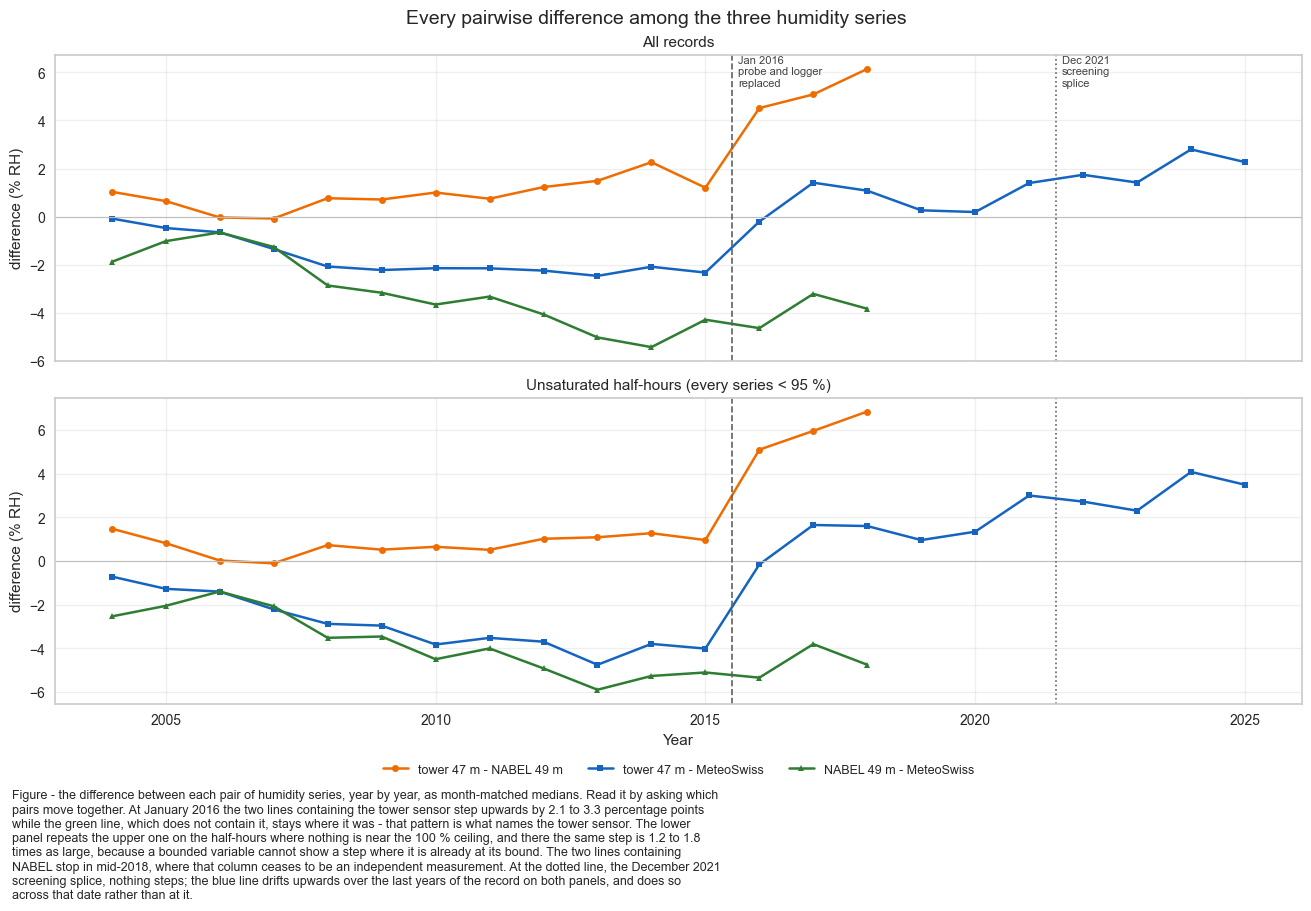

In [37]:
# The three differences drawn together, with the dates this section is about marked on them. The
# tables above are single rows of this figure; the figure shows which changes are steps, which are
# drifts and which pairs move together, none of which two window means can convey.
fig, axs = plt.subplots(nrows=2, figsize=(13, 9), dpi=100, layout="constrained", sharex=True)
for _ax, _lvl, _title in [(axs[0], LEVEL, 'All records'),
                          (axs[1], LEVEL_U, f'Unsaturated half-hours (every series < {SATURATED:.0f} %)')]:
    for _l, _colour, _marker in zip(PAIR_LABELS, ['#EF6C00', '#1565C0', '#2E7D32'], 'os^'):
        _ax.plot(_lvl.index, _lvl[_l], color=_colour, lw=1.8, marker=_marker, ms=5, label=_l)
    _ax.axhline(0, color='#BDBDBD', lw=0.8)
    _ax.axvline(BREAK_YEAR - 0.5, color='#616161', lw=1.2, ls='--')
    _ax.axvline(SCREENING_YEAR - 0.5, color='#616161', lw=1.2, ls=':')
    _ax.set_ylabel('difference (% RH)')
    _ax.set_title(_title, fontsize=11)
    _ax.grid(alpha=0.3)
axs[0].text(BREAK_YEAR - 0.4, axs[0].get_ylim()[1], f'Jan {BREAK_YEAR}\nprobe and logger\nreplaced',
            fontsize=8, color='#424242', va='top')
axs[0].text(SCREENING_YEAR - 0.4, axs[0].get_ylim()[1], f'Dec {SCREENING_YEAR - 1}\nscreening\nsplice',
            fontsize=8, color='#424242', va='top')
axs[1].set_xlabel('Year')
axs[1].legend(fontsize=9, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.16), frameon=False)
fig.suptitle('Every pairwise difference among the three humidity series', fontsize=14)
_ratio = (CHANGE_U.loc[BREAK_YEAR, TOWER_PAIRS] / CHANGE.loc[BREAK_YEAR, TOWER_PAIRS])
figcap(fig, f"the difference between each pair of humidity series, year by year, as month-matched "
            f"medians. Read it by asking which pairs move together. At January {BREAK_YEAR} the "
            f"two lines containing the tower sensor step upwards by "
            f"{CHANGE.loc[BREAK_YEAR, TOWER_PAIRS].min():.1f} to "
            f"{CHANGE.loc[BREAK_YEAR, TOWER_PAIRS].max():.1f} percentage points while the green "
            f"line, which does not contain it, stays where it was - that pattern is what names "
            f"the tower sensor. The lower panel repeats the upper one on the half-hours where "
            f"nothing is near the 100 % ceiling, and there the same step is {_ratio.min():.1f} to "
            f"{_ratio.max():.1f} times as large, because a bounded variable cannot show a step "
            f"where it is already at its bound. The two lines containing NABEL stop in mid-2018, "
            f"where that column ceases to be an independent measurement. At the dotted line, the "
            f"December {SCREENING_YEAR - 1} screening splice, nothing steps; the blue line drifts "
            f"upwards over the last years of the record on both panels, and does so across that "
            f"date rather than at it.")


### 🔟 A level-dependent transfer was tried, and it does not hold

The step is not one number, so the obvious homogenisation is a transfer that varies with the
humidity: measure, per humidity bin, how much the two eras differ, and add that to the earlier era.
This section builds exactly that transfer and then tests whether it is a property of the probes at
all. It is not, and the three cells below are why no `_HOMOGENIZED` column is exported.

Every comparison uses **MeteoSwiss Lägern** and **measured records only** — nothing has been
reconstructed at this point in the notebook, so a non-missing tower value here is a measurement.
The bins are on the **reference** humidity: binning on the tower's own reading would pull each bin
mean toward the tower's own bias and manufacture a slope that is regression to the mean rather
than a sensor step.


In [38]:
HOM_EDGES = np.array([20, 30, 40, 50, 55, 60, 65, 70, 75, 80, 85, 88, 91, 94, 96, 98, 100.0001])
HOM_MID = [(HOM_EDGES[i] + HOM_EDGES[i + 1]) / 2 for i in range(len(HOM_EDGES) - 1)]

_m = pd.concat([rh_2004_2025[TARGET].rename('tower'), lae.rename('ref')], axis=1).dropna()
PRE_YEARS = list(range(2005, BREAK.year))
POST_YEARS = list(range(BREAK.year + 1, int(_m.index.year.max()) + 1))
print(f"measured overlapping records: {len(_m):,}   "
      f"pre {PRE_YEARS[0]}-{PRE_YEARS[-1]}, post {POST_YEARS[0]}-{POST_YEARS[-1]}")


def transfer_curve(frame, pre_years, post_years, min_n=1500):
    """The correction a level-dependent homogenisation would apply, per humidity bin.

    Returns each era's mean tower-minus-reference difference and their difference, which is what
    would have to be ADDED to the earlier era to put it on the later era's level. Bins holding
    fewer than `min_n` records in either era are dropped rather than reported as noise.
    """
    def _binned(sel):
        _b = pd.cut(sel['ref'], bins=HOM_EDGES, labels=HOM_MID, include_lowest=True, right=False)
        _g = (sel['tower'] - sel['ref']).groupby(_b, observed=False)
        return _g.mean(), _g.count()

    _mp, _npre = _binned(frame[frame.index.year.isin(pre_years)])
    _mq, _npost = _binned(frame[frame.index.year.isin(post_years)])
    _t = pd.DataFrame({'pre_diff': _mp, 'post_diff': _mq, 'delta': _mq - _mp,
                       'n_pre': _npre, 'n_post': _npost})
    return _t[(_t.n_pre >= min_n) & (_t.n_post >= min_n)]


CURVE = transfer_curve(_m, PRE_YEARS, POST_YEARS)
# The tower's own reading in each bin, which is the axis the transfer would have to be applied on.
CURVE['tower_reading'] = CURVE.index.to_series().astype(float) + CURVE['pre_diff']

tabcap("the level-dependent correction a homogenisation would apply, per reference-humidity bin: "
       "each era's mean difference from MeteoSwiss, the correction between them, and the tower "
       "reading that correction would attach to. The correction is not monotonic - it is near "
       "zero at both ends of the range and largest in the middle")
display(CURVE.round(2))

print(f"correction spans {CURVE['delta'].min():+.2f} .. {CURVE['delta'].max():+.2f} pp of RH")
_slope = np.diff(CURVE['delta'].values) / np.diff(CURVE['tower_reading'].values)
print(f"steepest slope d(correction)/d(RH) = {_slope.min():+.3f}; the transfer stays invertible "
      f"while this is > -1: {'yes' if _slope.min() > -1 else 'NO'}")


measured overlapping records: 368,813   pre 2005-2015, post 2017-2025
Table - the level-dependent correction a homogenisation would apply, per reference-humidity bin:
each era's mean difference from MeteoSwiss, the correction between them, and the tower reading that
correction would attach to. The correction is not monotonic - it is near zero at both ends of the
range and largest in the middle



,pre_diff,post_diff,delta,n_pre,n_post,tower_reading
ref,,,,,,
35.00000,0.70,3.24,2.54,4271,4789,35.70
45.00000,0.29,3.44,3.15,9935,10554,45.29
52.50000,-0.27,3.79,4.06,7361,7140,52.23
57.50000,-0.97,3.60,4.57,9013,8704,56.53
62.50000,-1.79,3.59,5.38,10852,9908,60.71
67.50000,-2.14,3.87,6.01,12582,10502,65.36
72.50000,-2.47,3.57,6.04,13696,10565,70.03
77.50000,-2.85,3.19,6.04,14419,10734,74.65
82.50000,-2.92,2.87,5.79,15082,11058,79.58


correction spans +1.18 .. +6.04 pp of RH
steepest slope d(correction)/d(RH) = -0.611; the transfer stays invertible while this is > -1: yes


In [39]:
# If the correction is a property of the two probes, each era's own halves must give the same
# curve. Splitting both eras in two and rebuilding the transfer from the halves is the test.
_mid_pre, _mid_post = 2011, 2021
_first = transfer_curve(_m, list(range(2005, _mid_pre)),
                        list(range(BREAK.year + 1, _mid_post)), min_n=800)
_second = transfer_curve(_m, list(range(_mid_pre, BREAK.year)),
                         list(range(_mid_post, int(_m.index.year.max()) + 1)), min_n=800)
STAB = pd.DataFrame({f'from the early halves': _first['delta'],
                     f'from the late halves': _second['delta']}).dropna()
STAB['difference'] = STAB.iloc[:, 0] - STAB.iloc[:, 1]

tabcap("the same correction curve estimated twice, once from the first half of each era and once "
       "from the second half. A correction that belongs to the probes would come out the same "
       "both times")
display(STAB.round(2))
print(f"largest disagreement between the two estimates: {STAB['difference'].abs().max():.2f} pp")

# And the same test across the seasons.
_summer = transfer_curve(_m[_m.index.month.isin([5, 6, 7, 8, 9])], PRE_YEARS, POST_YEARS, min_n=600)
_winter = transfer_curve(_m[_m.index.month.isin([11, 12, 1, 2, 3])], PRE_YEARS, POST_YEARS,
                         min_n=600)
SEAS = pd.DataFrame({'summer': _summer['delta'], 'winter': _winter['delta']}).dropna()
print(f"largest summer-minus-winter disagreement:       "
      f"{(SEAS['summer'] - SEAS['winter']).abs().max():.2f} pp")


Table - the same correction curve estimated twice, once from the first half of each era and once
from the second half. A correction that belongs to the probes would come out the same both times



,from the early halves,from the late halves,difference
ref,,,
35.00000,0.49,4.19,-3.70
45.00000,0.52,5.78,-5.26
52.50000,1.81,6.35,-4.55
57.50000,2.38,6.74,-4.36
62.50000,3.16,7.52,-4.36
67.50000,3.81,8.05,-4.25
72.50000,4.07,7.91,-3.85
77.50000,4.25,7.91,-3.66
82.50000,4.39,7.44,-3.05


largest disagreement between the two estimates: 5.26 pp
largest summer-minus-winter disagreement:       5.72 pp


In [40]:
# Why the estimates disagree: both eras are moving. The mid-humidity band is where the step is
# largest and where the 100 % ceiling does not compress it.
_band = _m[(_m['ref'] >= 60) & (_m['ref'] < 80)]
_res = (_band['tower'] - _band['ref'])
DRIFT = _res.groupby(_res.index.year).agg(['mean', 'count'])
DRIFT = DRIFT[DRIFT['count'] > 1500]

tabcap("the tower-minus-MeteoSwiss difference by year over the mid-humidity band, which is where "
       "the step is largest. The two eras are not two levels; each of them travels")
display(DRIFT.round(2))

_pre = DRIFT.loc[DRIFT.index.isin(PRE_YEARS), 'mean']
_post = DRIFT.loc[DRIFT.index.isin(POST_YEARS), 'mean']
STEP_PP = float(_post.mean() - _pre.mean())
_tr_pre = float(np.polyfit(_pre.index.values.astype(float), _pre.values, 1)[0])
_tr_post = float(np.polyfit(_post.index.values.astype(float), _post.values, 1)[0])
_span_pre, _span_post = _tr_pre * (len(_pre) - 1), _tr_post * (len(_post) - 1)
DRIFT_TOTAL = abs(_span_pre) + abs(_span_post)
_ordinary = float(_pre.diff().abs().median())
_jump = float(DRIFT.loc[BREAK.year + 1, 'mean'] - DRIFT.loc[BREAK.year - 1, 'mean'])

print(f"step between era means:        {STEP_PP:+.2f} pp")
print(f"jump {BREAK.year - 1} -> {BREAK.year + 1}:              {_jump:+.2f} pp   "
      f"(median ordinary year-to-year change within the earlier era: {_ordinary:.2f} pp)")
print(f"drift within the earlier era:  {_tr_pre:+.3f} pp/yr = {_span_pre:+.2f} pp end to end")
print(f"drift within the later era:    {_tr_post:+.3f} pp/yr = {_span_post:+.2f} pp end to end")
print(f"total within-era drift:        {DRIFT_TOTAL:.2f} pp, against a step of {abs(STEP_PP):.2f} pp")

# The step is real. That is asserted first, because everything else here is about what cannot be
# done about it, and a reader must not take this section for a retraction of step 4.
assert _jump > 5 * _ordinary, (
    "the 2016 jump is no longer large against an ordinary year - has a reference changed?")

# But it cannot be removed by a fixed transfer, and these two are the reasons.
assert DRIFT_TOTAL > abs(STEP_PP), (
    "the within-era drift no longer exceeds the step; a fixed transfer may now be defensible "
    "and this section should be revisited")
assert STAB['difference'].abs().max() > 0.5 * abs(STEP_PP), (
    "the two half-era estimates of the transfer now agree; revisit the rejection")
print("\nAsserted: the step is real, and the drift within the eras is larger than it.")


Table - the tower-minus-MeteoSwiss difference by year over the mid-humidity band, which is where the
step is largest. The two eras are not two levels; each of them travels



,mean,count
TIMESTAMP_MIDDLE,,
2005,-0.75,4884
2006,-0.60,4936
2007,-1.18,4960
2008,-2.33,5260
2009,-2.15,5182
2010,-3.45,4199
2011,-2.82,4489
2012,-2.42,4273
2013,-4.15,3841


step between era means:        +5.97 pp
jump 2015 -> 2017:              +5.17 pp   (median ordinary year-to-year change within the earlier era: 0.60 pp)
drift within the earlier era:  -0.309 pp/yr = -3.09 pp end to end
drift within the later era:    +0.496 pp/yr = +3.96 pp end to end
total within-era drift:        7.06 pp, against a step of 5.97 pp

Asserted: the step is real, and the drift within the eras is larger than it.


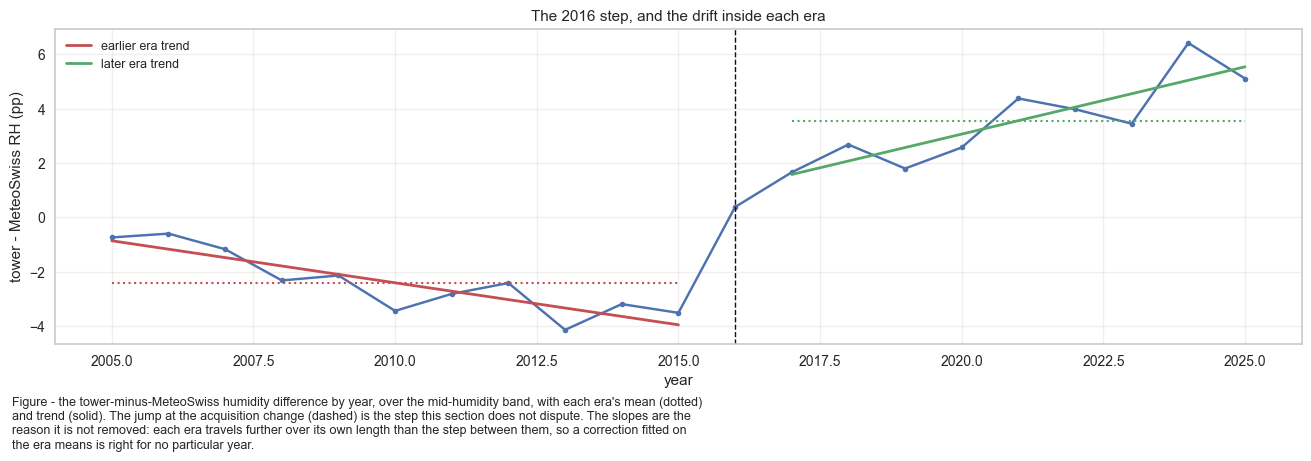

In [41]:
fig, ax = plt.subplots(figsize=(13, 4.5), dpi=100, layout='constrained')
ax.plot(DRIFT.index, DRIFT['mean'], marker='o', ms=4, color='#4C72B0')
for _s, _c, _lab in [(_pre, '#C44E52', 'earlier era'), (_post, '#55A868', 'later era')]:
    _x = _s.index.values.astype(float)
    _fit = np.poly1d(np.polyfit(_x, _s.values, 1))
    ax.plot(_x, _fit(_x), lw=2, color=_c, label=f'{_lab} trend')
    ax.hlines(_s.mean(), _x.min(), _x.max(), color=_c, ls=':', lw=1.5)
ax.axvline(BREAK.year, color='k', ls='--', lw=1)
ax.set_xlabel('year')
ax.set_ylabel('tower - MeteoSwiss RH (pp)')
ax.set_title('The 2016 step, and the drift inside each era', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=.3)
figcap(fig, "the tower-minus-MeteoSwiss humidity difference by year, over the mid-humidity band, "
            "with each era's mean (dotted) and trend (solid). The jump at the acquisition change "
            "(dashed) is the step this section does not dispute. The slopes are the reason it is "
            "not removed: each era travels further over its own length than the step between "
            "them, so a correction fitted on the era means is right for no particular year.")


#### What step 🔟 settles

A level-dependent transfer is buildable, and it is not usable.

The correction it would apply runs from about **1 to 6 percentage points**, near zero at both ends
of the humidity range and largest in the middle. It stays invertible, so as a function it is
well-formed. What it is not is **stable**: estimated from the first half of each era it differs
from the estimate off the second halves by up to the size of the correction itself, and summer and
winter disagree by about as much again.

The reason is in the drift figure. **Each era travels further over its own length than the step
between them** — the earlier era slides one way, the later era the other, and together they cover
more ground than the 2016 jump. A single transfer fitted on the two era means is therefore correct
for no particular year: it would over-correct one end of each era and under-correct the other,
while presenting the result as homogeneous.

Nor could the drift be taken out as well. It is not attributed to either station, and after
mid-2018 there is no third humidity series at this site to attribute it with — NABEL stops and
then repeats the tower. Fitting the tower onto MeteoSwiss over twenty years would replace the
measurement with the reference, which is the rule `01` and `03` follow for an unattributed drift.

So the export keeps one value column and names the probe generation beside it. What a user needs
to know is that the record is inhomogeneous, where the boundary is, and that the eras drift
internally as well — all three of which the flag and this section state, and none of which a
`_HOMOGENIZED` column would.


#### What this section settles

`RH_T1_47_1` is **two instruments in one column**: a Rotronic MP101A from September 2004 to
December 2015, and a Campbell CS215 from 21 January 2016 to the end of the record. The column
steps upwards by **2.1 to 3.3 percentage points of RH** at that boundary, and by **3.9 to 4.1**
away from saturation. The step is on the tower probe, not on either reference; it is present at
every hour of the day; and the probe that was replaced had independently drifted past 100 % in
3.6 % of its last full year.

Three things follow, and the rest of the notebook does them.

**The exported frame carries a `FLAG_RH_T1_47_1_SOURCE` column** naming the probe generation
behind every record, on the pattern of `02`, `08` and `09`. A field name at this site is a
statement about the variable, not about the instrument, and this column must not imply a
continuity the hardware does not have.

**The reconstruction offsets are fitted separately within each era.** Fitting one relationship
across the break would put reconstructed records on neither era's level — the failure `02`
documents for gap-filling models trained across the same date. It matters for about a thousand
records, almost all of them the changeover outage of January 2016, and it moves them by up to
1.8 % RH.

**No `_HOMOGENIZED` column is exported, and that absence is a claim.** The step is not one number:
it is 3 to 6 percentage points over the drier half of the range and at most 1.1 above 95 % RH, so
no constant reaches both ends, and a correction that ignored the bound would push saturated
records past 100 %. Step 🔟 above builds the level-dependent transfer that would answer that, and
measures it: the correction is not stable across either half of its own eras or across the
seasons, because **both eras drift by more than the step between them**. A transfer fitted on the
era means is right for no particular year. The drift cannot be removed either, being unattributed
and — after NABEL stops in 2018 — unattributable. So the honest product is the measurement with
the era named beside it.

::: {.callout-warning title="Known limitation of this product"}
**Any statistic that crosses 21 January 2016 contains this step.** Period means, trends, year
rankings and anomalies over the full record are affected; comparisons within one era are not.
Filter on `FLAG_RH_T1_47_1_SOURCE` to stay inside a single probe generation.

The step is largest in the drier half of the range, so quantities computed from `RH` at low
humidity — vapour pressure deficit above all — inherit more of it than the humidity statistics
themselves. Notebook `07` computes VPD from this series and from the **homogenised** `TA`, so its
temperature term is put on one level and its humidity term cannot be: the residual step in the
exported VPD is about 17 % of the mean, and `07` measures it. Using the uncorrected `TA` there
would report a step about three times smaller, because the two input errors have opposite signs on
VPD and the temperature error masks part of this one. That masking is an accident of the two
signs, not a property to rely on.

**The eras drift internally as well**, by up to about 0.5 percentage points a year against
MeteoSwiss. A trend computed entirely inside one era still contains sensor movement.
:::


### Sensor era of every record

The flag the export carries, built from the two dates the section above took out of the data. It
also supplies the two-valued era label the reconstruction fits are split on.


In [42]:
# The sensor era of every record, derived from the two dates the section above took from the data.
# The codes follow notebook 02, which labels the same two probe generations for TA - one probe
# delivers both variables, so the two products must not disagree about when it changed.
RECORD_START = rh_2004_2025[TARGET].first_valid_index()

SOURCE_LEGEND = {
    0: '0 = Campbell CS215 on SDI-12',
    1: '1 = Rotronic MP101A, single-ended analog',
    2: '2 = acquisition changeover, sensor era undetermined',
    3: '3 = before the tower record begins',
}

source = pd.Series(0, index=rh_2004_2025.index, dtype=int, name=f'FLAG_{TARGET}_SOURCE')
source[(rh_2004_2025.index >= RECORD_START) & (rh_2004_2025.index <= LAST_ANALOG)] = 1
source[(rh_2004_2025.index > LAST_ANALOG) & (rh_2004_2025.index < BREAK)] = 2
source[rh_2004_2025.index < RECORD_START] = 3

# The two-valued era label the offset fits use. Both the pre-record block of 2004 and the
# changeover outage are fitted on the analog era: the first sits inside the analog era's own
# months, and the second is bracketed by analog measurements on its left and by nothing on its
# right, so the analog relationship is the only one either of them has any claim on.
ERA_FIT = pd.Series(np.where(rh_2004_2025.index >= BREAK, 'sdi12', 'analog'),
                    index=rh_2004_2025.index)

tabcap("the sensor generation behind every record, and the period each covers. Codes 2 and 3 mark "
       "records that no probe at this height stands behind: the first is the changeover outage, "
       "the second the months before the tower record begins")
_src = pd.DataFrame({
    'sensor era': [SOURCE_LEGEND[_c].split(' = ')[1] for _c in sorted(SOURCE_LEGEND)],
    'from': [source[source == _c].index.min() for _c in sorted(SOURCE_LEGEND)],
    'to': [source[source == _c].index.max() for _c in sorted(SOURCE_LEGEND)],
    'records': [int((source == _c).sum()) for _c in sorted(SOURCE_LEGEND)],
    'offset fitted as': [ERA_FIT[source == _c].unique()[0] for _c in sorted(SOURCE_LEGEND)],
}, index=pd.Index(sorted(SOURCE_LEGEND), name='code'))
display(_src)

assert int((source == 2).sum()) > 0 and int((source == 3).sum()) > 0, (
    "the changeover interval or the pre-record period has become empty, so the two codes that "
    "mark records no probe stands behind no longer describe anything")
assert source.isin(SOURCE_LEGEND).all(), "a record carries a source code with no legend entry"
assert (ERA_FIT[source == 1] == 'analog').all() and (ERA_FIT[source == 0] == 'sdi12').all(), (
    "a measured record would now be reconstructed against the wrong sensor era's offset")


Table - the sensor generation behind every record, and the period each covers. Codes 2 and 3 mark
records that no probe at this height stands behind: the first is the changeover outage, the second
the months before the tower record begins



,sensor era,from,to,records,offset fitted as
code,,,,,
0,Campbell CS215 on SDI-12,2016-01-21 14:15:00,2025-12-31 23:45:00,174356,sdi12
1,"Rotronic MP101A, single-ended analog",2004-09-20 10:45:00,2015-12-31 23:45:00,197739,analog
2,"acquisition changeover, sensor era undetermined",2016-01-01 00:15:00,2016-01-21 13:45:00,988,analog
3,before the tower record begins,2004-01-01 00:15:00,2004-09-20 10:15:00,12645,analog


#### Negative control

The era split introduces one new way for the fit to fail silently, and it is checked before it is
used.


In [43]:
# The guard guards. An era with no overlap must raise rather than return a table of NaNs: that is
# the failure the era split introduces, and it would otherwise surface either as a confusing
# error inside reconstruct_from_reference or, worse, as a silent fallback to the other era.
_empty_era = pd.Series('analog', index=rh_2004_2025.index)
_empty_era[NABEL_REF.isna()] = 'era-with-no-overlap'
try:
    monthly_offset_table(rh_2004_2025[TARGET], NABEL_REF, era=_empty_era)
except ValueError as _exc:
    print(f"OK, monthly_offset_table raised on an era with no overlap: {_exc}")
else:
    raise AssertionError("(!) monthly_offset_table accepted an era it cannot fit an offset for.")


OK, monthly_offset_table raised on an era with no overlap: sensor era 'era-with-no-overlap' has no overlap between the two series, so no offset can be fitted for it. Reconstructing its records from another era's offset is exactly what this split exists to prevent.


***

## 🟩 Reconstruction from the NABEL sensor


### Why, and what this is not

`RH_T1_47_1` does not begin until **20 September 2004**, leaving an 8.7-month block at the start of
the record with no measurement at all, plus scattered gaps and the 2012 periods removed above. The
NABEL sensor at 49 m measured throughout **2004-2018** and is co-located on the same tower.

Those gaps are filled here from NABEL. This is a **transfer between two measurements of the same
quantity**, not the model-based gap-filling of notebooks `01`-`03`: no meteorological drivers, no
feature engineering, no XGBoost. A long contiguous block like the 2004 one is exactly the case a
driver-based model handles worst and a second co-located sensor handles well.

Records with no NABEL value — chiefly the post-2018 gaps — are reconstructed in a second pass
from MeteoSwiss Lägern (section below), so nothing is left as `NaN`.

### The two sensors do not differ by a constant

A straight copy of NABEL would be wrong in a way that is easy to miss. Over the 2004-2018 overlap
the 47 m sensor reads systematically **moister** than NABEL, and by an amount that varies three
ways.

**Seasonally** — mean offset `47 m - NABEL`, pooled over the whole overlap:

| month | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| offset (% RH) | 3.21 | 3.86 | 2.96 | 2.14 | 1.54 | 0.88 | 0.50 | 0.37 | 0.54 | 1.43 | 2.31 | 2.81 |

The winter divergence is a known, unresolved property of this 47 m / 49 m pair. Critically, the
2004 block spans January to September, so it covers the worst months.

**And over time** — annual mean offset:

| year | 2004 | 2006 | 2008 | 2010 | 2012 | 2014 | 2016 | 2017 | 2018 |
|---|---|---|---|---|---|---|---|---|---|
| offset (% RH) | 1.52 | 0.08 | 0.85 | 1.41 | 2.25 | 3.19 | 4.31 | 5.06 | 3.51 |

The two sensors drift apart steadily. A single offset pooled over the whole overlap is therefore
dominated by the late, high-offset years and is **too large for 2004**: it would apply `+3.42 % RH`
to January 2004 where the local evidence says `+1.35 % RH`.

**And at the sensor change.** The 2016 column of that table is not drift: it is the probe
replacement measured above. Fitting one relationship across it would put the reconstructed records
of the changeover outage on neither era's level.

`monthly_offset_table` (defined above) therefore fits the offset per month on the overlap within
`±2` calendar years of the record being reconstructed **and within its own sensor era**, which
tracks the seasonal shape, the drift and the break.

### Validation

Leave-one-year-out over the 1 January - 20 September window, i.e. exactly the calendar span that
has to be reconstructed in 2004. Each of the 14 usable overlap years is held out in turn, the
transfer is fitted on the others, and the reconstruction is scored against the measurement:

| method | pooled bias | pooled RMSE | median RMSE |
|---|---|---|---|
| straight NABEL copy | **-1.95 % RH** | 4.15 | 3.30 |
| offset, pooled over all overlap | -0.13 % RH | 3.45 | 2.72 |
| per-month linear regression | -0.13 % RH | 3.45 | 2.73 |
| **per-month offset, fitted ±2 years** | **-0.20 % RH** | **3.08** | **2.60** |

- A straight copy carries a ~2 % RH dry bias, concentrated in the winter months the 2004 block
  covers (January RMSE 5.26, February 6.22).
- A fitted per-month regression is indistinguishable from a per-month offset, so the extra
  slope parameter buys nothing and the simpler additive correction is used.
- Fitting locally rather than pooling is worth another ~11 % of RMSE, with the largest gains in
  the years furthest from the record mean (2017: 4.62 -> 3.65, 2018: 4.74 -> 3.37).

Residual uncertainty of a reconstructed record is therefore about **3 % RH**, against a
sensor-to-sensor agreement of about 2 % RH in summer. This is real and it is not negligible — a
reconstructed value is a good estimate, not a measurement, which is why it carries its own flag.

The scores above were established before the era split and are unchanged by it: all 14 held-out
years lie inside the analog era, where the split leaves every offset bit-identical.


In [44]:
OFFSETS = monthly_offset_table(rh_2004_2025[TARGET], NABEL_REF, era=ERA_FIT)

_overlap = pd.concat([rh_2004_2025[TARGET], NABEL_REF], axis=1).dropna()
print(f"Offsets fitted on {len(_overlap):,} overlapping records "
      f"(+/-{OFFSET_WINDOW_YEARS} years, min {OFFSET_MIN_SAMPLES} samples per month), "
      f"separately per sensor era:")
for _e in sorted(ERA_FIT.unique()):
    print(f"  {_e}: {int(ERA_FIT.reindex(_overlap.index).eq(_e).sum()):,} records")

# The 2004 block is by far the largest reconstruction, so show exactly what it will receive.
tabcap("the offsets the 2004 block receives, month by month. That block precedes the tower record "
       "and is fitted on the analog era, which is the era its own months belong to")
display(pd.Series({_m: round(OFFSETS[('analog', 2004, _m)], 2) for _m in range(1, 10)},
                  name='offset (% RH)').rename_axis('month'))

# The full table, per era, so a drifting or fallback-filled year is visible rather than implicit.
# The two eras differ by several percentage points in the same calendar month, which is the step
# the section above measured, seen here as the thing the reconstruction would otherwise inherit.
tabcap("the fitted offset for every year and month, one block per sensor era. Only the rows a "
       "sensor era actually covers are ever used; they are shown for both eras so the size of "
       "the January 2016 step is visible as the difference between two blocks of the same table")
_offset_matrix = OFFSETS.unstack()
_offset_matrix.index.names = ['era', 'year']
_offset_matrix.columns.name = 'month'
display(_offset_matrix.round(2))

_common = [_y for _y in range(2013, 2019)]
_gap = (_offset_matrix.loc['sdi12'].reindex(_common).mean().mean()
        - _offset_matrix.loc['analog'].reindex(_common).mean().mean())
print(f"\nmean offset against NABEL, {_common[0]}-{_common[-1]}: "
      f"analog era {_offset_matrix.loc['analog'].reindex(_common).mean().mean():+.2f} % RH, "
      f"SDI-12 era {_offset_matrix.loc['sdi12'].reindex(_common).mean().mean():+.2f} % RH "
      f"({_gap:+.2f} % RH apart)")
assert _gap > 1.0, (
    "the two eras' offsets against NABEL are no longer separated, so splitting the fit at the "
    "sensor change no longer does anything and the step measured above has gone away")


Offsets fitted on 239,241 overlapping records (+/-2 years, min 500 samples per month), separately per sensor era:
  analog: 194,986 records
  sdi12: 44,255 records
Table - the offsets the 2004 block receives, month by month. That block precedes the tower record
and is fitted on the analog era, which is the era its own months belong to



month
1    1.35
2    2.13
3    2.03
4    1.24
5    0.40
6   -0.32
7   -0.86
8   -0.38
9   -1.02
Name: offset (% RH), dtype: float64

Table - the fitted offset for every year and month, one block per sensor era. Only the rows a sensor
era actually covers are ever used; they are shown for both eras so the size of the January 2016 step
is visible as the difference between two blocks of the same table



month          1      2     3     4     5     6     7     8     9     10    11    12
era    year                                                                         
analog 2004  1.35   2.13  2.03  1.24  0.40 -0.32 -0.86 -0.38 -1.02 -0.19  0.71  1.65
       2005  1.06   1.57  1.76  0.66  0.21 -0.46 -0.88 -0.55 -0.99 -0.25  0.90  1.58
       2006  1.22   1.69  1.89  0.84  0.29 -0.46 -0.84 -0.65 -0.78 -0.07  1.09  1.68
       2007  1.37   1.85  2.01  0.86  0.23 -0.42 -0.84 -0.68 -0.85 -0.03  1.16  1.65
       2008  1.51   1.60  1.99  0.74  0.32 -0.53 -0.95 -0.72 -0.53  0.38  1.64  2.02
       2009  1.66   1.68  1.92  0.75  0.39 -0.27 -0.62 -0.61 -0.29  0.79  1.98  2.41
       2010  2.16   3.01  1.99  1.29  0.61 -0.07 -0.44 -0.53 -0.04  0.99  2.14  2.98
       2011  2.45   3.36  2.18  1.55  0.94  0.18 -0.37 -0.35  0.19  1.21  2.25  3.04
       2012  2.96   3.78  2.24  1.94  1.53  0.37  0.42  0.20  0.73  1.82  2.60  3.26
       2013  3.15   4.16  2.36  2.05  1.49  0.53  0.50  0.29  0.88  2.02  2.62  3.08
       2014  3.58   4.82  2.50  2.33  1.77  0.58  0.59  0.45  1.09  2.19  2.79  3.13
       2015  3.77   4.05  2.81  2.39  2.03  0.68  0.77  0.65  1.34  2.66  2.89  2.77
       2016  4.07   4.18  2.61  2.24  1.97  0.63  1.33  1.03  1.48  3.13  3.17  2.98
       2017  3.63   3.80  2.43  1.57  1.00  0.58 -0.30  0.31  0.79  2.34  2.84  2.52
       2018  2.31   2.90  2.15  1.41  0.89  0.03 -0.23 -0.19  0.05  1.00  1.91  2.46
       2019  2.31   2.90  2.15  1.41  0.89  0.03 -0.23 -0.19  0.05  1.00  1.91  2.46
       2020  2.31   2.90  2.15  1.41  0.89  0.03 -0.23 -0.19  0.05  1.00  1.91  2.46
       2021  2.31   2.90  2.15  1.41  0.89  0.03 -0.23 -0.19  0.05  1.00  1.91  2.46
       2022  2.31   2.90  2.15  1.41  0.89  0.03 -0.23 -0.19  0.05  1.00  1.91  2.46
       2023  2.31   2.90  2.15  1.41  0.89  0.03 -0.23 -0.19  0.05  1.00  1.91  2.46
       2024  2.31   2.90  2.15  1.41  0.89  0.03 -0.23 -0.19  0.05  1.00  1.91  2.46
       2025  2.31   2.90  2.15  1.41  0.89  0.03 -0.23 -0.19  0.05  1.00  1.91  2.46
sdi12  2004  7.41   7.33  5.93  4.80  3.93  4.00  3.11  2.98  3.59  4.72  5.83  6.31
       2005  7.41   7.33  5.93  4.80  3.93  4.00  3.11  2.98  3.59  4.72  5.83  6.31
       2006  7.41   7.33  5.93  4.80  3.93  4.00  3.11  2.98  3.59  4.72  5.83  6.31
       2007  7.41   7.33  5.93  4.80  3.93  4.00  3.11  2.98  3.59  4.72  5.83  6.31
       2008  7.41   7.33  5.93  4.80  3.93  4.00  3.11  2.98  3.59  4.72  5.83  6.31
       2009  7.41   7.33  5.93  4.80  3.93  4.00  3.11  2.98  3.59  4.72  5.83  6.31
       2010  7.41   7.33  5.93  4.80  3.93  4.00  3.11  2.98  3.59  4.72  5.83  6.31
       2011  7.41   7.33  5.93  4.80  3.93  4.00  3.11  2.98  3.59  4.72  5.83  6.31
       2012  7.41   7.33  5.93  4.80  3.93  4.00  3.11  2.98  3.59  4.72  5.83  6.31
       2013  7.41   7.33  5.93  4.80  3.93  4.00  3.11  2.98  3.59  4.72  5.83  6.31
       2014  4.44   5.97  5.94  4.57  3.36  3.92  2.95  2.62  3.02  4.60  5.67  4.90
       2015  7.78   5.98  5.33  4.59  3.57  3.62  3.14  2.98  3.59  4.72  5.83  6.31
       2016  7.41   7.33  5.93  4.80  3.93  4.00  3.11  2.98  3.59  4.72  5.83  6.31
       2017  7.41   7.33  5.93  4.80  3.93  4.00  3.11  2.98  3.59  4.72  5.83  6.31
       2018  7.41   7.33  5.93  4.80  3.93  4.00  3.11  2.98  3.59  4.72  5.83  6.31
       2019  7.91   8.03  5.92  4.92  4.21  4.05  3.19  3.34  4.17  4.83  5.99  7.73
       2020  6.92  10.07  7.13  5.22  4.66  4.78  3.05  2.98  3.59  4.72  5.83  6.31
       2021  7.41   7.33  5.93  4.80  3.93  4.00  3.11  2.98  3.59  4.72  5.83  6.31
       2022  7.41   7.33  5.93  4.80  3.93  4.00  3.11  2.98  3.59  4.72  5.83  6.31
       2023  7.41   7.33  5.93  4.80  3.93  4.00  3.11  2.98  3.59  4.72  5.83  6.31
       2024  7.41   7.33  5.93  4.80  3.93  4.00  3.11  2.98  3.59  4.72  5.83  6.31
       2025  7.41   7.33  5.93  4.80  3.93  4.00  3.11  2.98  3.59  4.72  5.83  6.31


mean offset against NABEL, 2013-2018: analog era +1.96 % RH, SDI-12 era +4.85 % RH (+2.89 % RH apart)


In [45]:
_before_recon = rh_2004_2025[TARGET].copy()
rh_2004_2025[TARGET], reconstructed = reconstruct_from_reference(
    rh_2004_2025[TARGET], NABEL_REF, OFFSETS, era=ERA_FIT)

print(f"Reconstructed {int(reconstructed.sum()):,} records from {REFERENCE}")
print(f"  previously never measured: {int((reconstructed & never_measured).sum()):,}")
print(f"  previously removed here:   {int((reconstructed & removed_here).sum()):,}")
for _e in sorted(ERA_FIT.unique()):
    print(f"  fitted on the {_e} era:      {int((reconstructed & (ERA_FIT == _e)).sum()):,}")
print(f"Still missing:  {int(rh_2004_2025[TARGET].isna().sum()):,} "
      f"(no NABEL value available)")

# Reconstruction must not touch a record that already had a value.
assert rh_2004_2025.loc[_before_recon.notna(), TARGET].equals(_before_recon.dropna()), \
    "reconstruction overwrote measured values"
print("\nMeasured records untouched by the reconstruction.")

# Reconstructed values must respect the physical bounds.
_rec = rh_2004_2025.loc[reconstructed, TARGET]
print(f"Reconstructed range: {_rec.min():.2f} - {_rec.max():.2f} %")
assert _rec.between(0, 100).all(), "NABEL reconstruction produced out-of-range RH"

# And no record may be reconstructed with the other era's relationship. This is the assertion the
# era split exists for; without it the split could be removed and nothing would fail.
assert (ERA_FIT[reconstructed & (rh_2004_2025.index >= BREAK)] == 'sdi12').all() and \
       (ERA_FIT[reconstructed & (rh_2004_2025.index < BREAK)] == 'analog').all(), (
    "a record was reconstructed with the offset relationship of the other sensor era")
print("Every reconstructed record used the offset fitted for its own sensor era.")


Reconstructed 15,729 records from RH_NABEL_T1_49_1
  previously never measured: 14,514
  previously removed here:   1,215
  fitted on the analog era:      15,726
  fitted on the sdi12 era:      3
Still missing:  920 (no NABEL value available)

Measured records untouched by the reconstruction.
Reconstructed range: 22.65 - 100.00 %
Every reconstructed record used the offset fitted for its own sensor era.


### Does the reconstructed 2004 block look like a plausible year?

The reconstruction cannot be validated against the 47 m sensor in 2004, since there is nothing to
validate against — that is the whole reason it exists. What can be checked is whether the result
is climatologically sensible: its monthly means should sit near the same months in the following
measured years, differing only by ordinary interannual variability, and its diurnal structure
should look like an `RH` year rather than a flat or clipped series.

Table - the reconstructed 2004 block against the same months of the four measured years that follow
it. The reconstruction cannot be validated against the 47 m sensor in 2004 - there is nothing to
validate against, which is why it exists - so what is checked is whether it is climatologically
sensible



,2004 (reconstructed),2005-2008 (measured),difference
month,,,
1,89.5,84.6,4.9
2,74.7,82.5,-7.8
3,74.3,78.8,-4.5
4,66.7,69.7,-3.0
5,67.4,69.8,-2.4
6,70.1,69.6,0.5
7,69.4,68.9,0.5
8,74.3,77.9,-3.6
9,68.5,79.2,-10.7


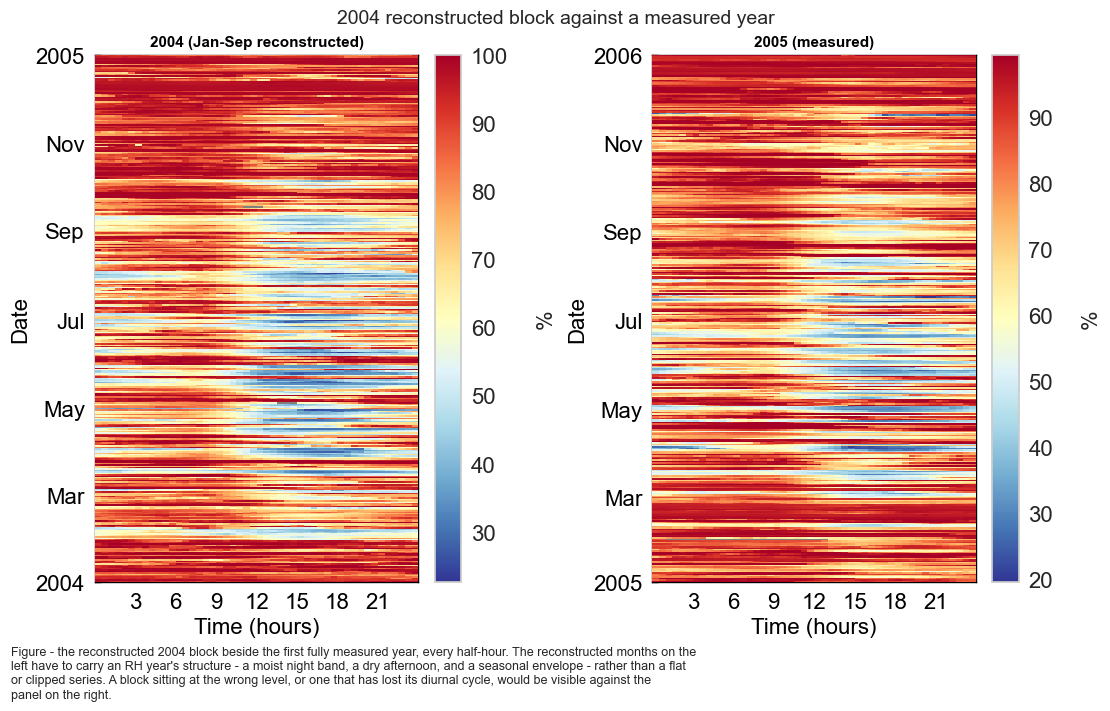

In [46]:
_recon_2004 = rh_2004_2025.loc['2004-01-01':'2004-09-20', TARGET]
_measured_ref = rh_2004_2025.loc['2005':'2008', TARGET]
_measured_ref = _measured_ref[_measured_ref.index.month <= 9]

_cmp = pd.DataFrame({
    '2004 (reconstructed)': _recon_2004.groupby(_recon_2004.index.month).mean().round(1),
    '2005-2008 (measured)': _measured_ref.groupby(_measured_ref.index.month).mean().round(1),
})
_cmp['difference'] = (_cmp.iloc[:, 0] - _cmp.iloc[:, 1]).round(1)
_cmp.index.name = 'month'
tabcap("the reconstructed 2004 block against the same months of the four measured years that follow it. The reconstruction cannot be validated against the 47 m sensor in 2004 - there is nothing to validate against, which is why it exists - so what is checked is whether it is climatologically sensible")
display(_cmp)

fig, axs = plt.subplots(ncols=2, figsize=(11, 7), dpi=100, layout="constrained")
fig.suptitle('2004 reconstructed block against a measured year', fontsize=14)
dv.plotting.HeatmapDateTime(series=rh_2004_2025.loc['2004', TARGET]).plot(
    ax=axs[0], cb_digits_after_comma=0, zlabel='%',
    format_style=dv.plotting.FormatStyle(title='2004 (Jan-Sep reconstructed)', title_fontsize=11))
dv.plotting.HeatmapDateTime(series=rh_2004_2025.loc['2005', TARGET]).plot(
    ax=axs[1], cb_digits_after_comma=0, zlabel='%',
    format_style=dv.plotting.FormatStyle(title='2005 (measured)', title_fontsize=11))
figcap(fig, "the reconstructed 2004 block beside the first fully measured year, every "
            "half-hour. The reconstructed months on the left have to carry an RH year's "
            "structure - a moist night band, a dry afternoon, and a seasonal envelope - rather "
            "than a flat or clipped series. A block sitting at the wrong level, or one that has "
            "lost its diurnal cycle, would be visible against the panel on the right.")


## 🟩 Second reconstruction pass: MeteoSwiss Lägern

NABEL ends in 2018, leaving ~920 gaps the pass above cannot reach — almost all after 2018. The
MeteoSwiss Lägern station (`RH_LAE_MS`, 2.5 km away, 845 m) measures `RH` over the whole 2004-2025
record and covers **100 %** of those remaining gaps. A second pass fills them the same way the
NABEL pass does: an additive per-month offset fitted on the tower-vs-Lägern overlap **within each
sensor era**, then applied to the Lägern value.

Lägern is a weaker reference than NABEL — 2.5 km away and 400 m lower, against NABEL's 49 m on the
same tower. Over the 2004-2025 overlap tower `RH` and Lägern correlate `r = 0.94`, and the monthly
offset varies seasonally and steps at the probe replacement, which is why the same
era-split month-by-month offset is used rather than a straight copy. These fills carry flag `4`,
kept distinct from NABEL's flag `3` so their larger uncertainty stays visible.

An altitude difference of 400 m produces a real, seasonal humidity offset between the two sites.
That is not an instrument error and it is not corrected: it is precisely what the monthly offset
absorbs.

### Fit the offset and reconstruct

The reference was loaded and its timestamp alignment asserted in the sensor-identity section
above, where it is the third of the three series. `reconstruct_from_reference` fills only the
records still missing after the NABEL pass, clips to `[0, 100]`, and cannot touch a record that
already carries a value.


In [47]:
# Measured tower RH only: the NABEL-reconstructed records are excluded so the offset fit below
# never sees a value that is itself a transfer from another instrument.
measured_rh = rh_2004_2025[TARGET].where(~reconstructed)
_still_missing = rh_2004_2025[TARGET].isna()
print(f"Laegern covers {int((lae.notna() & _still_missing).sum()):,} of "
      f"{int(_still_missing.sum()):,} records still missing after the NABEL pass")

OFFSETS_LAE = monthly_offset_table(measured_rh, lae, era=ERA_FIT)

_overlap_n = int(pd.concat([measured_rh, lae], axis=1).dropna().shape[0])
print(f"Laegern offsets fitted on {_overlap_n:,} overlapping measured records "
      f"(+/-{OFFSET_WINDOW_YEARS} years, min {OFFSET_MIN_SAMPLES} samples per month), "
      f"split at the sensor change like the NABEL pass.")
print(f"Fitted monthly offset range: {OFFSETS_LAE.min():+.2f} .. {OFFSETS_LAE.max():+.2f} % RH")

_before_recon_lae = rh_2004_2025[TARGET].copy()
rh_2004_2025[TARGET], reconstructed_lae = reconstruct_from_reference(
    rh_2004_2025[TARGET], lae, OFFSETS_LAE, era=ERA_FIT)

print(f"\nReconstructed {int(reconstructed_lae.sum()):,} records from {REFCOL}")
print(f"  previously never measured: {int((reconstructed_lae & never_measured).sum()):,}")
print(f"  previously removed here:   {int((reconstructed_lae & removed_here).sum()):,}")

# The Laegern pass may only fill records that were still missing: it must not overwrite a measured
# or a NABEL-reconstructed value, and must not overlap the NABEL mask.
assert rh_2004_2025.loc[_before_recon_lae.notna(), TARGET].equals(_before_recon_lae.dropna()), \
    "Laegern reconstruction overwrote an existing value"
assert int((reconstructed_lae & reconstructed).sum()) == 0, "Laegern overlaps the NABEL reconstruction"
print("Existing measured and NABEL-reconstructed records untouched by the Laegern pass.")

# Reconstructed values must respect the physical bounds.
_rec_lae = rh_2004_2025.loc[reconstructed_lae, TARGET]
print(f"Laegern-reconstructed range: {_rec_lae.min():.2f} - {_rec_lae.max():.2f} %")
assert _rec_lae.between(0, 100).all(), "Laegern reconstruction produced out-of-range RH"

# Both passes together must leave no gap.
_residual = int(rh_2004_2025[TARGET].isna().sum())
print(f"\nStill missing after both passes: {_residual}")
assert _residual == 0, "product still has gaps after the Laegern pass"
print("Product is complete: every record carries a value.")


Laegern covers 920 of 920 records still missing after the NABEL pass


Laegern offsets fitted on 368,813 overlapping measured records (+/-2 years, min 500 samples per month), split at the sensor change like the NABEL pass.
Fitted monthly offset range: -4.92 .. +7.38 % RH

Reconstructed 920 records from RH_LAE_MS
  previously never measured: 920
  previously removed here:   0
Existing measured and NABEL-reconstructed records untouched by the Laegern pass.
Laegern-reconstructed range: 39.82 - 100.00 %

Still missing after both passes: 0
Product is complete: every record carries a value.


***

## ➡️ Prepare dataframe for export

The provenance flag is assembled from the masks captured along the way:
`never_measured` (taken before anything was removed), `removed_here` (the 2012 windows),
`reconstructed` (NABEL) and `reconstructed_lae` (Lägern). Order matters — the two reconstruction
masks are applied after `1` and `2`, because a record that was removed here and then reconstructed
carries a value and must read `3` or `4`, not `2`.

Codes `1` and `2` would survive only where neither reference could supply a value. Lägern covers
every gap NABEL missed, so in this record they do not occur at all.

The **sensor-era flag** built in the section above is exported beside them. It describes the
timestamp rather than the value, so it is defined for every record including the reconstructed
ones: a record reconstructed from NABEL in January 2016 still falls in the changeover outage and
still reads `2`.


In [48]:
VALCOL = TARGET
FLAGCOL = f"FLAG_{TARGET}_MISSING"
SRCCOL = f"FLAG_{TARGET}_SOURCE"

flag = pd.Series(0, index=rh_2004_2025.index, dtype=int, name=FLAGCOL)
flag[never_measured] = 1
flag[removed_here] = 2
flag[reconstructed] = 3       # NABEL pass
flag[reconstructed_lae] = 4   # Laegern pass; both reconstruction masks are applied after 1/2, so a
                              # reconstructed record reads 3 or 4, never 1 or 2

export_df = pd.concat([rh_2004_2025[VALCOL], flag, source.rename(SRCCOL)], axis=1)
tabcap("the exported frame: one value column and two flags - where the value came from, and which "
       "probe generation stands behind the timestamp")
export_df


Table - the exported frame: one value column and two flags - where the value came from, and which
probe generation stands behind the timestamp



,RH_T1_47_1,FLAG_RH_T1_47_1_MISSING,FLAG_RH_T1_47_1_SOURCE
TIMESTAMP_MIDDLE,,,
2004-01-01 00:15:00,97.718962,3,3
2004-01-01 00:45:00,96.918962,3,3
2004-01-01 01:15:00,93.552296,3,3
2004-01-01 01:45:00,92.652296,3,3
2004-01-01 02:15:00,93.985629,3,3
...,...,...,...
2025-12-31 21:45:00,42.332976,0,0
2025-12-31 22:15:00,39.230344,0,0
2025-12-31 22:45:00,55.771803,0,0


Sanity check. The exported series is **complete** — both reconstruction
passes together leave no gap — so the checks match the completeness of notebooks `01`-`03`, with
`RH`-specific bounds:

- the index must be continuous 30MIN with no duplicates, every record must carry both flags, and
  no value may be missing
- the provenance flag must agree with the values exactly: a value is present if and only if the
  flag is in `PRESENT_FLAGS` (`0`, `3` or `4`) — which, with no gaps, is every record
- `RH` is bounded `[0, 100]`, and both ends are asserted rather than assumed (the `RH > 100%`
  correction clips the upper end; reconstruction adds an offset and clips both)
- the **sensor-era flag** must partition the record, must never label a measured record as
  belonging to the changeover or to the period before the record begins, and the two probe eras
  must not overlap in time


In [49]:
print(f"Records:         {len(export_df):,}")
print(f"Values present:  {export_df[VALCOL].notna().sum():,}")
print(f"Missing values:  {export_df[VALCOL].isnull().sum():,}")
print(f"Missing flags:   {export_df[FLAGCOL].isnull().sum()} / {export_df[SRCCOL].isnull().sum()}")
print(f"Duplicate index: {export_df.index.duplicated().sum()}")
print(f"Index gaps:      {(export_df.index.to_series().diff().dropna() != pd.Timedelta('30min')).sum()}")
print(f"Min / max:       {export_df[VALCOL].min():.2f} / {export_df[VALCOL].max():.2f} %")

# The flag has to describe the value column exactly, otherwise a downstream consumer would be
# working from a wrong provenance.
_agree = (export_df[VALCOL].notna() == export_df[FLAGCOL].isin(PRESENT_FLAGS)).all()
print(f"\nFlag agrees with values: {bool(_agree)}")
assert _agree, "flag and value column disagree about which records carry a value"

# RH is bounded. The correction clips the upper end, reconstruction clips both; nothing else does.
assert export_df[VALCOL].min() >= 0, "RH below 0%"
assert export_df[VALCOL].max() <= 100, "RH above 100%"
print("Bounds [0, 100] hold.")

# The product is complete: both reconstruction passes together leave no gap.
assert export_df[VALCOL].isna().sum() == 0, "product is not complete"
print("Complete: no missing values.")

# The source flag must partition the record and must not contradict the measurement dates. Every
# measured record has to fall in one of the two probe eras: a measured record labelled 2 or 3
# would mean the changeover dates and the data disagree.
assert export_df[SRCCOL].isin(SOURCE_LEGEND).all(), "a record carries an unknown source code"
_measured = export_df[FLAGCOL] == 0
assert export_df.loc[_measured, SRCCOL].isin([0, 1]).all(), (
    "a measured record is labelled as belonging to the changeover or to the period before the "
    "record begins, so the sensor-era dates no longer describe the data")
assert (export_df.loc[export_df[SRCCOL] == 1].index.max() < BREAK <=
        export_df.loc[export_df[SRCCOL] == 0].index.min()), (
    "the two probe eras now overlap in time, which no single-probe record can do")
print("Source flag partitions the record and agrees with the measurement dates.")

print("\nProvenance:")
tabcap("how many records each provenance code and each sensor era accounts for")
_counts = export_df[FLAGCOL].value_counts().sort_index()
display(pd.DataFrame({'count': _counts}).rename(index=FLAG_LEGEND))
_srccounts = export_df[SRCCOL].value_counts().sort_index()
display(pd.DataFrame({'count': _srccounts}).rename(index=SOURCE_LEGEND))

tabcap("the distribution of the exported columns")
export_df.describe()


Records:         385,728
Values present:  385,728
Missing values:  0
Missing flags:   0 / 0
Duplicate index: 0
Index gaps:      0
Min / max:       16.99 / 100.00 %

Flag agrees with values: True
Bounds [0, 100] hold.
Complete: no missing values.
Source flag partitions the record and agrees with the measurement dates.

Provenance:
Table - how many records each provenance code and each sensor era accounts for



,count
FLAG_RH_T1_47_1_MISSING,
0 = measured at 47 m (corrected),369079
3 = reconstructed from NABEL at 49 m,15729
4 = reconstructed from MeteoSwiss Lägern at 2.5 km,920


,count
FLAG_RH_T1_47_1_SOURCE,
0 = Campbell CS215 on SDI-12,174356
"1 = Rotronic MP101A, single-ended analog",197739
"2 = acquisition changeover, sensor era undetermined",988
3 = before the tower record begins,12645


Table - the distribution of the exported columns



,RH_T1_47_1,FLAG_RH_T1_47_1_MISSING,FLAG_RH_T1_47_1_SOURCE
count,385728.000000,385728.000000,385728.000000
mean,79.348097,0.131873,0.616108
std,18.836006,0.622711,0.662069
min,16.990002,0.000000,0.000000
25%,65.510002,0.000000,0.000000
50%,82.900002,0.000000,1.000000
75%,98.056818,0.000000,1.000000
max,100.000000,4.000000,3.000000


### Per-year coverage

Records per year by provenance. The product is complete, so this shows *how* each year is
filled rather than counting gaps:

- `RH_T1_47_1` was **not measured before 20 September 2004**, so almost all of 2004 is
  reconstructed rather than measured — the first year is short on measurements by design, not by
  data loss.
- The reconstruction source switches at the end of **2018**: NABEL (flag `3`) up to there,
  MeteoSwiss Lägern (flag `4`) for the gaps after it.
- Code `2` (removed here) does not appear: NABEL covers all three 2012 windows, so those 1,215
  records were reconstructed and read `3`. The distinction is preserved inside the notebook in
  `removed_here` and reported by the reconstruction cell above.
- 2016 is the second most heavily reconstructed year, and all of it is the changeover outage.


Table - records per year and provenance code. Every record carries a code and a value, so the rows
sum to the number of half-hours in each year



,records,0 = measured at 47 m (corrected),3 = reconstructed from NABEL at 49 m,4 = reconstructed from MeteoSwiss Lägern at 2.5 km
year,,,,
2004,17568,4922,12640,6
2005,17520,17486,10,24
2006,17520,17493,27,0
2007,17520,17507,13,0
2008,17568,17548,20,0
2009,17520,17034,486,0
2010,17520,17351,169,0
2011,17520,17499,11,10
2012,17568,16308,1260,0


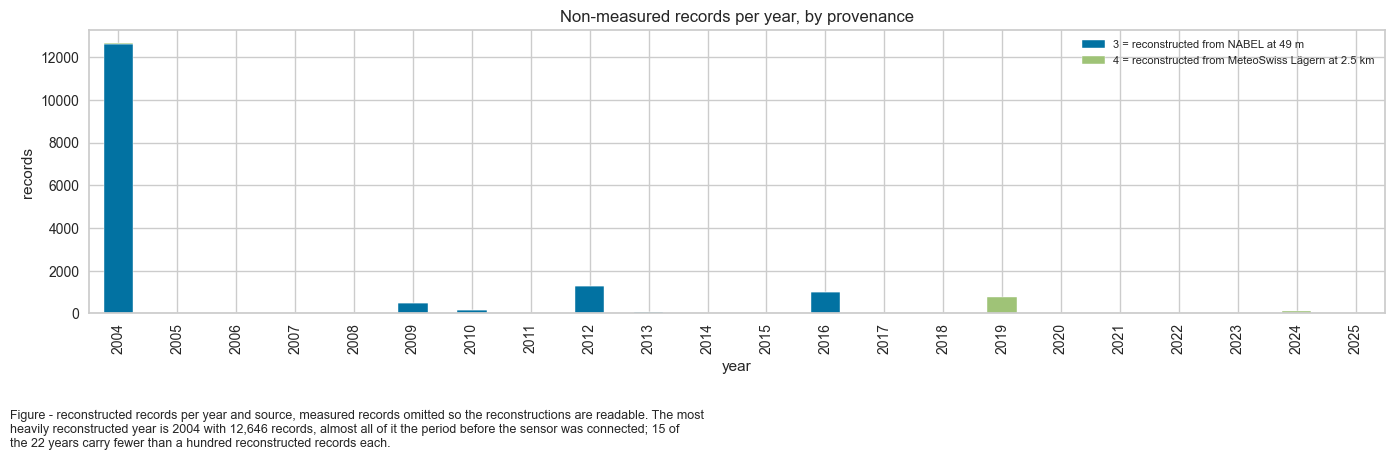

In [50]:
coverage_stats_by_year(export_df[VALCOL], export_df[FLAGCOL])

### Plots

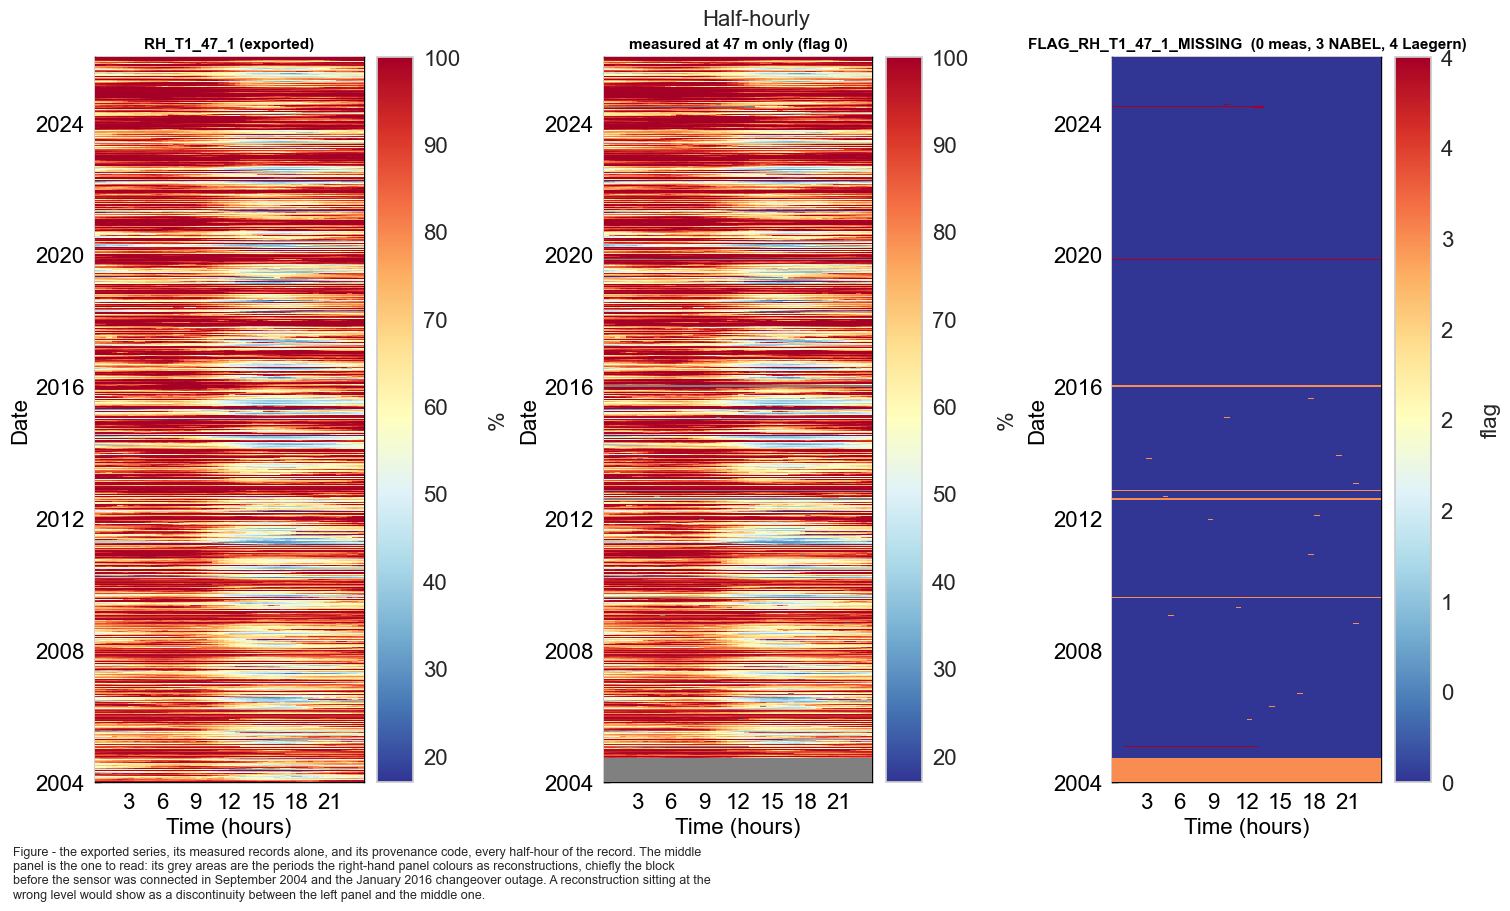

In [51]:
fig, axs = plt.subplots(ncols=3, figsize=(15, 9), dpi=100, layout="constrained")
fig.suptitle('Half-hourly', fontsize=16)
dv.plotting.HeatmapDateTime(series=export_df[VALCOL]).plot(
    ax=axs[0], cb_digits_after_comma=0, zlabel='%',
    format_style=dv.plotting.FormatStyle(title=f'{VALCOL} (exported)', title_fontsize=11))
dv.plotting.HeatmapDateTime(series=export_df[VALCOL].where(export_df[FLAGCOL] == 0)).plot(
    ax=axs[1], cb_digits_after_comma=0, zlabel='%',
    format_style=dv.plotting.FormatStyle(title='measured at 47 m only (flag 0)', title_fontsize=11))
dv.plotting.HeatmapDateTime(series=export_df[FLAGCOL].astype(float)).plot(
    ax=axs[2], cb_digits_after_comma=0, zlabel='flag',
    format_style=dv.plotting.FormatStyle(title=f'{FLAGCOL}  (0 meas, 3 NABEL, 4 Laegern)',
                                         title_fontsize=11))
figcap(fig, "the exported series, its measured records alone, and its provenance code, "
            "every half-hour of the record. The middle panel is the one to read: its grey areas "
            "are the periods the right-hand panel colours as reconstructions, chiefly the block "
            "before the sensor was connected in September 2004 and the January 2016 changeover "
            "outage. A reconstruction sitting at the wrong level would show as a discontinuity "
            "between the left panel and the middle one.")


array([<Axes: xlabel='TIMESTAMP_MIDDLE', ylabel='RH (%)'>,
       <Axes: xlabel='TIMESTAMP_MIDDLE', ylabel='RH (%)'>,
       <Axes: xlabel='TIMESTAMP_MIDDLE', ylabel='RH (%)'>,
       <Axes: xlabel='TIMESTAMP_MIDDLE', ylabel='RH (%)'>,
       <Axes: xlabel='TIMESTAMP_MIDDLE', ylabel='flag'>], dtype=object)

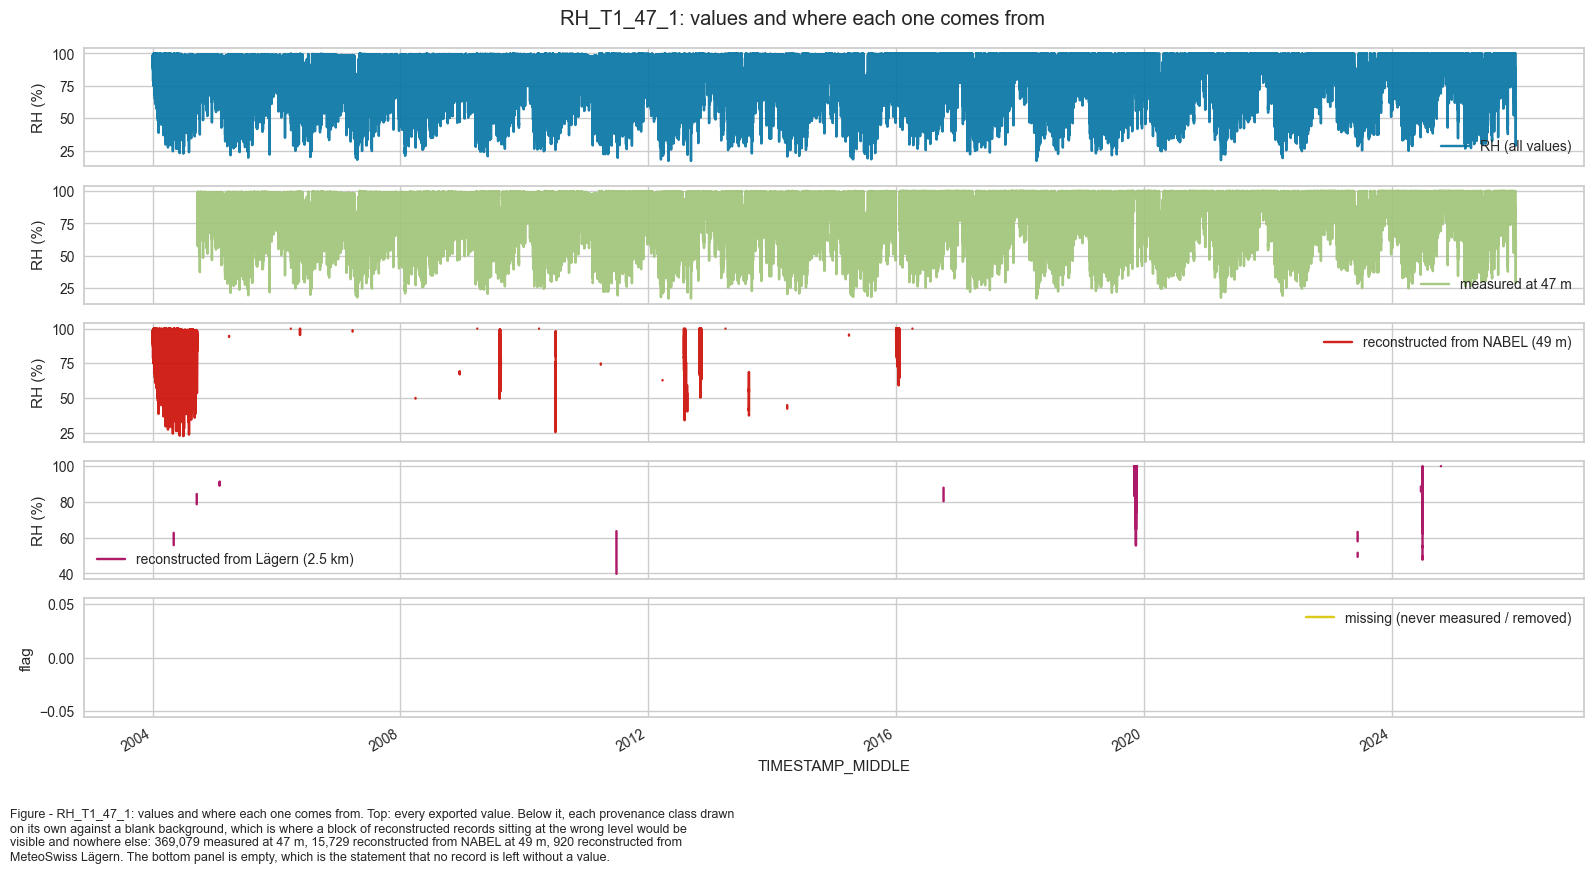

In [52]:
plot_presence_panels(export_df[VALCOL], export_df[FLAGCOL],
                     title=f'{VALCOL}: values and where each one comes from')

***

## 💾 Save to file

In [53]:
filepath = dv.save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
export_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")
print(f"Saved to: {filepath}")

> Saved file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\04_METEO_RH_CORRECTED_2004-2025.parquet (0.036 seconds).

Saved to: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS\04_METEO_RH_CORRECTED_2004-2025.parquet


Read the written file back and check it against the frame in memory, rather than trusting that
the save worked. Reading the parquet is the same operation the downstream notebooks perform.

In [54]:
_check = dv.load_parquet(filepath=str(Path(OUTPATH) / f"{OUTNAME}.parquet"))
print(f"Columns:      {list(_check.columns)}")
print(f"Records:      {len(_check):,}")
print(f"Range:        {_check.index[0]} -> {_check.index[-1]}")
print(f"Index name:   {_check.index.name}")
print(f"Missing:      {_check[VALCOL].isna().sum():,}")
print(f"Min / max:    {_check[VALCOL].min():.2f} / {_check[VALCOL].max():.2f} %")
print(f"Flag counts:  {_check[FLAGCOL].value_counts().sort_index().to_dict()}")

assert _check[VALCOL].equals(export_df[VALCOL]), "values differ from what was written"
assert _check[FLAGCOL].equals(export_df[FLAGCOL]), "flags differ from what was written"
assert (_check[VALCOL].notna() == _check[FLAGCOL].isin(PRESENT_FLAGS)).all(), "flag/value disagreement in written file"
print("\nWritten file matches the exported dataframe.")

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\04_METEO_RH_CORRECTED_2004-2025.parquet (0.009 seconds).

Columns:      ['RH_T1_47_1', 'FLAG_RH_T1_47_1_MISSING', 'FLAG_RH_T1_47_1_SOURCE']
Records:      385,728
Range:        2004-01-01 00:15:00 -> 2025-12-31 23:45:00
Index name:   TIMESTAMP_MIDDLE
Missing:      0
Min / max:    16.99 / 100.00 %
Flag counts:  {0: 369079, 3: 15729, 4: 920}

Written file matches the exported dataframe.


***

## ⚠️ Note for downstream notebooks

This product is **complete**: `RH_T1_47_1` has no gaps.

`FLAG_RH_T1_47_1_MISSING` tells a consumer what each record is:

- `0` — measured at 47 m and corrected. The only genuine measurements of this sensor.
- `3` — reconstructed from the NABEL sensor at 49 m on the same tower. A good estimate carrying
  about **3 % RH** of uncertainty (see the validation table), not a measurement.
- `4` — reconstructed from MeteoSwiss Lägern, 2.5 km away and 400 m lower. Same additive-offset
  method as flag `3`, but a more distant, less similar sensor, so a weaker reconstruction with
  larger uncertainty. Almost all post-2018.
- `1` / `2` — retained in the legend but do not occur: Lägern covers every gap NABEL missed.

Anything estimating measurement uncertainty, or fitting a relationship where `RH` is the
independent variable, should consider excluding flags `3` and `4` — and treating `4` as the weaker
of the two.

`FLAG_RH_T1_47_1_SOURCE` tells it which probe stands behind the timestamp, and is the column to
read before any statistic that crosses **21 January 2016**. The series steps upwards by 2 to 4
percentage points of RH there and is exported uncorrected; the section above carries the evidence
and the reason no homogenised column exists.

::: {.callout-important title="What notebook 07 has to know"}
**Notebook `07` computes VPD from `TA` and `RH`** and reads `FLAG_RH_T1_47_1_MISSING`. Two things
have changed here since it was last run.

The reconstruction offsets are now fitted per sensor era, which moved **609 exported values**, all
of them in 2014-2016 and by at most 1.8 % RH. `07` and then `99` have to be re-run in that order
for the merged product to match this file.

The new `FLAG_RH_T1_47_1_SOURCE` column is not yet propagated. `TA` is homogenised across
21 January 2016 and `RH` is not, so a VPD computed from the two crosses that date carrying a
correction on one input and none on the other. That is a property of the inputs rather than a
defect of `07`, but it belongs on the `VPD` page and is recorded here so it is not lost.
:::

`TA` arrives from notebook `02` complete and `RH` arrives from here complete, so the VPD in `07`
does not inherit gaps from `RH`. (Notebook `13` was the earlier VPD approach and is retired.)


## End of notebook.


In [55]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h:02d}:{_m:02d}:{_s:02d} (hh:mm:ss)")

Started:  2026-07-29 20:56:44
Finished: 2026-07-29 20:57:20
Runtime:  00:00:35 (hh:mm:ss)
